# Ball in a Double Hoop — bench data analysis

Every figure in the report, from the raw `.npz` the bench wrote.

Run Jupyter from this folder: the paths below are relative to it.

## 1. Setup

In [1]:
# All imports for the notebook.
import json
import re
import h5py
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path
from scipy import stats
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.io import loadmat
from scipy.optimize import curve_fit
from scipy.signal import find_peaks, savgol_filter

# Dependances utilisees par plusieurs sections.


In [2]:
NPZ_FOLDER = Path("npz")  # ou "data/raw" selon ta structure

# The .npz names carry the campaign they belong to as a prefix, but not
# consistently: E1 was recorded in two runs named id2/id3, and T1 and T3 kept
# a version suffix. This maps the prefixes onto the campaign names used in
# the report, longest prefix first so id3 is not caught by id.
CAMPAIGN_BY_PREFIX = [
    ("id2",        "E1"),
    ("id3",        "E1"),
    ("E2",         "E2"),
    ("E3",         "E3"),
    ("T1v3",       "T1"),
    ("T2",         "T2"),
    ("T3v3",       "T3"),
    ("inner_loop", "Inner loop tuning"),
    ("tune",       "Inner loop tuning"),
]


def extract_experiment_type(filename):
    """Campaign a capture belongs to, from its file name."""
    name = filename.stem
    for prefix, campaign in CAMPAIGN_BY_PREFIX:
        if name.startswith(prefix):
            return campaign
    return "unclassified"

# Runs produced by the MATLAB scenarios, selected by scenario name:
# save_run.m prefixes a timestamp, so the stem is what identifies a case.
MATLAB_RUNS = Path("../matlab/results/runs")

def sim_run(stem):
    hits = sorted(MATLAB_RUNS.glob(f"*/*_{stem}.mat"))
    if not hits:
        raise FileNotFoundError(f"no MATLAB run for {stem!r} under {MATLAB_RUNS}")
    return hits[-1]


In [3]:
# =============================================================================
#  Style commun a toutes les figures du rapport
#  A executer une fois, en tete de la section Figures Preparation.
# =============================================================================

FIGDIR = Path("figures/rapport")
CM = 1 / 2.54          # les tailles sont donnees en centimetres

# --- Palette, reprise des figures TikZ du rapport --------------------------
C_BLUE  = "#000099"    # blue!60!black  : grandeurs angulaires mesurees
C_GREEN = "#006600"    # green!40!black : commande, couple
C_RED   = "#FF4D4D"    # red!70         : bille, seconde branche, configuration degradee
C_REDL  = "#FFB3B3"    # red!30         : remplissages associes au rouge
C_GREY  = "#4D4D4D"    # gray!60!black  : cotes, annotations
C_GREYL = "#BFBFBF"    # gray!50        : references, bornes, zones exclues

mpl.rcParams.update({
    # --- LaTeX ---
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{siunitx}",

    # --- Tailles de police, calees sur un corps de 11 pt dans le rapport ---
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,

    # --- Traits ---
    "axes.linewidth": 0.6,
    "lines.linewidth": 1.0,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.direction": "out",
    "ytick.direction": "out",

    # --- Cadres et grille ---
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,

    # --- Legende ---
    "legend.frameon": False,
    "legend.handlelength": 1.8,
    "legend.borderaxespad": 0.4,

    # --- Sortie ---
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "figure.autolayout": False,
})

def new_fig(w_cm, h_cm, **kw):
    """Figure a la taille finale exacte dans le document."""
    return plt.subplots(figsize=(w_cm * CM, h_cm * CM), **kw)

def save(fig, subdir, name):
    """Enregistre en PNG et en PDF dans figures/rapport/<subdir>/."""
    d = FIGDIR / subdir
    d.mkdir(parents=True, exist_ok=True)
    for ext in ("png", "pdf"):
        fig.savefig(d / f"{name}.{ext}")
    print(f"  -> {d / name}.png")

# Axis labels shared by every task figure.
PSI_LABEL = r"$\psi$ [\si{\degree}]"
U_LABEL   = r"$u$ [\si{\radian\per\second\squared}]"
T_LABEL   = r"$t$ [\si{\second}]"


## 2. Data

One block per campaign: locate the runs, read their metadata, index them.

### 2.0 Inventory of the captures

In [4]:
# Inventory of every capture, grouped by campaign. "Fields" lists only the
# arrays common to all runs of a campaign: a field missing from one run is
# what a schema change looks like from here.
records = []
for path in sorted(NPZ_FOLDER.glob("*.npz")):
    data = np.load(path, allow_pickle=True)
    fields = sorted(data.files)
    frames = max((data[f].shape[0] if data[f].ndim else 1) for f in fields) if fields else 0
    records.append(dict(campaign=extract_experiment_type(path),
                        file=path.name, fields=set(fields), frames=frames))

by_campaign = defaultdict(list)
for r in records:
    by_campaign[r["campaign"]].append(r)

inventory = pd.DataFrame([
    {"Campaign": name,
     "Runs":     len(g),
     "Frames":   sum(r["frames"] for r in g),
     "Min":      min(r["frames"] for r in g),
     "Max":      max(r["frames"] for r in g),
     "Fields":   ", ".join(sorted(set.intersection(*(r["fields"] for r in g))))}
    for name, g in sorted(by_campaign.items())
])

print(f"{len(records)} captures, {inventory['Frames'].sum():,} frames total")
print(inventory.to_string(index=False))


137 captures, 133,305 frames total
         Campaign  Runs  Frames  Min  Max                                                                                                                                                                      Fields
               E1     6      35    3   12                                                                                                                                           Kt, label, steady_neg, steady_pos
               E2    45   57742  395 1503                                                                                                                                                           meta, ok, t, u, v
               E3    33    9255  162  386                                                                                                                     iq, meta, ok, psi, t_cam, t_enc, theta, theta_dot, u, v
Inner loop tuning    14   38084  215 4096                                                                    

### 2.1 E1 — motor alone, then motor with hoops

In [5]:
id2_files = sorted(NPZ_FOLDER.glob("id2_*.npz"))
id2_files = [f for f in id2_files if "161944" not in f.name]

print(f"Fichiers id2 retenus : {len(id2_files)}")
for f in id2_files:
    print(f"  - {f.name}")

# Stocker toutes les mesures
theta_dot_pos = []
tau_pos = []
theta_dot_neg = []
tau_neg = []

W_MAX = 80.0   # borne haute : au-delà, effet Stribeck (cf. E1b)

print("\n" + "="*70)
print("EXTRACTION DES DONNÉES")
print("="*70)

for npz_path in id2_files:
    data = np.load(npz_path, allow_pickle=True)

    if 'steady_pos' in data.files and 'steady_neg' in data.files:
        steady_pos = data['steady_pos']
        steady_neg = data['steady_neg']

        print(f"\n{npz_path.name}:")
        print(f"  steady_pos shape: {steady_pos.shape}")
        print(f"  steady_neg shape: {steady_neg.shape}")

        # Colonne 0: theta_dot (rad/s)  |  Colonne 1: tau (N·m)  |  Colonne 2: courant
        # Pas de facteur 2*pi (déjà en rad/s), pas d'inversion de signe.
        for steady in (steady_pos, steady_neg):
            for i in range(steady.shape[0]):
                theta_dot = steady[i, 0]
                tau       = steady[i, 1]

                # Cohérence physique : tau et theta_dot de même signe
                if np.sign(tau) != np.sign(theta_dot) or tau == 0:
                    print(f"  !!!! Exclu (signe incohérent): "
                          f"tau={tau:.5f}, theta_dot={theta_dot:.2f}")
                    continue

                # Hors bande linéaire
                if abs(theta_dot) > W_MAX:
                    print(f"  ---- Exclu (Stribeck, |w|>{W_MAX:.0f}): "
                          f"tau={tau:.5f}, theta_dot={theta_dot:.2f}")
                    continue

                if theta_dot > 0:
                    theta_dot_pos.append(theta_dot)
                    tau_pos.append(tau)
                else:
                    theta_dot_neg.append(theta_dot)
                    tau_neg.append(tau)

# Conversion en arrays
theta_dot_pos = np.array(theta_dot_pos)
tau_pos = np.array(tau_pos)
theta_dot_neg = np.array(theta_dot_neg)
tau_neg = np.array(tau_neg)

print(f"\nTotal points après filtrage:")
print(f"  Positifs: {len(theta_dot_pos)} points")
print(f"  Négatifs: {len(theta_dot_neg)} points")
print("="*70)


Fichiers id2 retenus : 3
  - id2_E1a_20260724_163702.npz
  - id2_E1a_20260724_164727.npz
  - id2_E1a_20260724_165250.npz

EXTRACTION DES DONNÉES

id2_E1a_20260724_163702.npz:
  steady_pos shape: (6, 3)
  steady_neg shape: (6, 3)
  ---- Exclu (Stribeck, |w|>80): tau=0.00599, theta_dot=94.15
  ---- Exclu (Stribeck, |w|>80): tau=-0.00599, theta_dot=-94.24

id2_E1a_20260724_164727.npz:
  steady_pos shape: (5, 3)
  steady_neg shape: (5, 3)
  ---- Exclu (Stribeck, |w|>80): tau=0.00619, theta_dot=94.15
  ---- Exclu (Stribeck, |w|>80): tau=0.00423, theta_dot=125.59
  ---- Exclu (Stribeck, |w|>80): tau=-0.00616, theta_dot=-94.24
  ---- Exclu (Stribeck, |w|>80): tau=-0.00422, theta_dot=-125.69

id2_E1a_20260724_165250.npz:
  steady_pos shape: (5, 3)
  steady_neg shape: (5, 3)
  ---- Exclu (Stribeck, |w|>80): tau=0.00405, theta_dot=125.59
  ---- Exclu (Stribeck, |w|>80): tau=0.00594, theta_dot=94.15
  ---- Exclu (Stribeck, |w|>80): tau=-0.00360, theta_dot=-125.69
  ---- Exclu (Stribeck, |w|>80): 

In [6]:
id3_files = sorted(NPZ_FOLDER.glob("id3_*.npz"))
print(f"Fichiers id3 trouvés : {len(id3_files)}")
for f in id3_files:
    print(f"  - {f.name}")

# Stocker toutes les mesures
theta_dot_pos = []
tau_pos = []
theta_dot_neg = []
tau_neg = []

W_MIN = 60.0
W_MAX = 100.0   # borne haute : au-delà, effet Stribeck

print("\n" + "="*70)
print("EXTRACTION DES DONNÉES")
print("="*70)

for npz_path in id3_files:
    data = np.load(npz_path, allow_pickle=True)

    if 'steady_pos' in data.files and 'steady_neg' in data.files:
        steady_pos = data['steady_pos']
        steady_neg = data['steady_neg']

        print(f"\n{npz_path.name}:")
        print(f"  steady_pos shape: {steady_pos.shape}")
        print(f"  steady_neg shape: {steady_neg.shape}")

        # Colonne 0: theta_dot (rad/s)  |  Colonne 1: tau (N·m)  |  Colonne 2: courant
        # Pas de facteur 2*pi (déjà en rad/s), pas d'inversion de signe.
        for steady in (steady_pos, steady_neg):
            for i in range(steady.shape[0]):
                theta_dot = steady[i, 0]
                tau       = steady[i, 1]

                # Cohérence physique : tau et theta_dot de même signe
                if np.sign(tau) != np.sign(theta_dot) or tau == 0:
                    print(f"  !!!! Exclu (signe incohérent): "
                          f"tau={tau:.5f}, theta_dot={theta_dot:.2f}")
                    continue

                # Hors bande linéaire
                if abs(theta_dot) > W_MAX or abs(theta_dot) < W_MIN:
                    print(f"  ---- Exclu (Stribeck, |w|>{W_MAX:.0f}): "
                          f"tau={tau:.5f}, theta_dot={theta_dot:.2f}")
                    continue

                if theta_dot > 0:
                    theta_dot_pos.append(theta_dot)
                    tau_pos.append(tau)
                else:
                    theta_dot_neg.append(theta_dot)
                    tau_neg.append(tau)

# Conversion en arrays
theta_dot_pos = np.array(theta_dot_pos)
tau_pos = np.array(tau_pos)
theta_dot_neg = np.array(theta_dot_neg)
tau_neg = np.array(tau_neg)

print(f"\nTotal points après filtrage:")
print(f"  Positifs: {len(theta_dot_pos)} points")
print(f"  Négatifs: {len(theta_dot_neg)} points")
print("="*70)


Fichiers id3 trouvés : 2
  - id3_E1b_20260724_172539.npz
  - id3_E1b_20260724_173414.npz

EXTRACTION DES DONNÉES

id3_E1b_20260724_172539.npz:
  steady_pos shape: (4, 3)
  steady_neg shape: (4, 3)
  ---- Exclu (Stribeck, |w|>100): tau=0.00892, theta_dot=37.68
  ---- Exclu (Stribeck, |w|>100): tau=0.01006, theta_dot=56.47
  ---- Exclu (Stribeck, |w|>100): tau=-0.01025, theta_dot=-37.68
  ---- Exclu (Stribeck, |w|>100): tau=-0.00958, theta_dot=-56.57

id3_E1b_20260724_173414.npz:
  steady_pos shape: (12, 3)
  steady_neg shape: (12, 3)
  ---- Exclu (Stribeck, |w|>100): tau=0.01005, theta_dot=25.12
  ---- Exclu (Stribeck, |w|>100): tau=0.00943, theta_dot=31.45
  ---- Exclu (Stribeck, |w|>100): tau=0.00849, theta_dot=37.68
  ---- Exclu (Stribeck, |w|>100): tau=0.00908, theta_dot=44.01
  ---- Exclu (Stribeck, |w|>100): tau=0.00881, theta_dot=50.29
  ---- Exclu (Stribeck, |w|>100): tau=0.00920, theta_dot=56.57
  ---- Exclu (Stribeck, |w|>100): tau=-0.01095, theta_dot=-25.12
  ---- Exclu (Stri

In [7]:
id3_files = sorted(NPZ_FOLDER.glob("id3_*.npz"))
print(f"Fichiers id3 trouvés : {len(id3_files)}")
for f in id3_files:
    print(f"  - {f.name}")

# Stocker tous les segments de coastdown
coast_segments = []   # liste de dicts : {label, t, w}

W_FIT_MIN = 5.0    # borne basse : zone de pré-glissement exclue
W_FIT_MAX = 75.0   # borne haute : évite le transitoire initial

print("\n" + "="*70)
print("EXTRACTION DES COASTDOWN")
print("="*70)

for npz_path in id3_files:
    data = np.load(npz_path, allow_pickle=True)

    if 'coast_t' not in data.files or 'coast_w' not in data.files:
        print(f"\n{npz_path.name}: champs coast_* absents, ignoré")
        continue

    ct, cw = data['coast_t'], data['coast_w']
    segs = list(zip(ct, cw)) if ct.dtype == object else [(ct, cw)]

    print(f"\n{npz_path.name}: {len(segs)} segment(s)")

    for k, (t, w) in enumerate(segs):
        t, w = np.asarray(t, float), np.asarray(w, float)

        coast_segments.append({
            'label': f"{npz_path.stem[:20]} seg{k}",
            'file': npz_path.name,
            'seg': k,
            't': t,
            'w': w,
        })
        print(f"  seg {k}: N={len(t):5d}  durée={t[-1]-t[0]:.2f}s  "
              f"w∈[{w.min():.2f}, {w.max():.2f}] rad/s")

print(f"\nTotal: {len(coast_segments)} segments de coastdown")
print("="*70)


Fichiers id3 trouvés : 2
  - id3_E1b_20260724_172539.npz
  - id3_E1b_20260724_173414.npz

EXTRACTION DES COASTDOWN

id3_E1b_20260724_172539.npz: 3 segment(s)
  seg 0: N= 3474  durée=9.54s  w∈[0.48, 76.12] rad/s
  seg 1: N= 3544  durée=9.83s  w∈[0.48, 76.12] rad/s
  seg 2: N= 3433  durée=9.52s  w∈[0.48, 75.93] rad/s

id3_E1b_20260724_173414.npz: 3 segment(s)
  seg 0: N= 3495  durée=9.64s  w∈[0.48, 76.32] rad/s
  seg 1: N= 3542  durée=9.81s  w∈[0.48, 76.03] rad/s
  seg 2: N= 3533  durée=9.79s  w∈[0.48, 75.93] rad/s

Total: 6 segments de coastdown


### 2.2 E2 — free oscillations of the ball

In [8]:
e2_files = sorted(NPZ_FOLDER.glob("E2_*.npz"))
print(f"Fichiers E2 trouvés : {len(e2_files)}")

# Regroupement par configuration : hoop + angle de lâcher
e2_by_config = defaultdict(list)
for f in e2_files:
    match = re.search(r'E2_(\w+?)_(\d+)deg', f.stem)
    key = (match.group(1), int(match.group(2))) if match else ('?', 0)
    e2_by_config[key].append(f)

for key in sorted(e2_by_config):
    print(f"  {key[0]} {key[1]}° : {len(e2_by_config[key])} fichier(s)")

print("\n" + "="*100)
print("INSPECTION DES DONNÉES E2")
print("="*100)

e2_index = []   # récapitulatif exploitable ensuite

for key in sorted(e2_by_config):
    hoop, angle = key
    print(f"\n{'─'*100}")
    print(f"CONFIGURATION : hoop {hoop}, lâcher {angle}°")
    print(f"{'─'*100}")
    print(f"{'fichier':<38} {'N':>6} {'fps':>6} {'det%':>6} {'psi':>4} "
          f"{'centre':>14} {'expo/gain':>12}")

    for npz_path in e2_by_config[key]:
        data = np.load(npz_path, allow_pickle=True)

        # meta est une chaîne JSON -> parsing
        m = json.loads(str(data['meta'])) if 'meta' in data.files else {}

        t   = np.asarray(data['t'], float)
        n   = len(t)
        fps = m.get('effective_fps', m.get('fps_effective', np.nan))
        det = m.get('detection_rate_pct', np.nan)

        # Le centre du cercle n'est présent que dans certains protocoles
        ctr = m.get('hoop_center_px', None)
        ctr_s = f"{ctr[0]:.0f},{ctr[1]:.0f}" if ctr else "—"

        # psi déjà calculé ? (présent sur inner, absent sur outer)
        has_psi = 'psi' in data.files

        # Exposition / gain : deux emplacements selon la version du script
        cam = m.get('camera', m.get('config', {}).get('camera', {}))
        expo = cam.get('exposure_us', np.nan)
        gain = cam.get('gain', cam.get('analogue_gain', np.nan))

        print(f"{npz_path.name:<38} {n:>6} {fps:>6.1f} {det:>6.1f} "
              f"{'oui' if has_psi else 'non':>4} {ctr_s:>14} "
              f"{expo:>7.0f}/{gain:<4.1f}")

        e2_index.append({
            'file': npz_path, 'hoop': hoop, 'angle': angle,
            'n': n, 'fps': fps, 'det': det,
            'has_psi': has_psi, 'center': ctr,
        })

print("\n" + "="*100)
print("SYNTHÈSE PAR CONFIGURATION")
print("="*100)
for key in sorted(e2_by_config):
    sel = [e for e in e2_index if (e['hoop'], e['angle']) == key]
    good = [e for e in sel if e['det'] >= 99.0 and e['fps'] >= 40.0]
    print(f"  {key[0]:<6} {key[1]:>3}° : {len(sel):>2} fichier(s), "
          f"{len(good):>2} avec det≥99% et fps≥40Hz")
print("="*100)


Fichiers E2 trouvés : 45
  inner 30° : 5 fichier(s)
  inner 40° : 3 fichier(s)
  outer 30° : 17 fichier(s)
  outer 50° : 20 fichier(s)

INSPECTION DES DONNÉES E2

────────────────────────────────────────────────────────────────────────────────────────────────────
CONFIGURATION : hoop inner, lâcher 30°
────────────────────────────────────────────────────────────────────────────────────────────────────
fichier                                     N    fps   det%  psi         centre    expo/gain
E2_inner_30deg_t01_20260810_162232.npz   1503   50.6  100.0  oui        388,284   18000/12.0
E2_inner_30deg_t02_20260810_162323.npz   1503   51.3  100.0  oui        384,279   18000/12.0
E2_inner_30deg_t03_20260810_162407.npz   1503   51.0  100.0  oui        384,279   18000/12.0
E2_inner_30deg_t04_20260810_162504.npz   1503   51.5  100.0  oui        385,281   18000/12.0
E2_inner_30deg_t05_20260810_162622.npz   1503   51.1  100.0  oui        384,279   18000/12.0

─────────────────────────────────────

In [9]:
e2_files = sorted(NPZ_FOLDER.glob("E2_*.npz"))

# Stocker les essais retenus, regroupés par configuration
e2_runs = defaultdict(list)   # {(hoop, angle): [dict, ...]}

DET_MIN = 95.0   # taux de détection minimal (%)

print("="*70)
print("EXTRACTION DES DONNÉES E2")
print("="*70)

for npz_path in e2_files:
    data = np.load(npz_path, allow_pickle=True)
    m = json.loads(str(data['meta']))

    match = re.search(r'E2_(\w+?)_(\d+)deg', npz_path.stem)
    hoop, angle = match.group(1), int(match.group(2))

    # Critère de sélection : psi calculé ET centre du cercle enregistré
    # (protocole final ; les acquisitions antérieures ont des réglages en cours)
    has_psi = 'psi' in data.files
    center  = m.get('hoop_center_px', None)
    det     = m.get('detection_rate_pct', 0.0)

    if not has_psi or center is None:
        print(f"  {npz_path.name:<40} EXCLU (protocole antérieur)")
        continue
    if det < DET_MIN:
        print(f"  {npz_path.name:<40} EXCLU (détection {det:.1f}%)")
        continue

    t   = np.asarray(data['t'], float)
    psi = np.asarray(data['psi'], float)
    ok  = np.asarray(data['ok'], bool)

    # Frames non détectées écartées
    t, psi = t[ok], psi[ok]

    e2_runs[(hoop, angle)].append({
        'label': npz_path.stem,
        'trial': m.get('trial', None),
        't': t, 'psi': psi,
        'center': center,
        'det': det,
        'fps': m.get('fps_effective', m.get('effective_fps', np.nan)),
    })

    print(f"  {npz_path.name:<40} retenu : N={len(t)}, det={det:.1f}%, "
          f"psi∈[{psi.min():.1f},{psi.max():.1f}]")

print("\n" + "="*70)
print("SYNTHÈSE")
print("="*70)
for key in sorted(e2_runs):
    print(f"  {key[0]:<6} {key[1]:>3}° : {len(e2_runs[key])} essai(s) retenu(s)")
print("="*70)


EXTRACTION DES DONNÉES E2
  E2_inner_30deg_t01_20260810_162232.npz   retenu : N=1503, det=100.0%, psi∈[-0.5,0.6]
  E2_inner_30deg_t02_20260810_162323.npz   retenu : N=1503, det=100.0%, psi∈[-0.7,0.7]
  E2_inner_30deg_t03_20260810_162407.npz   retenu : N=1503, det=100.0%, psi∈[-0.4,0.5]
  E2_inner_30deg_t04_20260810_162504.npz   retenu : N=1503, det=100.0%, psi∈[-0.7,0.6]
  E2_inner_30deg_t05_20260810_162622.npz   retenu : N=1503, det=100.0%, psi∈[-0.6,0.6]
  E2_inner_40deg_t01_20260804_155401.npz   retenu : N=992, det=99.0%, psi∈[-1.7,1.3]
  E2_inner_40deg_t02_20260804_155451.npz   retenu : N=998, det=99.6%, psi∈[-1.6,1.5]
  E2_inner_40deg_t02_20260804_155555.npz   retenu : N=1000, det=99.8%, psi∈[-1.4,0.8]
  E2_outer_30deg_t00_20260731_172132.npz   EXCLU (protocole antérieur)
  E2_outer_30deg_t00_20260731_172434.npz   EXCLU (protocole antérieur)
  E2_outer_30deg_t00_20260731_173040.npz   EXCLU (protocole antérieur)
  E2_outer_30deg_t00_20260731_173537.npz   EXCLU (protocole antérieur)

  E2_outer_50deg_t01_20260805_120112.npz   EXCLU (protocole antérieur)
  E2_outer_50deg_t02_20260731_175710.npz   EXCLU (protocole antérieur)
  E2_outer_50deg_t02_20260731_180838.npz   EXCLU (protocole antérieur)
  E2_outer_50deg_t02_20260731_181329.npz   EXCLU (protocole antérieur)
  E2_outer_50deg_t02_20260803_141648.npz   retenu : N=1476, det=98.2%, psi∈[-1.0,0.9]
  E2_outer_50deg_t02_20260805_120221.npz   EXCLU (protocole antérieur)
  E2_outer_50deg_t03_20260731_175756.npz   EXCLU (protocole antérieur)
  E2_outer_50deg_t03_20260731_180929.npz   EXCLU (protocole antérieur)
  E2_outer_50deg_t03_20260731_181423.npz   EXCLU (protocole antérieur)
  E2_outer_50deg_t03_20260803_141740.npz   retenu : N=1498, det=99.7%, psi∈[-1.0,1.1]
  E2_outer_50deg_t03_20260805_120311.npz   EXCLU (protocole antérieur)
  E2_outer_50deg_t04_20260731_181520.npz   EXCLU (protocole antérieur)
  E2_outer_50deg_t04_20260803_142932.npz   retenu : N=1502, det=100.0%, psi∈[-0.9,1.0]
  E2_outer_50deg_t04_20260805_1

In [10]:
# --- Correction de l'offset de calibration caméra --------------------------
# Le centre du cercle est déterminé à quelques degrés près, ce qui décale
# psi d'une constante. On l'estime par la position de repos en fin d'essai
# (la bille s'immobilise nécessairement au point bas, psi = 0).
#
# Le deroulement de phase (unwrap) est appliqué AVANT : si l'offset place la
# bille pres de +-180 deg, atan2 bascule d'une branche a l'autre et la
# mediane serait fausse.

TAIL_FRAC = 0.25   # fraction finale de l'essai servant à estimer le repos

print("="*70)
print("CORRECTION DE L'OFFSET CAMÉRA")
print("="*70)

for key in sorted(e2_runs):
    hoop, angle = key
    print(f"\n{hoop} {angle}° :")

    for run in e2_runs[key]:
        psi_raw = run['psi'].copy()

        # 1. Déroulement de phase : supprime les sauts artificiels de +-2*pi
        psi_u = np.unwrap(psi_raw)

        # 2. Offset = position médiane sur la queue de l'essai
        #    (médiane plutôt que moyenne : insensible aux frames aberrantes)
        i_tail = int((1 - TAIL_FRAC) * len(psi_u))
        offset = np.median(psi_u[i_tail:])

        run['psi_raw'] = psi_raw
        run['psi']     = psi_u - offset
        run['offset']  = offset

        print(f"  {run['label'][:38]:<38} offset = {np.degrees(offset):+6.2f}°  "
              f"-> psi∈[{np.degrees(run['psi']).min():+6.1f},"
              f"{np.degrees(run['psi']).max():+6.1f}]°")

print("\n" + "="*70)


CORRECTION DE L'OFFSET CAMÉRA

inner 30° :
  E2_inner_30deg_t01_20260810_162232     offset =  -2.10°  -> psi∈[ -27.4, +35.3]°
  E2_inner_30deg_t02_20260810_162323     offset =  -0.74°  -> psi∈[ -37.4, +39.0]°
  E2_inner_30deg_t03_20260810_162407     offset =  +0.14°  -> psi∈[ -24.3, +26.3]°
  E2_inner_30deg_t04_20260810_162504     offset =  -1.48°  -> psi∈[ -37.7, +38.3]°
  E2_inner_30deg_t05_20260810_162622     offset =  -1.05°  -> psi∈[ -36.1, +38.0]°

inner 40° :
  E2_inner_40deg_t01_20260804_155401     offset = +14.00°  -> psi∈[-112.4, +62.6]°
  E2_inner_40deg_t02_20260804_155451     offset =  +0.82°  -> psi∈[ -94.3, +84.5]°
  E2_inner_40deg_t02_20260804_155555     offset =  -6.28°  -> psi∈[ -72.1, +53.2]°

outer 30° :
  E2_outer_30deg_t01_20260810_151314     offset = -10.00°  -> psi∈[ -55.6, +74.8]°
  E2_outer_30deg_t01_20260810_151411     offset =  -3.47°  -> psi∈[ -56.4, +62.8]°
  E2_outer_30deg_t01_20260810_161238     offset =  -3.22°  -> psi∈[ -55.9, +64.6]°
  E2_outer_30deg_t

### 2.3 E3 — step response, encoder and camera together

In [11]:
e3_files = sorted(NPZ_FOLDER.glob("E3_*.npz"))
print(f"Fichiers E3 trouvés : {len(e3_files)}")

# Regroupement par campagne (outer / inner)
e3_by_config = defaultdict(list)
for f in e3_files:
    hoop = 'inner' if 'inner' in f.stem else 'outer'
    e3_by_config[hoop].append(f)

for hoop in sorted(e3_by_config):
    print(f"  {hoop} : {len(e3_by_config[hoop])} fichier(s)")

print("\n" + "="*105)
print("INSPECTION DES DONNÉES E3")
print("="*105)

e3_index = []

for hoop in sorted(e3_by_config):
    print(f"\n{'─'*105}")
    print(f"CAMPAGNE : hoop {hoop}")
    print(f"{'─'*105}")
    print(f"{'fichier':<44} {'N':>5} {'fps':>6} {'det%':>6} "
          f"{'centre':>13} {'theta_fin':>10} {'psi_max':>8}")

    for npz_path in e3_by_config[hoop]:
        data = np.load(npz_path, allow_pickle=True)
        m = json.loads(str(data['meta']))

        t_cam = np.asarray(data['t_cam'], float)
        t_enc = np.asarray(data['t_enc'], float)
        psi   = np.asarray(data['psi'], float)
        theta = np.asarray(data['theta'], float)
        ok    = np.asarray(data['ok'], bool)

        fps = m.get('fps_effective', m.get('effective_fps', np.nan))
        det = m.get('detection_rate_pct', np.nan)
        ctr = m.get('hoop_center_px', None)
        ctr_s = f"{ctr[0]:.0f},{ctr[1]:.0f}" if ctr else "—"

        # Position finale du hoop : consigne 45 deg, ecart attendu ~1.6 deg
        theta_fin = np.degrees(theta[-1]) if len(theta) else np.nan
        psi_max   = np.degrees(np.nanmax(np.abs(psi[ok]))) if ok.any() else np.nan

        print(f"{npz_path.name:<44} {len(t_cam):>5} {fps:>6.1f} {det:>6.1f} "
              f"{ctr_s:>13} {theta_fin:>9.2f}° {psi_max:>7.1f}°")

        e3_index.append({'file': npz_path, 'hoop': hoop, 'meta': m,
                         'n': len(t_cam), 'fps': fps, 'det': det, 'center': ctr})

    # Grilles temporelles : camera et encodeur sont horodates separement
    print(f"\n  Grilles temporelles (1er fichier) :")
    d0 = np.load(e3_by_config[hoop][0], allow_pickle=True)
    tc, te = np.asarray(d0['t_cam'], float), np.asarray(d0['t_enc'], float)
    print(f"    t_cam : N={len(tc)}, [{tc[0]:.3f}, {tc[-1]:.3f}] s, "
          f"dt={np.median(np.diff(tc))*1e3:.2f} ms")
    print(f"    t_enc : N={len(te)}, [{te[0]:.3f}, {te[-1]:.3f}] s, "
          f"dt={np.median(np.diff(te))*1e3:.2f} ms")
    print(f"    champs : {sorted(d0.files)}")

print("\n" + "="*105)


Fichiers E3 trouvés : 33
  inner : 11 fichier(s)
  outer : 22 fichier(s)

INSPECTION DES DONNÉES E3

─────────────────────────────────────────────────────────────────────────────────────────────────────────
CAMPAGNE : hoop inner
─────────────────────────────────────────────────────────────────────────────────────────────────────────
fichier                                          N    fps   det%        centre  theta_fin  psi_max


E3_inner_step15deg_a02_t01_20260810_172144.npz   162    nan  100.0             —     14.87°     6.0°
E3_inner_step15deg_a02_t02_20260810_172203.npz   181    nan  100.0             —     14.88°     8.2°
E3_inner_step15deg_a02_t03_20260810_172222.npz   185    nan  100.0             —     14.85°     8.4°
E3_inner_step15deg_a02_t04_20260810_172243.npz   162    nan  100.0             —     14.96°     5.8°
E3_inner_step15deg_a02_t05_20260810_172304.npz   164    nan  100.0             —     14.99°     8.8°
E3_inner_step45deg_a10_t01_20260805_121520.npz   286    nan  100.0       394,297     44.89°    45.9°
E3_inner_step45deg_a10_t01_20260805_121605.npz   330    nan  100.0       396,288     44.22°    41.3°
E3_inner_step45deg_a10_t02_20260805_121654.npz   373    nan  100.0       395,325     45.00°    73.8°
E3_inner_step45deg_a10_t03_20260805_121735.npz   374    nan  100.0       399,300     45.00°    53.0°
E3_inner_step45deg_a10_t04_20260805_121817.npz   356    nan  100.0       380,276     45.00°

    t_cam : N=162, [-0.010, 3.953] s, dt=24.28 ms
    t_enc : N=162, [0.019, 3.982] s, dt=24.29 ms
    champs : ['iq', 'meta', 'ok', 'psi', 't_cam', 't_enc', 'theta', 'theta_dot', 'u', 'v']

─────────────────────────────────────────────────────────────────────────────────────────────────────────
CAMPAGNE : hoop outer
─────────────────────────────────────────────────────────────────────────────────────────────────────────
fichier                                          N    fps   det%        centre  theta_fin  psi_max
E3_outer_step05deg_a02_t00_20260810_163117.npz   166    nan  100.0       392,282      5.49°     4.8°
E3_outer_step05deg_a02_t00_20260810_171719.npz   163    nan  100.0             —      5.27°     4.4°
E3_outer_step05deg_a02_t01_20260810_171847.npz   162    nan  100.0             —      5.36°     4.9°
E3_outer_step15deg_a02_t01_20260810_171958.npz   162    nan  100.0             —     14.44°     7.2°
E3_outer_step15deg_a02_t02_20260810_172016.npz   170    nan  100.0      

In [12]:
e3_runs = defaultdict(list)

print("="*70)
print("EXTRACTION DES DONNÉES E3")
print("="*70)

for entry in e3_index:
    npz_path = entry['file']
    data = np.load(npz_path, allow_pickle=True)
    m = entry['meta']

    t_cam = np.asarray(data['t_cam'], float)
    t_enc = np.asarray(data['t_enc'], float)
    psi   = np.asarray(data['psi'], float)
    theta = np.asarray(data['theta'], float)
    thd   = np.asarray(data['theta_dot'], float)
    ok    = np.asarray(data['ok'], bool)

    # Les deux voies sont horodatees separement : l'encodeur est interpole
    # sur la grille camera, qui porte la mesure a valider.
    theta_i = np.interp(t_cam, t_enc, theta)
    thd_i   = np.interp(t_cam, t_enc, thd)

    trial = re.search(r'_t(\d+)_', npz_path.stem)
    trial = int(trial.group(1)) if trial else -1

    e3_runs[entry['hoop']].append({
        'label': npz_path.stem, 'trial': trial,
        't': t_cam, 'psi': psi, 'theta': theta_i, 'theta_dot': thd_i,
        'ok': ok, 'center': entry['center'], 'det': entry['det'],
    })

    print(f"  {npz_path.name:<46} t{trial:02d}, N={len(t_cam)}, "
          f"dt={np.median(np.diff(t_cam))*1e3:.1f} ms")

print("\n" + "="*70)
for hoop in sorted(e3_runs):
    print(f"  {hoop} : {len(e3_runs[hoop])} essai(s)")
print("="*70)


EXTRACTION DES DONNÉES E3
  E3_inner_step15deg_a02_t01_20260810_172144.npz t01, N=162, dt=24.3 ms
  E3_inner_step15deg_a02_t02_20260810_172203.npz t02, N=181, dt=21.6 ms
  E3_inner_step15deg_a02_t03_20260810_172222.npz t03, N=185, dt=20.1 ms
  E3_inner_step15deg_a02_t04_20260810_172243.npz t04, N=162, dt=24.4 ms
  E3_inner_step15deg_a02_t05_20260810_172304.npz t05, N=164, dt=24.2 ms
  E3_inner_step45deg_a10_t01_20260805_121520.npz t01, N=286, dt=20.0 ms
  E3_inner_step45deg_a10_t01_20260805_121605.npz t01, N=330, dt=24.2 ms
  E3_inner_step45deg_a10_t02_20260805_121654.npz t02, N=373, dt=20.2 ms
  E3_inner_step45deg_a10_t03_20260805_121735.npz t03, N=374, dt=20.2 ms
  E3_inner_step45deg_a10_t04_20260805_121817.npz t04, N=356, dt=23.3 ms
  E3_inner_step45deg_a10_t05_20260805_121904.npz t05, N=334, dt=24.1 ms
  E3_outer_step05deg_a02_t00_20260810_163117.npz t00, N=166, dt=24.1 ms
  E3_outer_step05deg_a02_t00_20260810_171719.npz t00, N=163, dt=24.2 ms
  E3_outer_step05deg_a02_t01_20260810_

  E3_outer_step15deg_a02_t03_20260810_172040.npz t03, N=162, dt=24.3 ms
  E3_outer_step15deg_a02_t04_20260810_172059.npz t04, N=176, dt=23.7 ms
  E3_outer_step15deg_a02_t05_20260810_172119.npz t05, N=165, dt=24.3 ms
  E3_step45deg_a10_t00_20260803_151654.npz       t00, N=330, dt=24.2 ms
  E3_step45deg_a10_t01_20260803_151928.npz       t01, N=373, dt=20.1 ms
  E3_step45deg_a10_t02_20260803_152029.npz       t02, N=373, dt=20.1 ms
  E3_step45deg_a10_t03_20260803_152111.npz       t03, N=373, dt=20.1 ms
  E3_step45deg_a10_t04_20260803_152158.npz       t04, N=330, dt=24.2 ms
  E3_step45deg_a10_t05_20260803_152243.npz       t05, N=386, dt=20.0 ms
  E3_step45deg_a10_t06_20260803_152745.npz       t06, N=329, dt=24.3 ms


  E3_step45deg_a10_t07_20260803_152833.npz       t07, N=331, dt=24.0 ms
  E3_step45deg_a10_t08_20260803_152938.npz       t08, N=358, dt=23.2 ms
  E3_step45deg_a10_t09_20260803_153024.npz       t09, N=372, dt=20.2 ms
  E3_step45deg_a10_t10_20260803_153107.npz       t10, N=373, dt=20.1 ms
  E3_step45deg_a10_t11_20260803_163846.npz       t11, N=372, dt=20.1 ms
  E3_step45deg_a10_t12_20260803_164140.npz       t12, N=373, dt=20.3 ms
  E3_step45deg_a10_t20_20260804_160313.npz       t20, N=349, dt=23.6 ms

  inner : 11 essai(s)
  outer : 22 essai(s)


In [13]:
# La bille demarre au repos a psi = 0. L'echelon est applique a t = 0.5 s.
# L'offset est donc estime sur une fenetre AVANT l'echelon, ou la position
# de repos est physiquement garantie (contrairement a la fin d'essai, ou la
# bille peut encore osciller).

T_REF = (0.20, 0.45)   # fenetre d'estimation, en secondes

print("="*70)
print("CORRECTION DE L'OFFSET CAMÉRA (E3)")
print("="*70)

for hoop in sorted(e3_runs):
    print(f"\n{hoop} :")
    for run in e3_runs[hoop]:
        psi_u = np.unwrap(run['psi'])
        t = run['t']

        m = (t >= T_REF[0]) & (t <= T_REF[1])
        if m.sum() < 3:
            print(f"  t{run['trial']:02d}: fenêtre de référence vide, ignoré")
            continue

        offset = np.median(psi_u[m])
        spread = np.degrees(psi_u[m].max() - psi_u[m].min())

        run['psi_raw'] = run['psi'].copy()
        run['psi']     = psi_u - offset
        run['offset']  = offset

        print(f"  t{run['trial']:02d}: offset = {np.degrees(offset):+6.2f}°  "
              f"(n={m.sum():2d}, étendue {spread:.2f}°)  "
              f"-> psi∈[{np.degrees(run['psi']).min():+6.1f},"
              f"{np.degrees(run['psi']).max():+6.1f}]°")

print("\n" + "="*70)


CORRECTION DE L'OFFSET CAMÉRA (E3)

inner :
  t01: offset =  -1.01°  (n=11, étendue 1.14°)  -> psi∈[  -5.0,  +4.1]°
  t02: offset =  -2.10°  (n=13, étendue 3.03°)  -> psi∈[  -6.1,  +6.2]°
  t03: offset =  -1.67°  (n=13, étendue 2.62°)  -> psi∈[  -6.7,  +6.2]°
  t04: offset =  -0.39°  (n=10, étendue 0.66°)  -> psi∈[  -5.4,  +6.2]°
  t05: offset =  -3.80°  (n=10, étendue 3.14°)  -> psi∈[  -5.0,  +7.5]°
  t01: offset = -15.05°  (n=10, étendue 0.29°)  -> psi∈[ -30.8, +34.0]°
  t01: offset = -13.24°  (n=10, étendue 0.33°)  -> psi∈[ -28.1, +28.5]°
  t02: offset = -32.68°  (n=11, étendue 1.51°)  -> psi∈[ -41.1, +79.4]°
  t03: offset = -21.50°  (n=10, étendue 0.46°)  -> psi∈[ -31.5, +37.5]°
  t04: offset =  +1.64°  (n=10, étendue 0.26°)  -> psi∈[ -28.7, +23.5]°
  t05: offset = -17.06°  (n=11, étendue 0.37°)  -> psi∈[ -34.7, +39.7]°

outer :
  t00: offset =  -1.97°  (n=10, étendue 0.11°)  -> psi∈[  -2.8,  +0.3]°
  t00: offset =  -0.53°  (n=10, étendue 1.24°)  -> psi∈[  -3.8,  +1.3]°
  t01: offs

### 2.4 Inner velocity loop — ODrive tuning sweep

In [14]:
inner_files = sorted(NPZ_FOLDER.glob("inner_loop*.npz"))
print(f"Fichiers Inner Loop trouvés : {len(inner_files)}")

# --- Inspection des clés meta ---
meta_keys = defaultdict(int)
for npz_path in inner_files:
    data = np.load(npz_path, allow_pickle=True)
    if "meta" in data.files:
        meta_obj = data["meta"]
        if meta_obj.ndim == 0:
            meta_obj = meta_obj.item()
        if isinstance(meta_obj, (dict, str)):
            if isinstance(meta_obj, str):
                meta_dict = json.loads(meta_obj)
            else:
                meta_dict = meta_obj
            for k in meta_dict:
                meta_keys[k] += 1

print(f"\nClés meta (occurrence / {len(inner_files)}) :")
for k in sorted(meta_keys):
    print(f"  {k:<28} {meta_keys[k]}")

# --- En-tête du tableau d'inspection ---
print("\n" + "=" * 110)
print("INSPECTION DES DONNÉES INNER LOOP")
print("=" * 110)
print(
    f"{'fichier':<46} {'N':>5} {'durée':>7} {'dt_méd':>7} "
    f"{'ref_amp':>8} {'ref_max':>8} {'|v|max':>8} {'sat%':>6}"
)

inner_loop_index = []

for npz_path in inner_files:
    data = np.load(npz_path, allow_pickle=True)

    # meta
    m = {}
    if "meta" in data.files:
        meta_obj = data["meta"]
        if meta_obj.ndim == 0:
            meta_obj = meta_obj.item()
        if isinstance(meta_obj, str):
            m = json.loads(meta_obj)
        elif isinstance(meta_obj, dict):
            m = meta_obj

    # signaux t0..t4 et v0..v4
    t0 = np.asarray(data["t0"], float)
    t1 = np.asarray(data["t1"], float)
    t2 = np.asarray(data["t2"], float)
    t3 = np.asarray(data["t3"], float)
    t4 = np.asarray(data["t4"], float)

    v0 = np.asarray(data["v0"], float)
    v1 = np.asarray(data["v1"], float)
    v2 = np.asarray(data["v2"], float)
    v3 = np.asarray(data["v3"], float)
    v4 = np.asarray(data["v4"], float)

    # On utilise t0 comme axe temps principal
    t = t0.copy()
    n = len(t)
    if n < 2:
        print(f"{npz_path.name:<46} {n:>5}   run avorté, ignoré")
        continue

    dt_med = float(np.median(np.diff(t)))

    # Troncature de v0..v4 à la même longueur (min)
    v_arrays = [v0, v1, v2, v3, v4]
    min_len = min(a.shape[0] for a in v_arrays)
    v0, v1, v2, v3, v4 = [a[:min_len] for a in v_arrays]

    # Idem pour t0..t4 si nécessaire (optionnel, souvent déjà alignés)
    t_arrays = [t0, t1, t2, t3, t4]
    min_len_t = min(a.shape[0] for a in t_arrays)
    t0, t1, t2, t3, t4 = [a[:min_len_t] for a in t_arrays]
    t = t0  # axe temps tronqué

    # Recalcul de n après troncature
    n = len(t)

    v_all = np.stack([v0, v1, v2, v3, v4], axis=1)
    v_max = np.max(np.abs(v_all))
    if v_max > 0:
        # saturation = % de temps où on est > 95% du max absolu
        sat = 100.0 * np.mean(np.any(np.abs(v_all) > 0.95 * v_max, axis=1))
    else:
        sat = 0.0

    ref_amp = m.get("amp_deg", None)
    ref_max = float(np.degrees(np.max(np.abs(v0)))) if v0.size > 0 else 0.0
    v_max_abs = float(np.max(np.abs(v_all)))

    entry = {
        "file": npz_path,
        "label": npz_path.stem,
        "meta": m,
        "N": n,
        "dur": float(t[-1] - t[0]),
        "dt_med": dt_med,
        "fs": 1.0 / dt_med if dt_med > 0 else np.nan,
        "ref_amp": ref_amp,
        "ref_max": ref_max,
        "v_max": v_max_abs,
        "sat": sat,
        "date": npz_path.stem.split("_")[-2] if "_" in npz_path.stem else None,
        "t0": t0,
        "t1": t1,
        "t2": t2,
        "t3": t3,
        "t4": t4,
        "v0": v0,
        "v1": v1,
        "v2": v2,
        "v3": v3,
        "v4": v4,
    }
    inner_loop_index.append(entry)

    ref_amp_str = str(ref_amp) if ref_amp is not None else "?"
    print(
        f"{npz_path.name:<46} {n:>5} {entry['dur']:>6.2f}s {dt_med*1e3:>6.1f}ms "
        f"{ref_amp_str:>8} {entry['ref_max']:>8.1f} "
        f"{entry['v_max']:>8.1f} {sat:>6.1f}"
    )

print("\n" + "=" * 110)
print(f"{len(inner_loop_index)} run(s) exploitable(s) sur {len(inner_files)}")
print("=" * 110)


Fichiers Inner Loop trouvés : 5

Clés meta (occurrence / 5) :
  repeats                      5
  stats                        5
  vel_gain                     5
  vel_integrator_gain          5
  vel_step_tps                 5

INSPECTION DES DONNÉES INNER LOOP
fichier                                            N   durée  dt_méd  ref_amp  ref_max   |v|max   sat%
inner_loop_step_20260805_110602.npz              212   0.59s    2.7ms        ?     65.6      1.1   26.9
inner_loop_step_20260805_110647.npz              211   0.60s    2.8ms        ?     65.6      1.1   23.2
inner_loop_step_20260805_114735.npz              214   0.60s    2.7ms        ?     63.8      1.2    4.7
inner_loop_step_20260805_123812.npz              212   0.60s    2.8ms        ?     63.8      1.2   26.4
inner_loop_step_20260805_124654.npz              215   0.59s    2.7ms        ?     63.8      1.1   21.9

5 run(s) exploitable(s) sur 5


### 2.5 T1 — stabilisation

In [15]:
t1_files = sorted(NPZ_FOLDER.glob("T1v3_*.npz"))
print(f"Fichiers T1 trouvés : {len(t1_files)}")

# Clés meta réellement présentes, tous fichiers confondus
meta_keys = defaultdict(int)
for npz_path in t1_files:
    data = np.load(npz_path, allow_pickle=True)
    if 'meta' in data.files:
        for k in json.loads(str(data['meta'])):
            meta_keys[k] += 1

print(f"\nClés meta (occurrence / {len(t1_files)}) :")
for k in sorted(meta_keys):
    print(f"  {k:<28} {meta_keys[k]}")

print("\n" + "="*118)
print("INSPECTION DES DONNÉES T1")
print("="*118)
print(f"{'fichier':<46} {'N':>5} {'durée':>7} {'dt_méd':>7} {'fps':>6} {'det%':>6} "
      f"{'gscale':>7} {'psi0':>7} {'psi_fin':>8} {'|u|max':>8} {'sat%':>6}")

t1_index = []

for npz_path in t1_files:
    data = np.load(npz_path, allow_pickle=True)
    m = json.loads(str(data['meta'])) if 'meta' in data.files else {}

    t   = np.asarray(data['t'], float)
    psi = np.asarray(data['psi'], float)
    u   = np.asarray(data['u'], float)
    u_r = np.asarray(data['u_raw'], float)

    n = len(t)
    if n < 2:
        print(f"{npz_path.name:<46} {n:>5}   run avorté, ignoré")
        continue

    dt_med = np.median(np.diff(t))
    # Saturation : u differe de la commande brute avant ecretage
    sat = 100.0 * np.mean(~np.isclose(u, u_r, rtol=1e-6, atol=1e-9))

    entry = {
        'file': npz_path, 'label': npz_path.stem, 'meta': m,
        'N': n, 'dur': t[-1] - t[0], 'dt_med': dt_med,
        'fps': m.get('fps_effective', m.get('effective_fps', np.nan)),
        'det': m.get('detection_rate_pct', np.nan),
        'gain_scale': float(np.atleast_1d(data['gain_scale'])[0]),
        'psi0': psi[0], 'psi_fin': psi[-1],
        'u_max': np.max(np.abs(u)), 'sat': sat,
    }
    t1_index.append(entry)

    print(f"{npz_path.name:<46} {n:>5} {entry['dur']:>6.2f}s {dt_med*1e3:>6.1f}m "
          f"{entry['fps']:>6.1f} {entry['det']:>6.1f} {entry['gain_scale']:>7.3f} "
          f"{np.degrees(entry['psi0']):>+7.1f} {np.degrees(entry['psi_fin']):>+8.1f} "
          f"{entry['u_max']:>8.1f} {sat:>6.1f}")

print("\n" + "="*118)
print(f"{len(t1_index)} run(s) exploitable(s) sur {len(t1_files)}")
print("="*118)


Fichiers T1 trouvés : 18

Clés meta (occurrence / 18) :
  I_total                      18
  K                            18
  a21                          18
  a22                          18
  arm_noise_deg                18
  arm_offset_deg               18
  arm_osc_deg                  18
  b2                           18
  b_moteur                     18
  bench_version                18
  cam_latency_s                18
  com_period                   18
  enc_period                   18
  err_period                   18
  estimator                    18
  experiment                   18
  gain_name                    18
  gain_ramp_s                  18
  gain_start                   18
  hoop                         18
  hoop_centre_px               18
  iq_period                    18
  kt                           18
  loop_hz                      18
  psi_init_deg                 18
  psi_init_measured_deg        18
  psi_offset_rad               18
  psi_ref_deg             

T1v3_init+45_ref+00_B_t01_20260810_180206.npz    751  14.99s   19.6m    nan    nan   1.000   +43.8     -0.0     56.5    0.0
T1v3_init+45_ref+00_B_t02_20260810_174940.npz    750  14.97s   18.4m    nan    nan   1.000   +43.8     +1.6     42.1    0.0
T1v3_init+45_ref+00_B_t02_20260810_180305.npz    750  14.97s   19.3m    nan    nan   1.000   +50.5     +0.2     69.3    0.0
T1v3_init+45_ref+00_B_t03_20260810_175036.npz    751  14.99s   20.5m    nan    nan   1.000   +43.2     -0.5     29.4    0.0
T1v3_init+45_ref+00_B_t03_20260810_180355.npz    750  14.97s   19.2m    nan    nan   1.000   -47.7     +0.9     74.3    0.0
T1v3_init+60_ref+00_B_t01_20260810_175141.npz    749  14.99s   20.2m    nan    nan   1.000   +72.8     -1.9     47.2    0.0
T1v3_init+60_ref+00_B_t01_20260810_180518.npz    751  14.99s   19.5m    nan    nan   1.000   +58.6     +0.1     75.2    0.0
T1v3_init+60_ref+00_B_t02_20260810_175257.npz    750  14.97s   18.5m    nan    nan   1.000   +44.9     -0.7     44.4    0.0
T1v3_ini

In [16]:
print("="*80)
print("SCHÉMAS ET GROUPES T1")
print("="*80)

for e in t1_index:
    m = e['meta']
    e['K']        = np.asarray(m['K'], float).ravel()
    e['gain_set'] = m.get('gain_set', m.get('gain', '?'))
    e['stop']     = m.get('stop_reason', '?')
    e['loop_hz']  = m.get('loop_hz', np.nan)
    e['psi_init'] = m.get('psi_init_deg', m.get('psi_init_measured_deg', np.nan))
    e['psi_ref']  = m.get('psi_ref_deg', 0.0)

# Jeux de gains effectivement présents
print("\nJeux de gains :")
for gs in sorted({e['gain_set'] for e in t1_index}, key=str):
    sub = [e for e in t1_index if e['gain_set'] == gs]
    Ks  = np.unique(np.round([e['K'] for e in sub], 4), axis=0)
    print(f"  {str(gs):<12} {len(sub):>3} run(s), {len(Ks)} vecteur(s) K distinct(s)")
    for K in Ks:
        print(f"       K = {np.array2string(K, precision=3, suppress_small=True)}")

# Causes d'arrêt : distingue divergence et fin de durée nominale
print("\nCauses d'arrêt :")
for sr in sorted({e['stop'] for e in t1_index}, key=str):
    sub = [e for e in t1_index if e['stop'] == sr]
    print(f"  {str(sr):<22} {len(sub):>3} run(s)  "
          f"durée {min(e['dur'] for e in sub):5.2f}–{max(e['dur'] for e in sub):5.2f} s")

# Cadences : deux campagnes distinctes, non comparables (retard caméra)
print("\nCadences :")
for e in t1_index:
    e['fs'] = 1.0 / e['dt_med']
for lo, hi, tag in [(0, 45, "~36 Hz"), (45, 1e9, "~50 Hz")]:
    sub = [e for e in t1_index if lo <= e['fs'] < hi]
    if sub:
        print(f"  {tag:<8} {len(sub):>3} run(s)")


SCHÉMAS ET GROUPES T1

Jeux de gains :
  ?             18 run(s), 2 vecteur(s) K distinct(s)
       K = [  1.    4.  -18.   -5.5]
       K = [  1.    4.2 -22.   -6. ]

Causes d'arrêt :
  duree atteinte          18 run(s)  durée 14.97–29.98 s

Cadences :
  ~50 Hz    18 run(s)


In [17]:
def stop_class(sr):
    """Normalise stop_reason en categorie (la chaine brute porte des valeurs)."""
    s = str(sr)
    if s.startswith('psi ='):            return 'butee_psi'
    if 'balle perdue' in s:              return 'balle_perdue'
    if 'interruption' in s:              return 'interruption'
    if 'duree' in s:                     return 'duree'
    return 'autre'

for e in t1_index:
    e['stop_cls'] = stop_class(e['stop'])
    e['K_key']    = tuple(np.round(e['K'], 3))
    e['fs_cls']   = '36Hz' if e['fs'] < 45 else '50Hz'
    e['date']     = e['label'].split('_')[-2]

print("="*104)
print("GROUPES T1 : (K, cadence)")
print("="*104)
print(f"{'K':<34} {'fs':>6} {'n':>4} {'dates':<20} {'labels':<22} {'stop (n)'}")

t1_groups = defaultdict(list)
for e in t1_index:
    t1_groups[(e['K_key'], e['fs_cls'])].append(e)

for key in sorted(t1_groups, key=lambda k: (k[1], k[0])):
    g = t1_groups[key]
    K_s = np.array2string(np.array(key[0]), precision=3, suppress_small=True)
    lab = ",".join(sorted({str(e['gain_set']) for e in g}))
    dat = ",".join(sorted({e['date'] for e in g}))
    cnt = defaultdict(int)
    for e in g:
        cnt[e['stop_cls']] += 1
    stp = " ".join(f"{k}:{v}" for k, v in sorted(cnt.items()))
    print(f"{K_s:<34} {key[1]:>6} {len(g):>4} {dat:<20} {lab:<22} {stp}")

print("\n" + "="*104)
print("BILAN PAR CAUSE D'ARRÊT")
print("="*104)
for c in sorted({e['stop_cls'] for e in t1_index}):
    sub = [e for e in t1_index if e['stop_cls'] == c]
    print(f"  {c:<14} {len(sub):>3} run(s)  "
          f"durée {min(e['dur'] for e in sub):5.2f}–{max(e['dur'] for e in sub):5.2f} s  "
          f"|psi_fin| max = {np.degrees(max(abs(e['psi_fin']) for e in sub)):5.1f}°")


GROUPES T1 : (K, cadence)
K                                      fs    n dates                labels                 stop (n)
[  1.    4.  -18.   -5.5]            50Hz    9 20260810             ?                      duree:9
[  1.    4.2 -22.   -6. ]            50Hz    9 20260810             ?                      duree:9

BILAN PAR CAUSE D'ARRÊT
  duree           18 run(s)  durée 14.97–29.98 s  |psi_fin| max =   9.5°


In [18]:
SIGNE_OK = lambda K: K[2] < 0 and K[3] < 0     # convention psi corrigee

for e in t1_index:
    K = e['K']
    if not SIGNE_OK(K):
        e['campagne'] = 'pre_inversion'
    elif e['fs_cls'] == '36Hz':
        e['campagne'] = 'pre_usb'
    else:
        e['campagne'] = 'post_usb'

print("="*80)
print("CAMPAGNES")
print("="*80)
for c in ['pre_inversion', 'pre_usb', 'post_usb']:
    sub = [e for e in t1_index if e['campagne'] == c]
    div = sum(e['stop_cls'] == 'butee_psi' for e in sub)
    print(f"  {c:<14} {len(sub):>3} run(s), {div:>2} divergence(s) "
          f"({100*div/len(sub) if sub else 0:.0f} %)")

# Couple controle : meme K, cadence differente
K_REF = (1.0, 4.0, -18.0, -5.5)
print(f"\nCouple controle K = {K_REF} :")
for fs in ['36Hz', '50Hz']:
    sub = [e for e in t1_index if e['K_key'] == K_REF and e['fs_cls'] == fs]
    div = sum(e['stop_cls'] == 'butee_psi' for e in sub)
    print(f"  {fs} : {len(sub):>2} run(s), {div} divergence(s)")


CAMPAGNES
  pre_inversion    0 run(s),  0 divergence(s) (0 %)
  pre_usb          0 run(s),  0 divergence(s) (0 %)
  post_usb        18 run(s),  0 divergence(s) (0 %)

Couple controle K = (1.0, 4.0, -18.0, -5.5) :
  36Hz :  0 run(s), 0 divergence(s)
  50Hz :  9 run(s), 0 divergence(s)


In [19]:
# Reetiquetage des jeux de gains a partir de K !
#
# t1_run.py exposait deux arguments concurrents, --gain et --gain-set.
# --gain-set choisissait K ; --gain etait affiche et journalise dans
# meta["gain_set"]. L'etiquette des .npz anterieurs est donc potentiellement
# fausse. K est correct : c'est lui qui fait foi.

GAINS = {
    "nominal":  np.array([1.0066,  5.9102, -79.8608, -19.9499]),
    "fallback": np.array([0.3,     1.5,    -25.0,     -7.0]),
    "A":        np.array([0.8,     3.0,    -20.0,     -6.0]),
    "B":        np.array([1.0,     4.0,    -18.0,     -5.5]),
    "C":        np.array([0.6,     2.5,    -22.0,     -6.5]),
}

def identify_gain(K, tol=1e-2):
    """Retrouve le nom du jeu de gains a partir de K."""
    for name, Kref in GAINS.items():
        if np.allclose(K, Kref, atol=tol):
            return name
    return "inconnu"

print("="*90)
print("RÉÉTIQUETAGE DES JEUX DE GAINS (bug F5)")
print("="*90)
print(f"{'K':<34} {'etiquette .npz':<22} {'jeu reel':<10} {'n':>4}")

n_faux = 0
for e in t1_index:
    e['gain_true'] = identify_gain(e['K'])
    if str(e['gain_set']) != e['gain_true']:
        n_faux += 1

for key in sorted({(e['K_key'], str(e['gain_set']), e['gain_true']) for e in t1_index},
                  key=lambda k: (k[2], k[0])):
    n = sum(1 for e in t1_index
            if e['K_key'] == key[0] and str(e['gain_set']) == key[1])
    flag = "" if key[1] == key[2] else "  <-- etiquette fausse"
    print(f"{np.array2string(np.array(key[0]), precision=3, suppress_small=True):<34} "
          f"{key[1]:<22} {key[2]:<10} {n:>4}{flag}")

print(f"\n{n_faux} run(s) sur {len(t1_index)} portent une étiquette erronée")

# Groupes finaux : (jeu reel, campagne)
print("\n" + "="*90)
print("GROUPES FINAUX")
print("="*90)
t1_groups = defaultdict(list)
for e in t1_index:
    t1_groups[(e['gain_true'], e['campagne'])].append(e)

for key in sorted(t1_groups, key=lambda k: (k[1], k[0])):
    g = t1_groups[key]
    div = sum(e['stop_cls'] == 'butee_psi' for e in g)
    print(f"  {key[0]:<10} {key[1]:<14} {len(g):>3} run(s), {div} divergence(s)")

# F1 : psi_offset mesure bille tenue en haut, absorbant la condition
# initiale. Signature : |offset| du meme ordre que psi_init, alors que la
# mesure au repos donne quelques degres au plus.
OFFSET_MAX_DEG = 15.0

for e in t1_index:
    e['offset_deg'] = np.degrees(e['meta']['psi_offset_rad'])
    e['calib_ok']   = abs(e['offset_deg']) < OFFSET_MAX_DEG

n_bad = sum(not e['calib_ok'] for e in t1_index)
print(f"{n_bad} run(s) écarté(s) pour calibration d'offset erronée :")
for e in t1_index:
    if not e['calib_ok']:
        print(f"  {e['label'][-6:]}  offset={e['offset_deg']:+6.1f}°  "
              f"psi_init={e['meta'].get('psi_init_deg','?')}")


RÉÉTIQUETAGE DES JEUX DE GAINS (bug F5)
K                                  etiquette .npz         jeu reel      n
[  1.    4.  -18.   -5.5]          ?                      B             9  <-- etiquette fausse
[  1.    4.2 -22.   -6. ]          ?                      inconnu       9  <-- etiquette fausse

18 run(s) sur 18 portent une étiquette erronée

GROUPES FINAUX
  B          post_usb         9 run(s), 0 divergence(s)
  inconnu    post_usb         9 run(s), 0 divergence(s)
0 run(s) écarté(s) pour calibration d'offset erronée :


### 2.6 T2 — tracking

In [20]:
t2_files = sorted(NPZ_FOLDER.glob("T2_*.npz"))
print(f"Fichiers T2 trouvés : {len(t2_files)}")

meta_keys = defaultdict(int)
for npz_path in t2_files:
    data = np.load(npz_path, allow_pickle=True)
    if 'meta' in data.files:
        for k in json.loads(str(data['meta'])):
            meta_keys[k] += 1

print(f"\nClés meta (occurrence / {len(t2_files)}) :")
for k in sorted(meta_keys):
    print(f"  {k:<28} {meta_keys[k]}")

print("\n" + "="*110)
print("INSPECTION DES DONNÉES T2")
print("="*110)
print(f"{'fichier':<46} {'N':>5} {'durée':>7} {'dt_méd':>7} "
      f"{'ref_amp':>8} {'ref_max':>8} {'|u|max':>8} {'sat%':>6}")

t2_index = []

for npz_path in t2_files:
    data = np.load(npz_path, allow_pickle=True)
    m = json.loads(str(data['meta'])) if 'meta' in data.files else {}

    t       = np.asarray(data['t'], float)
    psi     = np.asarray(data['psi'], float)
    psi_ref = np.asarray(data['psi_ref'], float)
    u       = np.asarray(data['u'], float)
    u_r     = np.asarray(data['u_raw'], float)

    n = len(t)
    if n < 2:
        print(f"{npz_path.name:<46} {n:>5}   run avorté, ignoré")
        continue

    dt_med = np.median(np.diff(t))
    sat    = 100.0 * np.mean(~np.isclose(u, u_r, rtol=1e-6, atol=1e-9))

    entry = {
        'file': npz_path, 'label': npz_path.stem, 'meta': m,
        'N': n, 'dur': t[-1] - t[0], 'dt_med': dt_med,
        'fs': 1.0 / dt_med,
        'ref_max': np.degrees(np.max(np.abs(psi_ref))),
        'u_max': np.max(np.abs(u)), 'sat': sat,
        'date': npz_path.stem.split('_')[-2],
    }
    t2_index.append(entry)

    print(f"{npz_path.name:<46} {n:>5} {entry['dur']:>6.2f}s {dt_med*1e3:>6.1f}m "
          f"{str(m.get('amp_deg', '?')):>8} {entry['ref_max']:>8.1f} "
          f"{entry['u_max']:>8.1f} {sat:>6.1f}")

print("\n" + "="*110)
print(f"{len(t2_index)} run(s) exploitable(s) sur {len(t2_files)}")
print("="*110)


Fichiers T2 trouvés : 19



Clés meta (occurrence / 19) :
  I_total                      19
  K                            19
  a21                          19
  a22                          19
  amp_deg                      19
  arm_offset_deg               19
  arm_p2p_deg                  19
  awb_blue_gain                13
  awb_red_gain                 13
  b2                           19
  b_moteur                     19
  cam_latency_s                19
  com_period                   13
  com_period_enc               13
  duration                     19
  experiment                   19
  exposure_us                  13
  feedforward                  19
  fixed_camera_controls        13
  fixed_roi                    13
  fixed_roi_xywh               13
  frame_duration_us            13
  freq_hz                      19
  gain                         19
  gain_cam                     13
  guard_periods                19
  hoop                         19
  hoop_centre_px               19
  iq_period      

T2_A08.0deg_f01.00Hz_B_ff_t02_20260807_175952.npz   651  12.98s   19.2m      8.0      8.0     16.1    0.0
T2_A08.0deg_f01.00Hz_B_ff_t03_20260807_160104.npz   650  12.97s   20.1m      8.0      8.0     23.1    0.0
T2_A08.0deg_f01.00Hz_B_ff_t03_20260807_160522.npz   651  12.99s   19.3m      8.0      8.0     22.7    0.0
T2_A08.0deg_f01.00Hz_B_ff_t03_20260807_180309.npz   650  12.98s   19.7m      8.0      8.0     13.8    0.0
T2_A10.0deg_f01.00Hz_B_ff_t01_20260807_164341.npz   650  12.98s   19.0m     10.0     10.0     21.7    0.0
T2_A10.0deg_f01.00Hz_B_ff_t02_20260807_164446.npz   651  12.99s   18.4m     10.0     10.0     21.0    0.0
T2_A10.0deg_f01.00Hz_B_ff_t03_20260807_164751.npz   650  12.98s   19.5m     10.0     10.0     21.5    0.0
T2_A10.0deg_f01.00Hz_B_ff_t04_20260807_164842.npz   650  12.98s   19.3m     10.0     10.0     20.0    0.0
T2_A10.0deg_f01.00Hz_B_ff_t05_20260807_164926.npz   651  12.99s   19.3m     10.0     10.0     19.6    0.0

19 run(s) exploitable(s) sur 19


In [21]:
print("="*100)
print("GROUPES T2")
print("="*100)

for e in t2_index:
    m = e['meta']
    e['schema'] = 'v2' if 'amp_deg' in m else 'refsine'
    e['amp']    = m.get('amp_deg', m.get('ref_amp_deg', np.nan))
    e['freq']   = m.get('freq_hz', m.get('ref_freq_hz', np.nan))
    e['ff']     = m.get('feedforward', None)
    e['K']      = np.asarray(m['K'], float).ravel()
    e['gain_true'] = identify_gain(e['K'])
    e['stop_cls']  = stop_class(m.get('stop_reason', '?'))
    # Fenetre de mesure : la sinusoide ne s'ajuste qu'apres la rampe
    e['t_meas'] = m.get('t_meas_start', np.nan)

print(f"\n{'schema':<9} {'amp':>5} {'freq':>6} {'ff':>6} {'jeu':<9} "
      f"{'n':>3} {'t_meas':>7} {'sat%max':>8}")

t2_groups = defaultdict(list)
for e in t2_index:
    t2_groups[(e['schema'], e['amp'], e['freq'], e['ff'], e['gain_true'])].append(e)

for key in sorted(t2_groups, key=lambda k: (k[0], k[1], k[2], str(k[3]))):
    g = t2_groups[key]
    print(f"{key[0]:<9} {key[1]:>5} {key[2]:>6} {str(key[3]):>6} {key[4]:<9} "
          f"{len(g):>3} {np.nanmedian([e['t_meas'] for e in g]):>7.2f} "
          f"{max(e['sat'] for e in g):>8.1f}")

# Balayage en frequence exploitable : amplitude fixee, feedforward actif
print("\n" + "="*100)
print("BALAYAGE EN FRÉQUENCE (A = 5 deg, feedforward actif)")
print("="*100)
sweep = sorted([e for e in t2_index
                if e['schema'] == 'v2' and e['amp'] == 5.0 and e['ff']],
               key=lambda e: e['freq'])
for e in sweep:
    print(f"  f = {e['freq']:.2f} Hz   {e['label'][-6:]}   N={e['N']:>4}")


GROUPES T2

schema      amp   freq     ff jeu         n  t_meas  sat%max
v2          5.0    1.0   True B           4    3.00      0.0
v2          8.0    1.0   True B          10    3.00      0.0
v2         10.0    1.0   True B           5    3.00      0.0

BALAYAGE EN FRÉQUENCE (A = 5 deg, feedforward actif)
  f = 1.00 Hz   145929   N= 644
  f = 1.00 Hz   150816   N= 643
  f = 1.00 Hz   174422   N= 651
  f = 1.00 Hz   151022   N= 648


### 2.7 T3 — looping

In [22]:
t3_files = sorted(NPZ_FOLDER.glob("T3*.npz"))
print(f"Fichiers T3 trouvés : {len(t3_files)}")

meta_keys = defaultdict(int)
for npz_path in t3_files:
    data = np.load(npz_path, allow_pickle=True)
    if 'meta' in data.files:
        for k in json.loads(str(data['meta'])):
            meta_keys[k] += 1

print(f"\nClés meta (occurrence / {len(t3_files)}) :")
for k in sorted(meta_keys):
    print(f"  {k:<28} {meta_keys[k]}")

print("\n" + "="*110)
print("INSPECTION DES DONNÉES T3")
print("="*110)
print(f"{'fichier':<46} {'N':>5} {'durée':>7} {'dt_méd':>7} "
      f"{'ref_amp':>8} {'ref_max':>8} {'|u|max':>8} {'sat%':>6}")

t3_index = []

for npz_path in t3_files:
    data = np.load(npz_path, allow_pickle=True)
    m = json.loads(str(data['meta'])) if 'meta' in data.files else {}

    t       = np.asarray(data['t'], float)
    psi     = np.asarray(data['psi'], float)
    psi_ref = np.asarray(data['psi_ref'], float)
    u       = np.asarray(data['u'], float)
    u_r     = np.asarray(data['u_raw'], float)

    n = len(t)
    if n < 2:
        print(f"{npz_path.name:<46} {n:>5}   run avorté, ignoré")
        continue

    dt_med = np.median(np.diff(t))
    sat    = 100.0 * np.mean(~np.isclose(u, u_r, rtol=1e-6, atol=1e-9))

    entry = {
        'file': npz_path, 'label': npz_path.stem, 'meta': m,
        'N': n, 'dur': t[-1] - t[0], 'dt_med': dt_med,
        'fs': 1.0 / dt_med,
        'ref_max': np.degrees(np.max(np.abs(psi_ref))),
        'u_max': np.max(np.abs(u)), 'sat': sat,
        'date': npz_path.stem.split('_')[-2],
    }
    t3_index.append(entry)

    print(f"{npz_path.name:<46} {n:>5} {entry['dur']:>6.2f}s {dt_med*1e3:>6.1f}m "
          f"{str(m.get('amp_deg', '?')):>8} {entry['ref_max']:>8.1f} "
          f"{entry['u_max']:>8.1f} {sat:>6.1f}")

print("\n" + "="*110)
print(f"{len(t3_index)} run(s) exploitable(s) sur {len(t3_files)}")
print("="*110)


Fichiers T3 trouvés : 2

Clés meta (occurrence / 2) :
  I_total                      2
  K                            2
  Tf                           2
  a21                          2
  a22                          2
  arm_noise_deg                2
  arm_offset_deg               2
  b2                           2
  b_moteur                     2
  bench_version                2
  cam_latency_s                2
  com_period                   2
  enc_period                   2
  err_period                   2
  estimator                    2
  experiment                   2
  gain_name                    2
  gain_ramp_s                  2
  gain_start                   2
  hoop                         2
  hoop_centre_px               2
  hoop_radius_px               2
  iq_period                    2
  kt                           2
  loop_hz                      2
  plan_file                    2
  psi_final_plan_deg           2
  psi_init_measured_deg        2
  psi_offset_rad      

In [23]:
t3_groups = defaultdict(list)
for entry in t3_index:
    gain = entry['meta'].get('gain_name', '?')
    t3_groups[gain].append(entry)

for gain, runs in sorted(t3_groups.items()):
    print(f"  gain '{gain}' : {len(runs)} run(s)")


  gain 'tvlqr' : 2 run(s)


In [24]:
# Détection automatique des arrays clés
_sample = np.load(t3_index[0]['file'], allow_pickle=True)
HAS_THETA   = 'theta' in _sample.files
HAS_IQ      = 'iq' in _sample.files
HAS_VEL_CMD = 'vel_cmd' in _sample.files
HAS_THETA_DOT = 'theta_dot' in _sample.files
print(f"\n  theta   : {'OK' if HAS_THETA else 'NOT FOUND'}")
print(f"  iq      : {'OK' if HAS_IQ else 'NOT FOUND'}")
print(f"  vel_cmd : {'OK' if HAS_VEL_CMD else 'NOT FOUND'}")
print(f"  theta_dot : {'OK' if HAS_THETA_DOT else 'NOT FOUND'}")



  theta   : OK
  iq      : OK
  vel_cmd : OK
  theta_dot : OK


In [25]:
J_TOT = 1.0506e-3      # [kg.m²]  — E1b, coastdown
B_M   = 3.26e-5         # [N.m.s/rad] — E1a
TAU_C = 4.77e-3         # [N.m]    — E1a, frottement sec


In [26]:
def compute_tau(data, meta):
    """
    Calcule le couple moteur τ [N·m] selon les arrays disponibles.

    Priorité :
      1. iq  → τ = kt * iq          (mesure directe de courant)
      2. u   → τ = kt * u           (u = commande de courant)
      3. vel_cmd → modèle mécanique  (comme T1)
    """
    t = np.asarray(data['t'], float)
    kt = meta.get('kt', 1.0)

    if HAS_IQ:
        iq = np.asarray(data['iq'], float)
        return kt * iq, r'$\tau = K_t \, i_q$'

    if HAS_VEL_CMD:
        vel = np.asarray(data['vel_cmd'], float)
        acc = np.gradient(vel, t)
        tau = J_TOT * acc + B_M * vel + TAU_C * np.tanh(vel / 0.5)
        return tau, r'$\tau = J\dot{\omega} + B\omega + \tau_c$'

    # Par défaut : u est la commande (current setpoint)
    u = np.asarray(data['u'], float)
    return kt * u, r'$\tau = K_t \, u$'


## 3. Experiments

### 3.1 E1 — motor and hoop identification


Fit positif:
  tau = 4.370149e-03 + 7.410646e-05·theta_dot
  R² = 0.9520

Fit négatif:
  tau = -6.384853e-03 + 4.829312e-05·theta_dot
  R² = 0.7643



Figure sauvegardée: figures/id3/tau_vs_theta_dot.png


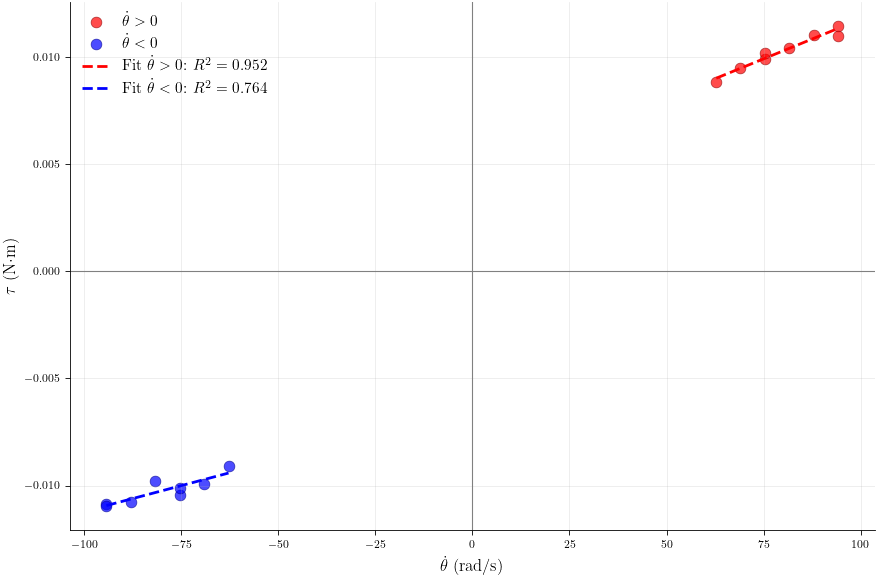

In [27]:
fig, ax = plt.subplots(figsize=(9, 6))

# Branche positive (rouge)
ax.scatter(theta_dot_pos, tau_pos, c='red', label=r'$\dot{\theta} > 0$',
           s=60, alpha=0.7, edgecolors='darkred', linewidth=0.5)

# Branche négative (bleu)
ax.scatter(theta_dot_neg, tau_neg, c='blue', label=r'$\dot{\theta} < 0$',
           s=60, alpha=0.7, edgecolors='darkblue', linewidth=0.5)

# Ajustement linéaire branche positive
if len(theta_dot_pos) > 1:
    fit_pos = stats.linregress(theta_dot_pos, tau_pos)
    slope_pos, intercept_pos, r_pos = fit_pos.slope, fit_pos.intercept, fit_pos.rvalue
    w_fit = np.linspace(min(theta_dot_pos), max(theta_dot_pos), 100)
    ax.plot(w_fit, intercept_pos + slope_pos * w_fit,
            'r--', linewidth=2, label=f'Fit $\\dot{{\\theta}}>0$: $R^2={r_pos**2:.3f}$')

    print(f"\nFit positif:")
    print(f"  tau = {intercept_pos:.6e} + {slope_pos:.6e}·theta_dot")
    print(f"  R² = {r_pos**2:.4f}")

# Ajustement linéaire branche négative
if len(theta_dot_neg) > 1:
    fit_neg = stats.linregress(theta_dot_neg, tau_neg)
    slope_neg, intercept_neg, r_neg = fit_neg.slope, fit_neg.intercept, fit_neg.rvalue
    w_fit = np.linspace(min(theta_dot_neg), max(theta_dot_neg), 100)
    ax.plot(w_fit, intercept_neg + slope_neg * w_fit,
            'b--', linewidth=2, label=f'Fit $\\dot{{\\theta}}<0$: $R^2={r_neg**2:.3f}$')

    print(f"\nFit négatif:")
    print(f"  tau = {intercept_neg:.6e} + {slope_neg:.6e}·theta_dot")
    print(f"  R² = {r_neg**2:.4f}")

# Axes de référence
ax.axhline(0, color='gray', linewidth=0.8, linestyle='-')
ax.axvline(0, color='gray', linewidth=0.8, linestyle='-')

ax.set_xlabel(r'$\dot{\theta}$ (rad/s)', fontsize=12)
ax.set_ylabel(r'$\tau$ (N$\cdot$m)', fontsize=12)
#ax.set_title('Expérience E1b - Identification de $\\tau_c$ et $b_m$', fontsize=13, pad=15)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3, linewidth=0.5)

plt.tight_layout()

Path("figures/id3").mkdir(parents=True, exist_ok=True)
fig.savefig('figures/id3/tau_vs_theta_dot.png', dpi=300, bbox_inches='tight')
print(f"\nFigure sauvegardée: figures/id3/tau_vs_theta_dot.png")

plt.show()


In [28]:
if len(theta_dot_pos) > 1 and len(theta_dot_neg) > 1:
    # Modèle : tau = tau_c·sgn(theta_dot) + b_m·theta_dot
    #
    # Pour theta_dot > 0 : tau = +tau_c + b_m·theta_dot  ->  intercept_pos = +tau_c
    # Pour theta_dot < 0 : tau = -tau_c + b_m·theta_dot  ->  intercept_neg = -tau_c

    b_m = (slope_pos + slope_neg) / 2

    tau_c_from_pos =  intercept_pos
    tau_c_from_neg = -intercept_neg
    tau_c = (tau_c_from_pos + tau_c_from_neg) / 2

    # Incertitude = erreur-type des régressions ⊕ écart entre branches
    tau_c_uncertainty = np.hypot(
        0.5 * np.hypot(fit_pos.intercept_stderr, fit_neg.intercept_stderr),
        0.5 * abs(tau_c_from_pos - tau_c_from_neg))
    b_m_uncertainty = np.hypot(
        0.5 * np.hypot(fit_pos.stderr, fit_neg.stderr),
        0.5 * abs(slope_pos - slope_neg))

    print("\n" + "="*70)
    print("RÉSULTATS - IDENTIFICATION DES PARAMÈTRES DE FROTTEMENT")
    print("="*70)
    print(f"\nCouple de frottement sec (Coulomb):")
    print(f"       τ_c = {tau_c:.4e} ± {tau_c_uncertainty:.2e} N·m")
    print(f"\nCoefficient de frottement visqueux:")
    print(f"       b_m = {b_m:.4e} ± {b_m_uncertainty:.2e} N·m·s/rad")
    print(f"\nQualité de l'identification:")
    print(f"       R² (positif)  = {r_pos**2:.4f}")
    print(f"       R² (négatif)  = {r_neg**2:.4f}")
    print(f"\nVérification de cohérence:")
    print(f"       τ_c (fit +) = {tau_c_from_pos:.4e} N·m")
    print(f"       τ_c (fit -) = {tau_c_from_neg:.4e} N·m")
    print(f"       b_m (fit +) = {slope_pos:.4e} N·m·s/rad")
    print(f"       b_m (fit -) = {slope_neg:.4e} N·m·s/rad")
    print("="*70)



RÉSULTATS - IDENTIFICATION DES PARAMÈTRES DE FROTTEMENT

Couple de frottement sec (Coulomb):
       τ_c = 5.3775e-03 ± 1.13e-03 N·m

Coefficient de frottement visqueux:
       b_m = 6.1200e-05 ± 1.44e-05 N·m·s/rad

Qualité de l'identification:
       R² (positif)  = 0.9520
       R² (négatif)  = 0.7643

Vérification de cohérence:
       τ_c (fit +) = 4.3701e-03 N·m
       τ_c (fit -) = 6.3849e-03 N·m
       b_m (fit +) = 7.4106e-05 N·m·s/rad
       b_m (fit -) = 4.8293e-05 N·m·s/rad


E1 - generation des figures


  -> figures\rapport\E1\tau_vs_theta_dot.png


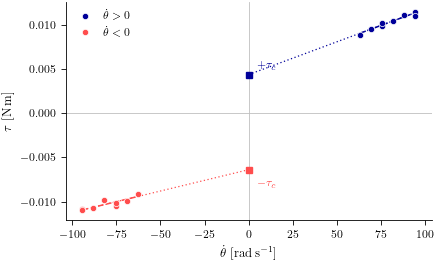

  -> figures\rapport\E1\coastdown.png


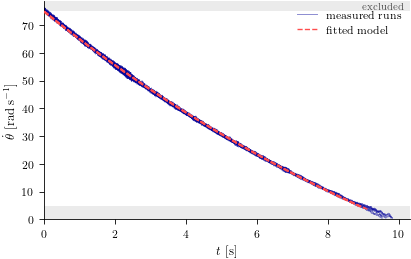

  I_h = 9.6638e-04 +/- 1.93e-06 kg.m2  (6 segments)


In [29]:
# =============================================================================
#  E1 - Figures du rapport
#  Prerequis : cellules E1b executees (theta_dot_pos/neg, tau_pos/neg,
#  fit_pos, fit_neg, tau_c, b_m, coast_segments).
# =============================================================================

print("E1 - generation des figures")

# -----------------------------------------------------------------------
#  Figure 1 : couple en regime permanent contre vitesse
# -----------------------------------------------------------------------
fig, ax = new_fig(12.0, 7.2)

# Axes de reference, traces en premier pour rester en arriere-plan
ax.axhline(0, color=C_GREYL, lw=0.6, zorder=1)
ax.axvline(0, color=C_GREYL, lw=0.6, zorder=1)

# Regressions prolongees jusqu'a l'axe, ce qui rend tau_c lisible
for td, tau, fit, col in ((theta_dot_pos, tau_pos, fit_pos, C_BLUE),
                          (theta_dot_neg, tau_neg, fit_neg, C_RED)):
    w_meas = np.linspace(td.min(), td.max(), 50)
    w_ext  = np.linspace(0, td.min() if td.mean() < 0 else td.max(), 50)
    ax.plot(w_ext, fit.intercept + fit.slope * w_ext,
            ls=(0, (1, 2)), color=col, lw=0.9, zorder=2)
    ax.plot(w_meas, fit.intercept + fit.slope * w_meas,
            ls="--", color=col, lw=1.1, zorder=3)

# Mesures
ax.plot(theta_dot_pos, tau_pos, "o", ms=4.5, color=C_BLUE,
        mec="white", mew=0.5, zorder=4, label=r"$\dot{\theta} > 0$")
ax.plot(theta_dot_neg, tau_neg, "o", ms=4.5, color=C_RED,
        mec="white", mew=0.5, zorder=4, label=r"$\dot{\theta} < 0$")

# Marquage des ordonnees a l'origine
for fit, col in ((fit_pos, C_BLUE), (fit_neg, C_RED)):
    ax.plot(0, fit.intercept, "s", ms=4, color=col, zorder=5)

ax.annotate(r"$+\tau_c$", xy=(0, fit_pos.intercept),
            xytext=(6, 4), textcoords="offset points",
            color=C_BLUE, fontsize=8)
ax.annotate(r"$-\tau_c$", xy=(0, fit_neg.intercept),
            xytext=(6, -12), textcoords="offset points",
            color=C_RED, fontsize=8)

ax.set_xlabel(r"$\dot{\theta}$ [\si{\radian\per\second}]")
ax.set_ylabel(r"$\tau$ [\si{\newton\meter}]")
ax.legend(loc="upper left")

save(fig, "E1", "tau_vs_theta_dot")
plt.show()

# -----------------------------------------------------------------------
#  Figure 2 : deceleration libre et modele ajuste
# -----------------------------------------------------------------------
def coast_model(t, J, w0, tau_c, b_m):
    wt = tau_c / b_m
    return (w0 + wt) * np.exp(-b_m * t / J) - wt

fig, ax = new_fig(12.0, 7.2)

w_top = max(s["w"].max() for s in coast_segments)

# Bandes exclues du fit
ax.axhspan(0, W_FIT_MIN, color=C_GREYL, alpha=0.30, lw=0, zorder=0)
ax.axhspan(W_FIT_MAX, w_top * 1.03, color=C_GREYL, alpha=0.30, lw=0, zorder=0)
ax.annotate("excluded", xy=(0.985, W_FIT_MAX + (w_top - W_FIT_MAX) * 4/3),
            xycoords=("axes fraction", "data"), ha="right", va="center",
            color=C_GREY, fontsize=7)

J_fits = []
for j, seg in enumerate(coast_segments):
    t, w = seg["t"], seg["w"]
    ax.plot(t, w, color=C_BLUE, lw=0.7, alpha=0.45, zorder=2,
            label="measured runs" if j == 0 else None)

    m = (w >= W_FIT_MIN) & (w <= W_FIT_MAX)
    if m.sum() < 10:
        continue
    t_f, w_f = t[m] - t[m][0], w[m]
    popt, _ = curve_fit(lambda tt, J: coast_model(tt, J, w_f[0], tau_c, b_m),
                        t_f, w_f, p0=[1.0e-3], maxfev=10000)
    J_fits.append(popt[0])
    ax.plot(t[m], coast_model(t_f, popt[0], w_f[0], tau_c, b_m),
            color=C_RED, lw=1.0, ls="--", zorder=3,
            label="fitted model" if j == 0 else None)

ax.set_xlabel(r"$t$ [\si{\second}]")
ax.set_ylabel(r"$\dot{\theta}$ [\si{\radian\per\second}]")
ax.set_ylim(0, w_top * 1.03)
ax.set_xlim(left=0)
ax.legend(loc="upper right")

save(fig, "E1", "coastdown")
plt.show()

J_arr = np.array(J_fits)
print(f"  I_h = {J_arr.mean():.4e} +/- {J_arr.std(ddof=1):.2e} kg.m2  "
      f"({len(J_arr)} segments)")


### 3.2 E2 — ball friction

In [30]:
# --- Extraction de l'enveloppe et du coefficient de frottement -------------
# Le pendule libre suit :  I·psi'' + b·psi' + m·g·R_eff·sin(psi) = 0
# Aux petites amplitudes, la solution est une sinusoide amortie dont
# l'enveloppe decroit en A(t) = A0·exp(-t/tau), avec tau = 2I/b.
#
# On mesure l'enveloppe par les extrema successifs de psi(t), puis on ajuste
# une exponentielle sur |psi_extrema| en fonction du temps.

AMP_FLOOR_DEG = 3.0     # plancher de bruit relevé
MIN_EXTREMA   = 8
PROM_FRAC     = 0.15    # proéminence minimale, en fraction de l'amplitude locale

for key in sorted(e2_runs):
    hoop, angle = key
    print(f"\n{hoop} {angle}° :")

    for run in e2_runs[key]:
        t, psi = run['t'], run['psi']
        dt = np.median(np.diff(t))

        # Proéminence minimale : écarte les extrema dus au bruit.
        # Distance minimale : au moins une demi-période plausible (f0 < 5 Hz).
        prom = PROM_FRAC * np.abs(psi).max()
        dist = max(1, int(0.1 / dt))

        i_max, _ = find_peaks( psi, prominence=prom, distance=dist)
        i_min, _ = find_peaks(-psi, prominence=prom, distance=dist)
        idx = np.sort(np.concatenate([i_max, i_min]))

        t_e, amp_e = t[idx], np.abs(psi[idx])

        m = amp_e >= np.radians(AMP_FLOOR_DEG)
        t_e, amp_e = t_e[m], amp_e[m]

        if len(t_e) < MIN_EXTREMA:
            print(f"  {run['label'][:38]:<38} IGNORÉ ({len(t_e)} extrema)")
            run['tau_env'] = None
            continue

        fit = stats.linregress(t_e, np.log(amp_e))
        tau_env, A0 = -1.0/fit.slope, np.exp(fit.intercept)
        f0 = 1.0 / (2 * np.median(np.diff(t_e)))

        run.update({'t_e': t_e, 'amp_e': amp_e, 'tau_env': tau_env,
                    'A0': A0, 'f0': f0, 'r2_env': fit.rvalue**2})

        print(f"  {run['label'][:38]:<38} {len(t_e):3d} extrema, "
              f"tau={tau_env:5.2f} s, f0={f0:.4f} Hz, R²={fit.rvalue**2:.4f}")



inner 30° :
  E2_inner_30deg_t01_20260810_162232      15 extrema, tau= 2.76 s, f0=1.3177 Hz, R²=0.9283
  E2_inner_30deg_t02_20260810_162323      23 extrema, tau= 2.51 s, f0=2.2465 Hz, R²=0.9557
  E2_inner_30deg_t03_20260810_162407      19 extrema, tau= 2.02 s, f0=2.2494 Hz, R²=0.9470
  E2_inner_30deg_t04_20260810_162504      23 extrema, tau= 2.26 s, f0=2.2402 Hz, R²=0.9299
  E2_inner_30deg_t05_20260810_162622      23 extrema, tau= 2.24 s, f0=2.2471 Hz, R²=0.9397

inner 40° :
  E2_inner_40deg_t01_20260804_155401     IGNORÉ (5 extrema)
  E2_inner_40deg_t02_20260804_155451     258 extrema, tau=123.76 s, f0=7.9651 Hz, R²=0.0072
  E2_inner_40deg_t02_20260804_155555      11 extrema, tau=10.14 s, f0=2.1625 Hz, R²=0.1753

outer 30° :
  E2_outer_30deg_t01_20260810_151314      22 extrema, tau= 3.94 s, f0=1.3049 Hz, R²=0.9721
  E2_outer_30deg_t01_20260810_151411      22 extrema, tau= 3.79 s, f0=1.3079 Hz, R²=0.9778
  E2_outer_30deg_t01_20260810_161238      22 extrema, tau= 4.02 s, f0=1.3058 Hz, 

In [31]:
# --- Coefficient de frottement de la bille --------------------------------
# Le fit de l'enveloppe donne tau_env = 2·I_psi/b_psi, ou I_psi = k·m_b·R_eff²
# est l'inertie du pendule dans la coordonnee psi.
#
# Le modele (fonction de dissipation D = ½·b_m·theta_dot² + ½·b_b·phi_dot²)
# definit b_b par rapport au SPIN de la bille. Le passage de psi a phi se fait
# par le rapport des bras de levier :   b_b = b_psi·(r_roll/R_eff)²

M_BALL  = 0.067        # kg
K_GEOM  = 1.552        # facteur d'inertie, geometrie deux rails
R_ROLL  = 10.64e-3     # m, rayon de roulement effectif
R_EFF   = {'outer': 91.6e-3, 'inner': 32.6e-3}   # m, cf. eq. two_rail_delta

print("="*70)
print("RÉSULTATS - FROTTEMENT DE LA BILLE")
print("="*70)

for key in sorted(e2_runs):
    hoop, angle = key
    runs = [r for r in e2_runs[key] if r.get('tau_env')]
    if not runs:
        continue

    R = R_EFF[hoop]
    I_psi = K_GEOM * M_BALL * R**2
    ratio = (R_ROLL / R)**2

    b_psi = np.array([2*I_psi / r['tau_env'] for r in runs])
    b_b   = b_psi * ratio
    f0    = np.array([r['f0'] for r in runs])

    print(f"\n{hoop} {angle}°  ({len(runs)} essais, R_eff={R*1e3:.1f} mm, "
          f"I_psi={I_psi:.4e} kg·m², (r_roll/R_eff)²={ratio:.5f})")
    for r, bp, bb in zip(runs, b_psi, b_b):
        print(f"  t{r['trial']:02d}: tau={r['tau_env']:5.2f} s, "
              f"f0={r['f0']:.4f} Hz, b_psi={bp:.4e}, b_b={bb:.4e}")
    print(f"  ---> f0    = {f0.mean():.4f} ± {f0.std(ddof=1):.4f} Hz")
    print(f"  ---> b_psi = {b_psi.mean():.4e} ± {b_psi.std(ddof=1):.2e} N·m·s/rad")
    print(f"  ---> b_b   = {b_b.mean():.4e} ± {b_b.std(ddof=1):.2e} N·m·s/rad")

print("="*70)


RÉSULTATS - FROTTEMENT DE LA BILLE

inner 30°  (5 essais, R_eff=32.6 mm, I_psi=1.1051e-04 kg·m², (r_roll/R_eff)²=0.10652)
  t01: tau= 2.76 s, f0=1.3177 Hz, b_psi=8.0070e-05, b_b=8.5294e-06
  t02: tau= 2.51 s, f0=2.2465 Hz, b_psi=8.8079e-05, b_b=9.3826e-06
  t03: tau= 2.02 s, f0=2.2494 Hz, b_psi=1.0936e-04, b_b=1.1650e-05
  t04: tau= 2.26 s, f0=2.2402 Hz, b_psi=9.7685e-05, b_b=1.0406e-05
  t05: tau= 2.24 s, f0=2.2471 Hz, b_psi=9.8791e-05, b_b=1.0524e-05
  ---> f0    = 2.0602 ± 0.4151 Hz
  ---> b_psi = 9.4798e-05 ± 1.12e-05 N·m·s/rad
  ---> b_b   = 1.0098e-05 ± 1.19e-06 N·m·s/rad

inner 40°  (2 essais, R_eff=32.6 mm, I_psi=1.1051e-04 kg·m², (r_roll/R_eff)²=0.10652)
  t02: tau=123.76 s, f0=7.9651 Hz, b_psi=1.7859e-06, b_b=1.9024e-07
  t02: tau=10.14 s, f0=2.1625 Hz, b_psi=2.1792e-05, b_b=2.3214e-06
  ---> f0    = 5.0638 ± 4.1031 Hz
  ---> b_psi = 1.1789e-05 ± 1.41e-05 N·m·s/rad
  ---> b_b   = 1.2558e-06 ± 1.51e-06 N·m·s/rad

outer 30°  (11 essais, R_eff=91.6 mm, I_psi=8.7248e-04 kg·m², (r

In [32]:
# --- Diagnostic visqueux vs Coulomb ---------------------------------------
# Deux mecanismes de dissipation donnent des decroissances d'amplitude
# differentes, mesurables sur les extrema successifs A_k (k = indice) :
#
#   visqueux :  A_k = A_0·exp(-gamma·k)   -> decroissance geometrique
#   Coulomb  :  A_k = A_0 - c·k           -> decroissance lineaire
#
# Les deux sont ajustes dans le domaine des AMPLITUDES (pas en log), afin que
# la comparaison des residus porte sur la meme grandeur. Comparer un R² obtenu
# sur ln(A) a un R² obtenu sur A n'aurait pas de sens : les transformations
# de la variable dependante changent la ponderation des points.

print("="*70)
print("COMPARAISON DES MODÈLES D'AMORTISSEMENT")
print("="*70)

for key in sorted(e2_runs):
    hoop, angle = key
    runs = [r for r in e2_runs[key] if r.get('tau_env')]
    if not runs:
        continue

    print(f"\n{hoop} {angle}° :")
    print(f"  {'essai':<8} {'n':>4} {'RMSE exp':>10} {'RMSE lin':>10} "
          f"{'rapport':>9} {'meilleur':>10}")

    for run in runs:
        A = run['amp_e']
        k = np.arange(len(A))

        # Modele visqueux : fit exponentiel (regression sur ln A, puis
        # residus evalues dans le domaine des amplitudes)
        f_exp = stats.linregress(k, np.log(A))
        A_exp = np.exp(f_exp.intercept) * np.exp(f_exp.slope * k)
        rmse_exp = np.sqrt(np.mean((A - A_exp)**2))

        # Modele Coulomb : fit lineaire
        f_lin = stats.linregress(k, A)
        A_lin = f_lin.intercept + f_lin.slope * k
        rmse_lin = np.sqrt(np.mean((A - A_lin)**2))

        run.update({'A_exp': A_exp, 'A_lin': A_lin,
                    'rmse_exp': rmse_exp, 'rmse_lin': rmse_lin})

        best = 'visqueux' if rmse_exp < rmse_lin else 'Coulomb'
        print(f"  t{run['trial']:02d}     {len(A):>4} "
              f"{np.degrees(rmse_exp):>9.3f}° {np.degrees(rmse_lin):>9.3f}° "
              f"{rmse_lin/rmse_exp:>9.2f} {best:>10}")

print("\n" + "="*70)


COMPARAISON DES MODÈLES D'AMORTISSEMENT

inner 30° :
  essai       n   RMSE exp   RMSE lin   rapport   meilleur
  t01       15     2.053°     0.820°      0.40    Coulomb
  t02       23     2.471°     1.164°      0.47    Coulomb
  t03       19     1.392°     1.153°      0.83    Coulomb
  t04       23     2.823°     1.336°      0.47    Coulomb
  t05       23     2.705°     1.085°      0.40    Coulomb

inner 40° :
  essai       n   RMSE exp   RMSE lin   rapport   meilleur
  t02      258     9.928°     9.643°      0.97    Coulomb
  t02       11     8.940°     9.003°      1.01   visqueux

outer 30° :
  essai       n   RMSE exp   RMSE lin   rapport   meilleur
  t01       22     2.544°     2.987°      1.17   visqueux
  t01       22     2.482°     2.530°      1.02   visqueux
  t01       22     2.232°     2.311°      1.04   visqueux
  t01       21     2.140°     1.969°      0.92    Coulomb
  t01       17     1.913°     1.304°      0.68    Coulomb
  t02       21     2.868°     2.500°      0.87  

In [33]:
# --- Decrement logarithmique ----------------------------------------------
# Formulation de l'eq. (log_decrement) du memoire. Deux extrema successifs
# sont separes d'une DEMI-periode, d'ou le facteur 2 qui ramene delta a une
# periode complete :
#     delta = (2/(n-1))·somme[ ln(A_k / A_{k+1}) ]
#     zeta  = delta / sqrt(4·pi² + delta²)
#
# b_psi = 2·zeta·omega_0·m_b·k_geom·R_eff²   puis   b_b = b_psi·(r_roll/R_eff)²

print("="*70)
print("DÉCRÉMENT LOGARITHMIQUE")
print("="*70)

for key in sorted(e2_runs):
    hoop, angle = key
    runs = [r for r in e2_runs[key] if r.get('tau_env')]
    if not runs:
        continue

    R = R_EFF[hoop]
    I_psi = K_GEOM * M_BALL * R**2
    ratio = (R_ROLL / R)**2

    d_l, z_l, bp_l, bb_l = [], [], [], []

    print(f"\n{hoop} {angle}°  (R_eff={R*1e3:.1f} mm)")
    for run in runs:
        A = run['amp_e']
        delta = 2.0 * np.mean(np.log(A[:-1] / A[1:]))
        zeta  = delta / np.sqrt(4*np.pi**2 + delta**2)

        omega_0 = 2*np.pi*run['f0']
        b_psi   = 2 * zeta * omega_0 * I_psi
        b_b     = b_psi * ratio

        d_l.append(delta); z_l.append(zeta)
        bp_l.append(b_psi); bb_l.append(b_b)

        print(f"  t{run['trial']:02d}: delta={delta:.4f}, zeta={zeta:.5f}, "
              f"b_psi={b_psi:.4e}, b_b={b_b:.4e}")

    d_l, z_l = np.array(d_l), np.array(z_l)
    bp_l, bb_l = np.array(bp_l), np.array(bb_l)

    print(f"  ---> delta = {d_l.mean():.4f} ± {d_l.std(ddof=1):.4f}")
    print(f"  ---> zeta  = {z_l.mean():.5f} ± {z_l.std(ddof=1):.5f}")
    print(f"  ---> b_psi = {bp_l.mean():.4e} ± {bp_l.std(ddof=1):.2e} N·m·s/rad")
    print(f"  ---> b_b   = {bb_l.mean():.4e} ± {bb_l.std(ddof=1):.2e} N·m·s/rad")

print("="*70)


DÉCRÉMENT LOGARITHMIQUE

inner 30°  (R_eff=32.6 mm)
  t01: delta=0.3157, zeta=0.05019, b_psi=9.1834e-05, b_b=9.7826e-06
  t02: delta=0.1860, zeta=0.02960, b_psi=9.2330e-05, b_b=9.8354e-06
  t03: delta=0.1915, zeta=0.03046, b_psi=9.5140e-05, b_b=1.0135e-05
  t04: delta=0.2052, zeta=0.03265, b_psi=1.0156e-04, b_b=1.0819e-05
  t05: delta=0.2034, zeta=0.03236, b_psi=1.0098e-04, b_b=1.0757e-05
  ---> delta = 0.2204 ± 0.0539
  ---> zeta  = 0.03505 ± 0.00856
  ---> b_psi = 9.6370e-05 ± 4.65e-06 N·m·s/rad
  ---> b_b   = 1.0266e-05 ± 4.96e-07 N·m·s/rad

inner 40°  (R_eff=32.6 mm)
  t02: delta=0.0096, zeta=0.00152, b_psi=1.6855e-05, b_b=1.7954e-06
  t02: delta=0.2603, zeta=0.04140, b_psi=1.2432e-04, b_b=1.3243e-05
  ---> delta = 0.1350 ± 0.1773
  ---> zeta  = 0.02146 ± 0.02820
  ---> b_psi = 7.0587e-05 ± 7.60e-05 N·m·s/rad
  ---> b_b   = 7.5193e-06 ± 8.09e-06 N·m·s/rad

outer 30°  (R_eff=91.6 mm)
  t01: delta=0.2153, zeta=0.03424, b_psi=4.8990e-04, b_b=6.6100e-06
  t01: delta=0.2111, zeta=0.0335

In [34]:
# =============================================================================
#  E2 - Figures du rapport
#  Prerequis : cellules E2 executees (e2_runs avec psi corrige, t_e, amp_e,
#  tau_env, A0, f0).
# =============================================================================

# --- Configurations retenues pour le rapport ------------------------------
# Meme angle de lacher sur les deux pistes, pour que la comparaison entre
# elles ne melange pas deux variables.
CONFIGS = [('outer', 30), ('inner', 30)]

PSI0_MAX_DEG = 50.0     # essais demarrant au-dessus sont ecartes
T_CROP       = 15.0     # fenetre affichee
AMP_MIN_DEG  = 8.0      # bande d'amplitude retenue pour le decrement
AMP_MAX_DEG  = 40.0
SHIFT        = 0.20     # recalage temporel [s]
SHIFT_RUNS   = {}       # {(hoop, angle): trial} ; laisser vide si inutile
FORCE_TRIAL  = {('inner', 30): 3}       # {(hoop, angle): trial} ; sinon selection par mediane

print("E2 - generation des figures")

def _retained(key):
    """Essais exploitables d'une configuration, filtres sur l'angle de lacher."""
    out = []
    for r in e2_runs.get(key, []):
        if not r.get("tau_env"):
            continue
        if np.degrees(np.abs(r["psi"]).max()) > PSI0_MAX_DEG:
            continue
        out.append(r)
    return out

def _fit_band(run):
    """Reajuste les deux modeles sur la bande d'amplitude."""
    A_all = np.degrees(run["amp_e"])
    band  = (A_all >= AMP_MIN_DEG) & (A_all <= AMP_MAX_DEG)
    if band.sum() < 5:
        return None
    k, A  = np.arange(len(A_all))[band], A_all[band]
    f_exp = stats.linregress(k, np.log(A))
    f_lin = stats.linregress(k, A)
    A_exp = np.exp(f_exp.intercept) * np.exp(f_exp.slope * k)
    A_lin = f_lin.intercept + f_lin.slope * k
    return dict(k=k, A=A, A_exp=A_exp, A_lin=A_lin, n_all=len(A_all),
                rmse_exp=np.sqrt(np.mean((A - A_exp) ** 2)),
                rmse_lin=np.sqrt(np.mean((A - A_lin) ** 2)),
                tau_band=-np.median(np.diff(run["t_e"])) / f_exp.slope)

def _pick(key, runs):
    """Essai retenu : impose si demande, sinon celui de tau median."""
    forced = FORCE_TRIAL.get(key)
    if forced is None:
        taus = np.array([r["tau_env"] for r in runs])
        return runs[int(np.argmin(np.abs(taus - np.median(taus))))], False
    match = [r for r in runs if r["trial"] == forced]
    if not match:
        raise ValueError(f"{key}: essai t{forced:02d} absent des essais retenus, "
                         f"disponibles {[r['trial'] for r in runs]}")
    return match[0], True

# -----------------------------------------------------------------------
#  Recalage temporel, applique une seule fois meme si la cellule est relancee
# -----------------------------------------------------------------------
for key, trial in SHIFT_RUNS.items():
    for r in e2_runs.get(key, []):
        if r["trial"] != trial:
            continue
        if "t_orig" not in r:
            r["t_orig"] = r["t"].copy()
            if "t_e" in r:
                r["t_e_orig"] = r["t_e"].copy()
        r["t"] = r["t_orig"] - SHIFT
        if "t_e_orig" in r:
            r["t_e"] = r["t_e_orig"] - SHIFT
        print(f"  {key} t{trial:02d} : decale de {SHIFT:.3f} s")


E2 - generation des figures


  -> figures\rapport\E2\free_response_outer.png


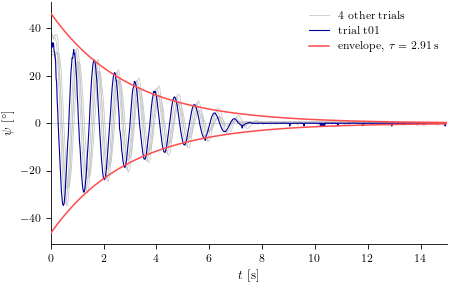

  -> figures\rapport\E2\free_response_inner.png


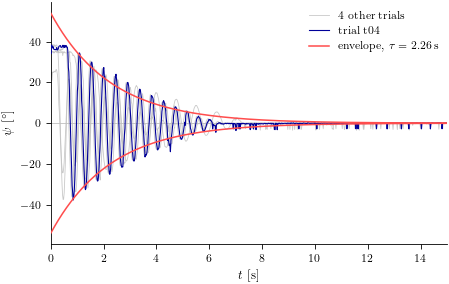

In [35]:
# -----------------------------------------------------------------------
#  Figure 1 : reponse libre, ensemble des essais et essai representatif
#
#  Un essai est trace au premier plan plutot qu'une moyenne : les essais ne
#  partagent ni la phase ni exactement la frequence, donc leur moyenne
#  s'annule progressivement par interference et decroit plus vite que la
#  realite. L'essai retenu est celui dont tau est le plus proche de la mediane.
# -----------------------------------------------------------------------
for key in CONFIGS:
    hoop, angle = key
    runs = _retained(key)
    if not runs:
        print(f"  {key} : aucun essai retenu")
        continue

    taus = np.array([r["tau_env"] for r in runs])
    i_rep = int(np.argmin(np.abs(taus - np.median(taus))))

    fig, ax = new_fig(13.0, 8.0)
    ax.axhline(0, color=C_GREYL, lw=0.6, zorder=1)

    # Ensemble des essais, en arriere-plan
    for j, run in enumerate(runs):
        if j == i_rep:
            continue
        m = run["t"] <= T_CROP
        ax.plot(run["t"][m], np.degrees(run["psi"][m]),
                color=C_GREYL, lw=0.6, alpha=0.85, zorder=2,
                label=f"{len(runs)-1} other trials" if j == (1 if i_rep == 0 else 0) else None)

    # Essai representatif, au premier plan
    rep = runs[i_rep]
    m = rep["t"] <= T_CROP
    ax.plot(rep["t"][m], np.degrees(rep["psi"][m]),
            color=C_BLUE, lw=0.8, zorder=3,
            label=rf"trial t{rep['trial']:02d}")

    # Enveloppe, sur les parametres medians de la configuration
    tau_m = np.median(taus)
    A0_m  = np.median([r["A0"] for r in runs])
    t_env = np.linspace(0, T_CROP, 400)
    env   = np.degrees(A0_m * np.exp(-t_env / tau_m))
    ax.plot(t_env,  env, color=C_RED, lw=1.1, zorder=4,
            label=rf"envelope, $\tau = \SI{{{tau_m:.2f}}}{{\second}}$")
    ax.plot(t_env, -env, color=C_RED, lw=1.1, zorder=4)

    ax.set_xlabel(r"$t$ [\si{\second}]")
    ax.set_ylabel(r"$\psi$ [\si{\degree}]")
    ax.set_xlim(0, T_CROP)
    ax.legend(loc="upper right")

    save(fig, "E2", f"free_response_{hoop}")
    plt.show()


  -> figures\rapport\E2\decrement_outer_30deg.png


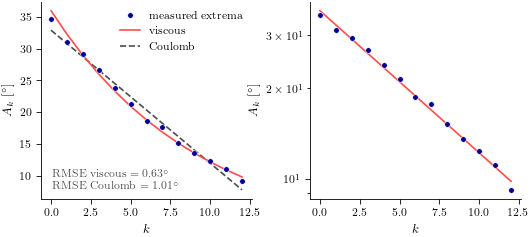

  outer 30 deg : essai t01, 13/17 extrema retenus
        tau tous extrema = 2.913 s, sur la bande = 3.506 s, ecart = +20.4 %


  -> figures\rapport\E2\decrement_inner_30deg.png


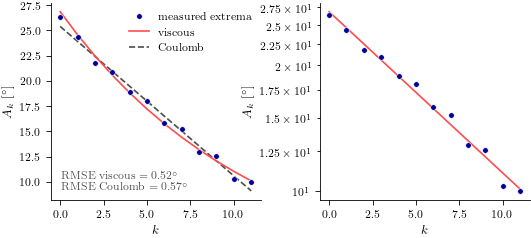

  inner 30 deg : essai t03 (impose), 12/19 extrema retenus
        tau tous extrema = 2.021 s, sur la bande = 2.503 s, ecart = +23.9 %


In [36]:
# -----------------------------------------------------------------------
#  Figure 2 : extrema d'un essai et les deux modeles candidats
# -----------------------------------------------------------------------
for key in CONFIGS:
    hoop, angle = key
    runs = _retained(key)
    if not runs:
        continue

    run, forced = _pick(key, runs)
    d = _fit_band(run)
    if d is None:
        print(f"  {key} : bande trop etroite, essai ignore")
        continue

    fig, axes = new_fig(15.7, 6.5, ncols=2)

    for ax, logscale in zip(axes, (False, True)):
        plot = ax.semilogy if logscale else ax.plot
        plot(d["k"], d["A"], "o", ms=4, color=C_BLUE, mec="white", mew=0.4,
             zorder=4, label="measured extrema")
        plot(d["k"], d["A_exp"], "-", lw=1.2, color=C_RED, zorder=3,
             label="viscous")
        if not logscale:
            plot(d["k"], d["A_lin"], "--", lw=1.2, color=C_GREY, zorder=2,
                 label="Coulomb")
        ax.set_xlabel(r"$k$")
        ax.set_ylabel(r"$A_k$ [\si{\degree}]")

    axes[0].legend(loc="upper right")
    axes[0].annotate(
        rf"RMSE viscous $=\SI{{{d['rmse_exp']:.2f}}}{{\degree}}$"
        "\n"
        rf"RMSE Coulomb $=\SI{{{d['rmse_lin']:.2f}}}{{\degree}}$",
        xy=(0.05, 0.15), xycoords="axes fraction",
        ha="left", va="top", fontsize=8, color=C_GREY)

    fig.subplots_adjust(wspace=0.28)
    save(fig, "E2", f"decrement_{hoop}_{angle}deg")
    plt.show()

    print(f"  {hoop} {angle} deg : essai t{run['trial']:02d}"
          f"{' (impose)' if forced else ''}, "
          f"{len(d['k'])}/{d['n_all']} extrema retenus")
    print(f"        tau tous extrema = {run['tau_env']:.3f} s, "
          f"sur la bande = {d['tau_band']:.3f} s, "
          f"ecart = {100*(d['tau_band']/run['tau_env']-1):+.1f} %")


### 3.3 E3 — cross-validation

In [37]:
# =============================================================================
#  E3 - Figures du rapport
#  Prerequis : cellules 50, 51 et 53 executees (e3_runs avec psi corrige de
#  l'offset, theta et theta_dot interpoles sur la grille camera).
# =============================================================================

# --- Parametres, geometrie corrigee a deux rails (voir sec: parameters) ----
G      = 9.81
M_B    = 67.0e-3        # [kg]
R_B    = 12.5e-3        # [m]
R_ROLL = 10.64e-3       # [m]   rayon de roulement effectif
K_IN   = 1.552          # [-]   facteur d'inertie
B_B    = 6.484e-6       # [N.m.s/rad]
I_B    = 0.4 * M_B * R_B ** 2

# Rayon effectif et rayon de contact cote cerceau, par piste.
# R_CONTACT est a recouper avec e3_two_rail_geometry.m avant remise.
GEOM = {
    'outer': dict(R_eff=91.6e-3,  R_contact=103.5e-3),
    'inner': dict(R_eff=32.6e-3,  R_contact=44.5e-3),
}

T_STEP    = 0.50        # instant de l'echelon [s]
SG_WIN_S  = 0.10        # fenetre de derivation Savitzky-Golay [s]
SG_ORDER  = 3
F_MAX_HZ  = 3.5         # borne haute plausible pour la detection d'extrema

# --- Selection des essais ------------------------------------------------
# La sauvegarde est prise sur la liste complete, et refusee si elle est vide,
# pour ne pas figer un etat deja filtre par une execution anterieure.
STEP_KEEP = "step45deg"

if 'e3_runs_all' not in globals() or not any(e3_runs_all.values()):
    if not any(e3_runs.values()):
        raise RuntimeError(
            "e3_runs est vide : reexecuter les cellules de chargement E3 "
            "(50, 51 et 53) avant ce bloc.")
    e3_runs_all = {h: list(v) for h, v in e3_runs.items()}

e3_runs = {h: [r for r in v if STEP_KEEP in r['label']]
           for h, v in e3_runs_all.items()}

for hoop in sorted(e3_runs):
    print(f"  {hoop} : {len(e3_runs[hoop])}/{len(e3_runs_all[hoop])} retenu(s)")
    for r in e3_runs[hoop]:
        print(f"    t{r['trial']:02d}  theta final = "
              f"{np.degrees(r['theta'][-1]):5.2f} deg")

if not any(e3_runs.values()):
    raise RuntimeError(f"aucun essai ne correspond a '{STEP_KEEP}'")

print("\nE3 - generation des figures")

def _simulate(run, hoop):
    """Integre le sous-systeme de la bille, mouvement du cerceau impose.

    theta_dot et theta_ddot mesures entrent comme entree exogene. Seuls psi
    et psi_dot sont integres, ce qui valide la dynamique de la bille sans
    faire intervenir l'identification du moteur.
    """
    g = GEOM[hoop]
    R_eff, R_c = g['R_eff'], g['R_contact']

    M22 = M_B * K_IN * R_eff ** 2
    M21 = -I_B * R_c * R_eff / R_ROLL ** 2
    C21 = -B_B * R_c * R_eff / R_ROLL ** 2
    C22 =  B_B * R_eff ** 2 / R_ROLL ** 2

    t, thd = run['t'], run['theta_dot']

    # Acceleration du cerceau par derivation lissee de la vitesse mesuree
    dt  = np.median(np.diff(t))
    win = int(round(SG_WIN_S / dt)) | 1
    win = max(win, SG_ORDER + 2)
    thdd = savgol_filter(thd, win, SG_ORDER, deriv=1, delta=dt)

    f_thd  = interp1d(t, thd,  kind='cubic', fill_value='extrapolate')
    f_thdd = interp1d(t, thdd, kind='cubic', fill_value='extrapolate')

    def rhs(tt, x):
        psi, psid = x
        acc = -(M21 * f_thdd(tt) + C21 * f_thd(tt) + C22 * psid
                + M_B * G * R_eff * np.sin(psi)) / M22
        return [psid, acc]

    # Conditions initiales prises a l'instant de l'echelon
    i0    = int(np.searchsorted(t, T_STEP))
    psi0  = run['psi'][i0]
    psid0 = np.gradient(run['psi'], t)[i0]

    sol = solve_ivp(rhs, (t[i0], t[-1]), [psi0, psid0],
                    t_eval=t[i0:], rtol=1e-9, atol=1e-11, method='RK45')
    return t[i0:], sol.y[0]

def _freq(t, psi):
    """Frequence d'oscillation, estimee sur les intervalles entre extrema.

    La distance minimale entre deux extrema borne mecaniquement la frequence
    detectable, ce qui evite de compter du bruit sur la fin de l'essai, ou
    l'oscillation s'est amortie.
    """
    prom = 0.25 * np.abs(psi - psi.mean()).max()
    dist = max(1, int(1.0 / (2 * F_MAX_HZ * np.median(np.diff(t)))))
    i_max, _ = find_peaks( psi, prominence=prom, distance=dist)
    i_min, _ = find_peaks(-psi, prominence=prom, distance=dist)
    idx = np.sort(np.concatenate([i_max, i_min]))
    if len(idx) < 3:
        return np.nan
    return 1.0 / (2 * np.median(np.diff(t[idx])))


  inner : 6/11 retenu(s)
    t01  theta final = 44.89 deg
    t01  theta final = 44.22 deg
    t02  theta final = 45.00 deg
    t03  theta final = 45.00 deg
    t04  theta final = 45.00 deg
    t05  theta final = 45.02 deg
  outer : 14/22 retenu(s)
    t00  theta final = 43.44 deg
    t01  theta final = 45.78 deg
    t02  theta final = 43.30 deg
    t03  theta final = 43.44 deg
    t04  theta final = 43.50 deg
    t05  theta final = 45.09 deg
    t06  theta final = 45.02 deg
    t07  theta final = 45.00 deg
    t08  theta final = 45.06 deg
    t09  theta final = 44.98 deg
    t10  theta final = 44.89 deg
    t11  theta final = 45.04 deg
    t12  theta final = 44.93 deg
    t20  theta final = 44.83 deg

E3 - generation des figures


In [38]:
# --- Recalage sur la position de repos finale -----------------------------
# La bille finit necessairement au point bas de la piste, ou psi vaut zero.
# La fenetre d'avant echelon donne la meme valeur a environ 3 deg pres, ce
# qui est l'incertitude attribuee au centre de reference. Le recalage final
# est retenu, la position de repos y etant physiquement garantie.
TAIL_FRAC = 0.25

print("Recalage sur la position de repos finale")
for hoop in sorted(e3_runs):
    print(f"  {hoop}")
    for r in e3_runs[hoop]:
        if 'psi_pre_recal' not in r:
            r['psi_pre_recal'] = r['psi'].copy()
        t = r['t']
        m = t >= t[0] + (1 - TAIL_FRAC) * (t[-1] - t[0])
        off = np.median(r['psi_pre_recal'][m])
        r['psi'] = r['psi_pre_recal'] - off
        print(f"    t{r['trial']:02d} : offset retire "
              f"{np.degrees(off):+6.2f} deg, "
              f"psi final {np.degrees(np.median(r['psi'][m])):+5.2f} deg")

# --- Rejet des essais dont la detection a decroche ------------------------
# Un echelon de 45 deg ne peut pas amener la bille bien au-dela de cette
# valeur : une excursion nettement superieure signale que le detecteur a
# suivi autre chose que la bille sur une partie de l'essai.
PSI_MAX_DEG = 60.0

for hoop in sorted(e3_runs):
    kept = []
    for r in e3_runs[hoop]:
        pmax = np.degrees(np.abs(r['psi']).max())
        if pmax > PSI_MAX_DEG:
            print(f"  {hoop} t{r['trial']:02d} : ecarte, "
                  f"psi max = {pmax:.1f} deg")
        else:
            kept.append(r)
    e3_runs[hoop] = kept
    print(f"  {hoop} : {len(kept)} essai(s) retenu(s)")


Recalage sur la position de repos finale
  inner
    t01 : offset retire  +3.64 deg, psi final +0.00 deg
    t01 : offset retire  +0.04 deg, psi final +0.00 deg
    t02 : offset retire  +4.23 deg, psi final +0.00 deg
    t03 : offset retire  +3.09 deg, psi final +0.00 deg
    t04 : offset retire  -2.28 deg, psi final +0.00 deg
    t05 : offset retire  +0.74 deg, psi final +0.00 deg
  outer
    t00 : offset retire  +1.30 deg, psi final +0.00 deg
    t01 : offset retire  -2.46 deg, psi final +0.00 deg
    t02 : offset retire  +1.48 deg, psi final +0.00 deg
    t03 : offset retire  +0.22 deg, psi final +0.00 deg
    t04 : offset retire  +0.39 deg, psi final +0.00 deg
    t05 : offset retire  +1.01 deg, psi final +0.00 deg
    t06 : offset retire  -2.63 deg, psi final +0.00 deg
    t07 : offset retire  +2.81 deg, psi final +0.00 deg
    t08 : offset retire  +3.19 deg, psi final +0.00 deg
    t09 : offset retire  +0.62 deg, psi final -0.00 deg
    t10 : offset retire  +0.92 deg, psi final +

  -> figures\rapport\E3\theta_psi_inner.png


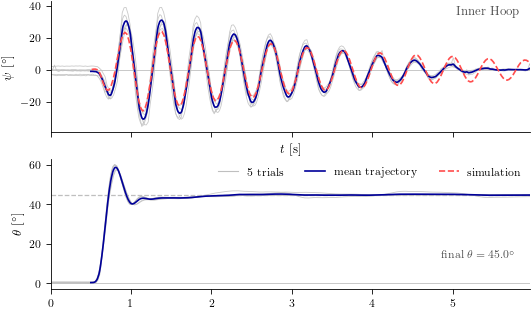


  Inner Hoop : 5 essais
    RMSE par essai : min 18.13, median 23.06, max 26.43 deg
    RMSE sur la moyenne : 19.77 deg
    f mesuree = 2.2870 Hz, f simulee = 2.2612 Hz, eps_f = 1.13 %


  -> figures\rapport\E3\theta_psi_outer.png


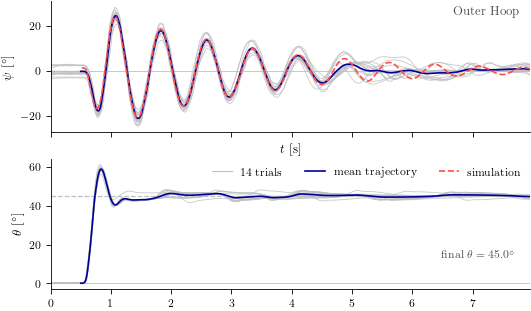


  Outer Hoop : 14 essais
    RMSE par essai : min 13.16, median 16.38, max 18.15 deg
    RMSE sur la moyenne : 15.59 deg
    f mesuree = 1.3184 Hz, f simulee = 1.3105 Hz, eps_f = 0.60 %


In [39]:
# -----------------------------------------------------------------------
#  Figure : position du cerceau et de la bille sur les essais
# -----------------------------------------------------------------------
HOOP_LABELS = {
    "outer": "Outer Hoop",
    "outer_hoop": "Outer Hoop",
    "inner": "Inner Hoop",
    "inner_hoop_in": "Inner Hoop",
    "inner_hoop_out": "Inner Hoop",
}

for hoop in sorted(e3_runs):
    runs = e3_runs[hoop]
    hoop_label = HOOP_LABELS.get(hoop, str(hoop))

    t_end = min(r['t'][-1] for r in runs)
    t_grid = np.linspace(T_STEP, t_end, 600)

    # Moyennes inter-essais sur une grille commune.
    theta_grid = np.array([
        np.interp(t_grid, r['t'], r['theta']) for r in runs
    ])
    theta_mean = theta_grid.mean(axis=0)

    psi_grid = np.array([
        np.interp(t_grid, r['t'], r['psi']) for r in runs
    ])
    psi_mean = psi_grid.mean(axis=0)

    fig, axes = new_fig(15.7, 9.5, nrows=2, sharex=True,
                        gridspec_kw=dict(height_ratios=[1, 1]))

    # Une seule entree de legende pour chaque style, partagee par les deux panneaux.
    trial_handle, = axes[0].plot([], [], color=C_GREYL, lw=0.8,
                                 label=f"{len(runs)} trials")
    mean_handle, = axes[0].plot([], [], color=C_BLUE, lw=1.2,
                                label="mean trajectory")
    simulation_handle, = axes[1].plot([], [], color=C_RED, lw=1.2, ls="--",
                                      label="simulation")

    # Position de la bille : essais individuels en gris, moyenne et simulation.
    ax = axes[0]
    ax.axhline(0, color=C_GREYL, lw=0.6, zorder=1)
    for run in runs:
        ax.plot(run['t'], np.degrees(run['psi']),
                color=C_GREYL, lw=0.6, alpha=0.85, zorder=2)
    ax.plot(t_grid, np.degrees(psi_mean), color=C_BLUE, lw=1.2,
            zorder=3)

    # Simulation sur l'essai le plus proche de la moyenne.
    d = [np.sqrt(np.mean((np.interp(t_grid, r['t'], r['psi']) - psi_mean) ** 2))
         for r in runs]
    rep = runs[int(np.argmin(d))]
    t_s, psi_s = _simulate(rep, hoop)
    ax.plot(t_s, -np.degrees(psi_s), color=C_RED, lw=1.2, ls="--",
            zorder=4)
    ax.text(0.98, 0.96, hoop_label, transform=ax.transAxes,
            ha="right", va="top", fontsize=9, color=C_GREY)
    ax.set_ylabel(r"$\psi$ [\si{\degree}]")
    ax.set_xlabel(r"$t$ [\si{\second}]")

    for ax in axes:
        ax.set_xlim(0, t_end)
    axes[1].legend(handles=[trial_handle, mean_handle, simulation_handle],
                   labels=[h.get_label() for h in
                           (trial_handle, mean_handle, simulation_handle)],
                   loc="upper right", ncol=3)

    # Position du cerceau : essais individuels en gris, moyenne en bleu.
    ax = axes[1]
    ax.axhline(0, color=C_GREYL, lw=0.6, zorder=1)
    ax.axhline(45, color=C_GREYL, lw=0.9, ls="--", zorder=1,
               label="_nolegend_")
    for run in runs:
        ax.plot(run['t'], np.degrees(run['theta']),
                color=C_GREYL, lw=0.6, alpha=0.85, zorder=2)
    ax.plot(t_grid, np.degrees(theta_mean), color=C_BLUE, lw=1.2,
            zorder=3)
    th_fin = np.degrees(np.median([r['theta'][-1] for r in runs]))
    ax.annotate(rf"final $\theta = \SI{{{th_fin:.1f}}}{{\degree}}$",
                xy=(0.97, 0.30), xycoords="axes fraction",
                ha="right", va="top", fontsize=8, color=C_GREY)
    ax.set_ylabel(r"$\theta$ [\si{\degree}]")

    save(fig, "E3", f"theta_psi_{hoop}")
    plt.show()

    # --- Criteres du rapport --------------------------------------------
    rmse = []
    for run in runs:
        ts, ps = _simulate(run, hoop)
        e = np.degrees(np.interp(ts, run['t'], run['psi']) - ps)
        rmse.append(np.sqrt(np.mean(e ** 2)))
    rmse = np.array(rmse)

    m_grid = t_grid >= T_STEP
    e_mean = np.degrees(np.interp(t_s, t_grid, psi_mean) - psi_s)
    rmse_mean = np.sqrt(np.mean(e_mean ** 2))

    f_meas = _freq(t_grid[m_grid], psi_mean[m_grid])
    f_sim  = _freq(t_s, psi_s)
    eps_f  = abs(f_sim - f_meas) / f_meas

    print(f"\n  {hoop_label} : {len(runs)} essais")
    print(f"    RMSE par essai : min {rmse.min():.2f}, "
          f"median {np.median(rmse):.2f}, max {rmse.max():.2f} deg")
    print(f"    RMSE sur la moyenne : {rmse_mean:.2f} deg")
    print(f"    f mesuree = {f_meas:.4f} Hz, f simulee = {f_sim:.4f} Hz, "
          f"eps_f = {100*eps_f:.2f} %")


### 3.4 Inner velocity loop

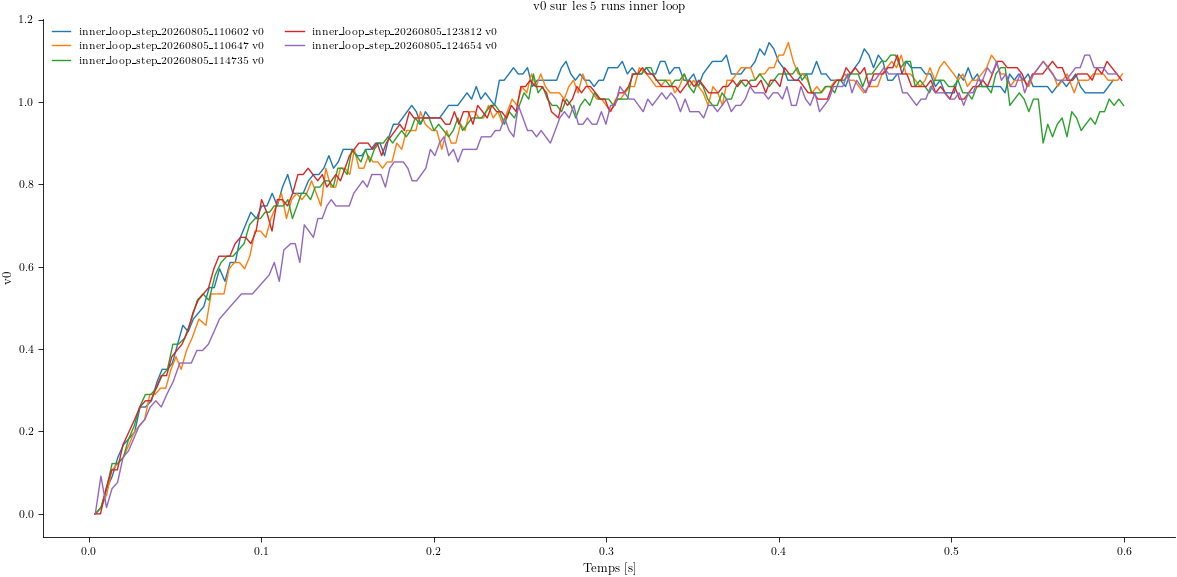

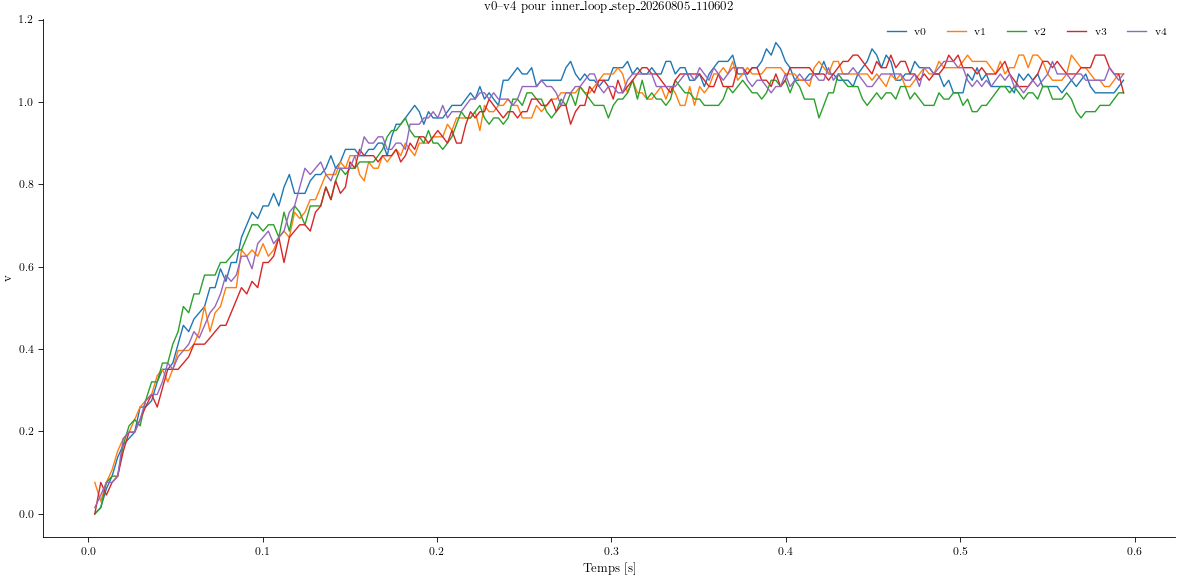

In [40]:
# Choisir quels runs afficher (ici tous)
runs = inner_loop_index

# 1. Tracer v0..v4 pour chaque run (fenêtré)
plt.figure(figsize=(12, 6))
for i, run in enumerate(runs):
    t = run["t0"]
    v0 = run["v0"]
    plt.plot(t, v0, label=f'{run["label"]} v0')
plt.xlabel("Temps [s]")
plt.ylabel("v0")
plt.title("v0 sur les 5 runs inner loop")
plt.legend(ncol=2, fontsize="small")
plt.tight_layout()
plt.show()

# 2. Superposer v0..v4 pour un seul run (ex: le premier)
run0 = runs[0]
t = run0["t0"]

plt.figure(figsize=(12, 6))
for k in range(5):
    vk = run0[f"v{k}"]
    plt.plot(t, vk, label=f'v{k}')
plt.xlabel("Temps [s]")
plt.ylabel("v")
plt.title(f"v0–v4 pour {run0['label']}")
plt.legend(ncol=5, fontsize="small")
plt.tight_layout()
plt.show()


In [41]:
def step_metrics(t, y, y0=None, y1=None):
    """
    Calcule des métriques de réponse indicielle sur un signal y(t).
    Retourne un dict avec t10, t90, t_rise, overshoot, t_settle_5pct, etc.
    """
    y = np.asarray(y, float)
    t = np.asarray(t, float)
    assert y.shape == t.shape

    if y0 is None:
        n0 = max(1, int(0.05 * len(y)))
        y0 = float(np.mean(y[:n0]))
    if y1 is None:
        n1 = max(1, int(0.05 * len(y)))
        y1 = float(np.mean(y[-n1:]))

    step = y1 - y0

    # Niveaux 10% et 90%
    y10 = y0 + 0.1 * step
    y90 = y0 + 0.9 * step

    # t10, t90
    if step > 0:
        idx10 = np.where(y >= y10)[0]
        idx90 = np.where(y >= y90)[0]
    else:
        idx10 = np.where(y <= y10)[0]
        idx90 = np.where(y <= y90)[0]

    t10 = float(t[idx10[0]]) if len(idx10) > 0 else np.nan
    t90 = float(t[idx90[0]]) if len(idx90) > 0 else np.nan
    t_rise = t90 - t10 if not (np.isnan(t10) or np.isnan(t90)) else np.nan

    # Pic et overshoot
    idx_peak = np.argmax(y) if step > 0 else np.argmin(y)
    y_peak = float(y[idx_peak])
    t_peak = float(t[idx_peak])
    overshoot_pct = 100.0 * (y_peak - y1) / step if step != 0 else 0.0

    # Settling à 5%
    band = 0.05 * abs(step)
    within = np.abs(y - y1) <= band
    settle_idx = None
    for i in range(len(within)):
        if np.all(within[i:]):
            settle_idx = i
            break
    t_settle_5pct = float(t[settle_idx]) if settle_idx is not None else np.nan

    return {
        "y0": y0,
        "y1": y1,
        "step": step,
        "t10": t10,
        "t90": t90,
        "t_rise": t_rise,
        "t_peak": t_peak,
        "y_peak": y_peak,
        "overshoot_pct": overshoot_pct,
        "t_settle_5pct": t_settle_5pct,
    }

# Appliquer à v0 (et éventuellement v1..v4) pour chaque run
metrics_list = []

for run in inner_loop_index:
    t = run["t0"]
    v0 = run["v0"]

    m = step_metrics(t, v0)
    m["label"] = run["label"]
    m["meta"] = run["meta"]
    metrics_list.append(m)

# Affichage sous forme de tableau
print(f"{'run':<40} {'t10':>7} {'t90':>7} {'t_rise':>8} {'overshoot%':>10} {'t_settle':>8}")
for m in metrics_list:
    print(
        f"{m['label']:<40} "
        f"{m['t10']:>7.3f} {m['t90']:>7.3f} {m['t_rise']:>8.3f} "
        f"{m['overshoot_pct']:>10.1f} {m['t_settle_5pct']:>8.3f}"
    )


run                                          t10     t90   t_rise overshoot% t_settle
inner_loop_step_20260805_110602            0.030   0.182    0.152       12.1    0.512
inner_loop_step_20260805_110647            0.032   0.192    0.160        9.1    0.526
inner_loop_step_20260805_114735            0.030   0.168    0.139       16.8    0.578
inner_loop_step_20260805_123812            0.030   0.225    0.196        4.6    0.513
inner_loop_step_20260805_124654            0.029   0.249    0.220        3.0    0.545


In [42]:
tune_files = sorted(NPZ_FOLDER.glob("tune*.npz"))
print(f"Fichiers Tune trouvés : {len(tune_files)}")

# --- Inspection des clés meta (si présentes) ---
meta_keys = defaultdict(int)
for npz_path in tune_files:
    data = np.load(npz_path, allow_pickle=True)
    if "meta" in data.files:
        meta_obj = data["meta"]
        if meta_obj.ndim == 0:
            meta_obj = meta_obj.item()
        if isinstance(meta_obj, (dict, str)):
            if isinstance(meta_obj, str):
                meta_dict = json.loads(meta_obj)
            else:
                meta_dict = meta_obj
            for k in meta_dict:
                meta_keys[k] += 1

if meta_keys:
    print(f"\nClés meta (occurrence / {len(tune_files)}) :")
    for k in sorted(meta_keys):
        print(f"  {k:<28} {meta_keys[k]}")
else:
    print("\nPas de champ 'meta' trouvé dans les fichiers tune.")

# --- En-tête du tableau d'inspection ---
print("\n" + "=" * 110)
print("INSPECTION DES DONNÉES TUNE")
print("=" * 110)
print(
    f"{'fichier':<46} {'N':>5} {'durée':>7} {'dt_méd':>7} "
    f"{'wn':>6} {'zeta':>6} {'amp':>6} {'|iq|max':>8}"
)

tune_index = []

for npz_path in tune_files:
    data = np.load(npz_path, allow_pickle=True)

    # Récupérer wn, zeta, amp depuis les champs du NPZ
    wn   = float(data["wn"])   if "wn"   in data.files else np.nan
    zeta = float(data["zeta"]) if "zeta" in data.files else np.nan
    amp  = float(data["amp"])  if "amp"  in data.files else np.nan

    t0 = np.asarray(data["t0"], float)
    v0 = np.asarray(data["v0"], float)
    iq0 = np.asarray(data["iq0"], float) if "iq0" in data.files else np.array([])
    iq1 = np.asarray(data["iq1"], float) if "iq1" in data.files else np.array([])
    iq2 = np.asarray(data["iq2"], float) if "iq2" in data.files else np.array([])

    n = len(t0)
    if n < 2:
        print(f"{npz_path.name:<46} {n:>5}   run avorté, ignoré")
        continue

    dt_med = float(np.median(np.diff(t0)))

    # iq max (sur iq0..iq2 si présents)
    iq_arrays = [x for x in (iq0, iq1, iq2) if x.size > 0]
    if iq_arrays:
        iq_all = np.concatenate(iq_arrays)
        iq_max = float(np.max(np.abs(iq_all)))
    else:
        iq_max = np.nan

    entry = {
        "file": npz_path,
        "label": npz_path.stem,
        "wn": wn,
        "zeta": zeta,
        "amp": amp,
        "N": n,
        "dur": float(t0[-1] - t0[0]),
        "dt_med": dt_med,
        "fs": 1.0 / dt_med if dt_med > 0 else np.nan,
        "iq_max": iq_max,
        "t0": t0,
        "v0": v0,
        "iq0": iq0,
        "iq1": iq1,
        "iq2": iq2,
        # autres champs si besoin
        "J": float(data["J"]) if "J" in data.files else np.nan,
        "ki": float(data["ki"]) if "ki" in data.files else np.nan,
        "kp": float(data["kp"]) if "kp" in data.files else np.nan,
        "grid": data["grid"] if "grid" in data.files else None,
        "mesure": data["mesure"] if "mesure" in data.files else None,
        "modele": data["modele"] if "modele" in data.files else None,
        "saturated": bool(data["saturated"].item()) if "saturated" in data.files else False,
    }
    tune_index.append(entry)

    print(
        f"{npz_path.name:<46} {n:>5} {entry['dur']:>6.3f}s {dt_med*1e3:>6.1f}ms "
        f"{wn:>6.2f} {zeta:>6.2f} {amp:>6.2f} {iq_max:>8.2f}"
    )

print("\n" + "=" * 110)
print(f"{len(tune_index)} run(s) exploitable(s) sur {len(tune_files)}")
print("=" * 110)


Fichiers Tune trouvés : 9

Pas de champ 'meta' trouvé dans les fichiers tune.

INSPECTION DES DONNÉES TUNE
fichier                                            N   durée  dt_méd     wn   zeta    amp  |iq|max
tune_wn15_z1.5_20260806_104309.npz              4096  0.512s    0.1ms  15.00   1.50   0.22     6.43
tune_wn15_z1.5_20260806_104438.npz              4096  0.512s    0.1ms  15.00   1.50   0.22     6.07
tune_wn15_z1.5_20260806_104654.npz              4096  0.512s    0.1ms  15.00   1.50   0.22     5.35
tune_wn15_z1.5_20260806_105121.npz              4096  0.512s    0.1ms  15.00   1.50   0.22     5.07
tune_wn15_z1.5_20260806_110104.npz              4096  0.512s    0.1ms  15.00   1.50   0.22     5.15
tune_wn15_z1.5_20260806_111618.npz              4096  0.512s    0.1ms  15.00   1.50   0.43     9.64
tune_wn15_z2.5_20260806_110739.npz              4096  0.512s    0.1ms  15.00   2.50   0.13     5.81
tune_wn4.6_z1.15_20260806_103446.npz            4096  0.512s    0.1ms   4.60   1.15   1.00    

In [43]:
def step_metrics(t, y, y0=None, y1=None):
    """
    Calcule des métriques de réponse indicielle sur un signal y(t).
    """
    y = np.asarray(y, float)
    t = np.asarray(t, float)
    assert y.shape == t.shape

    if y0 is None:
        n0 = max(1, int(0.05 * len(y)))
        y0 = float(np.mean(y[:n0]))
    if y1 is None:
        n1 = max(1, int(0.05 * len(y)))
        y1 = float(np.mean(y[-n1:]))

    step = y1 - y0

    # Niveaux 10% et 90%
    y10 = y0 + 0.1 * step
    y90 = y0 + 0.9 * step

    # t10, t90
    if step > 0:
        idx10 = np.where(y >= y10)[0]
        idx90 = np.where(y >= y90)[0]
    else:
        idx10 = np.where(y <= y10)[0]
        idx90 = np.where(y <= y90)[0]

    t10 = float(t[idx10[0]]) if len(idx10) > 0 else np.nan
    t90 = float(t[idx90[0]]) if len(idx90) > 0 else np.nan
    t_rise = t90 - t10 if not (np.isnan(t10) or np.isnan(t90)) else np.nan

    # Pic et overshoot
    idx_peak = np.argmax(y) if step > 0 else np.argmin(y)
    y_peak = float(y[idx_peak])
    t_peak = float(t[idx_peak])
    overshoot_pct = 100.0 * (y_peak - y1) / step if step != 0 else 0.0

    # Settling à 5%
    band = 0.05 * abs(step)
    within = np.abs(y - y1) <= band
    settle_idx = None
    for i in range(len(within)):
        if np.all(within[i:]):
            settle_idx = i
            break
    t_settle_5pct = float(t[settle_idx]) if settle_idx is not None else np.nan

    return {
        "y0": y0,
        "y1": y1,
        "step": step,
        "t10": t10,
        "t90": t90,
        "t_rise": t_rise,
        "t_peak": t_peak,
        "y_peak": y_peak,
        "overshoot_pct": overshoot_pct,
        "t_settle_5pct": t_settle_5pct,
    }

# Appliquer à v0 pour chaque run tune
tune_metrics = []

for run in tune_index:
    t = run["t0"]
    v0 = run["v0"]

    m = step_metrics(t, v0)
    m["label"] = run["label"]
    m["wn"] = run["wn"]
    m["zeta"] = run["zeta"]
    m["amp"] = run["amp"]
    tune_metrics.append(m)

# Affichage sous forme de tableau
print(
    f"{'run':<42} {'wn':>5} {'zeta':>5} {'amp':>5} "
    f"{'t10':>7} {'t90':>7} {'t_rise':>8} {'overshoot%':>10} {'t_settle':>8}"
)
for m in tune_metrics:
    print(
        f"{m['label']:<42} "
        f"{m['wn']:>5.2f} {m['zeta']:>5.2f} {m['amp']:>5.2f} "
        f"{m['t10']:>7.3f} {m['t90']:>7.3f} {m['t_rise']:>8.3f} "
        f"{m['overshoot_pct']:>10.1f} {m['t_settle_5pct']:>8.3f}"
    )


run                                           wn  zeta   amp     t10     t90   t_rise overshoot% t_settle
tune_wn15_z1.5_20260806_104309             15.00  1.50  0.22   0.012   0.028    0.016       77.9      nan
tune_wn15_z1.5_20260806_104438             15.00  1.50  0.22   0.016   0.035    0.019        9.6      nan
tune_wn15_z1.5_20260806_104654             15.00  1.50  0.22   0.010   0.027    0.017       39.0    0.503
tune_wn15_z1.5_20260806_105121             15.00  1.50  0.22   0.008   0.041    0.033       46.8    0.502
tune_wn15_z1.5_20260806_110104             15.00  1.50  0.22   0.005   0.049    0.044       36.5    0.504
tune_wn15_z1.5_20260806_111618             15.00  1.50  0.43   0.003   0.004    0.001      106.4      nan
tune_wn15_z2.5_20260806_110739             15.00  2.50  0.13   0.007   0.025    0.018       60.3      nan
tune_wn4.6_z1.15_20260806_103446            4.60  1.15  1.00   0.020   0.163    0.142        6.3    0.362
tune_wn4.6_z1.15_20260806_104050            4.

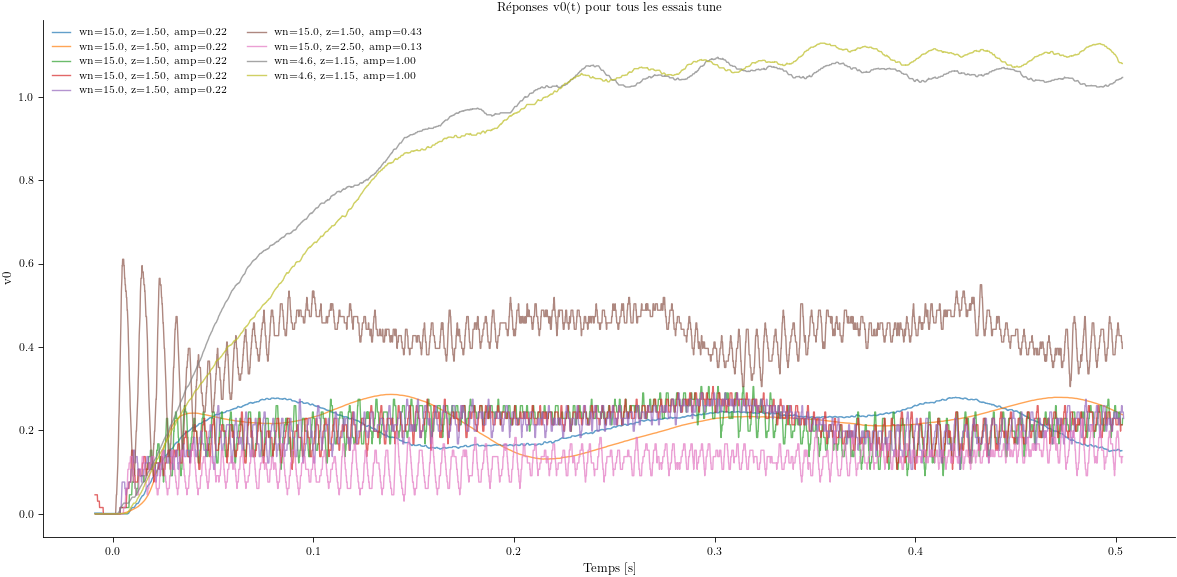

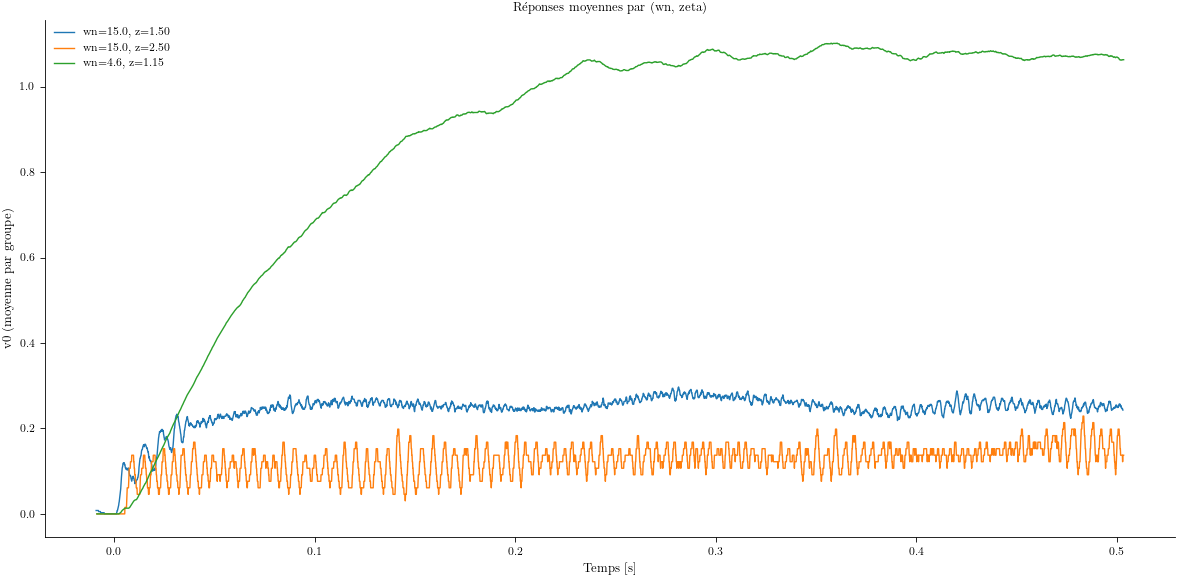

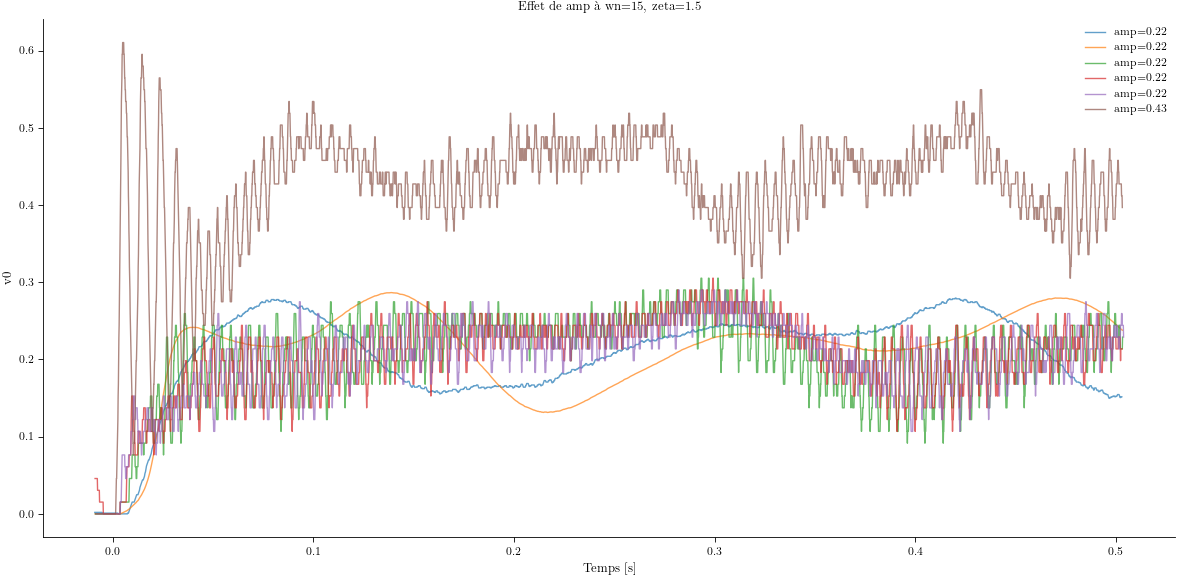

In [44]:
# 1. Superposer v0(t) pour tous les runs, coloré par (wn, zeta, amp)
plt.figure(figsize=(12, 6))
for run in tune_index:
    t = run["t0"]
    v0 = run["v0"]
    label = f"wn={run['wn']:.1f}, z={run['zeta']:.2f}, amp={run['amp']:.2f}"
    plt.plot(t, v0, label=label, alpha=0.7)

plt.xlabel("Temps [s]")
plt.ylabel("v0")
plt.title("Réponses v0(t) pour tous les essais tune")
plt.legend(ncol=2, fontsize="small")
plt.tight_layout()
plt.show()

# 2. Comparer les groupes (wn, zeta) en moyennant les runs de chaque groupe
groups = {}
for run in tune_index:
    key = (run["wn"], run["zeta"])
    groups.setdefault(key, []).append(run)

plt.figure(figsize=(12, 6))
for (wn, zeta), runs in groups.items():
    # Aligner sur le même axe temps (prendre la longueur minimale)
    t_min_len = min(r["t0"].size for r in runs)
    t_ref = runs[0]["t0"][:t_min_len]
    v_mean = np.mean(np.stack([r["v0"][:t_min_len] for r in runs], axis=1), axis=1)
    plt.plot(t_ref, v_mean, label=f"wn={wn:.1f}, z={zeta:.2f}")

plt.xlabel("Temps [s]")
plt.ylabel("v0 (moyenne par groupe)")
plt.title("Réponses moyennes par (wn, zeta)")
plt.legend()
plt.tight_layout()
plt.show()

# 3. Effet de amp à wn=15, zeta=1.5 fixe
plt.figure(figsize=(12, 6))
for run in tune_index:
    if np.isclose(run["wn"], 15.0) and np.isclose(run["zeta"], 1.5):
        t = run["t0"]
        v0 = run["v0"]
        plt.plot(t, v0, label=f"amp={run['amp']:.2f}", alpha=0.7)

plt.xlabel("Temps [s]")
plt.ylabel("v0")
plt.title("Effet de amp à wn=15, zeta=1.5")
plt.legend()
plt.tight_layout()
plt.show()


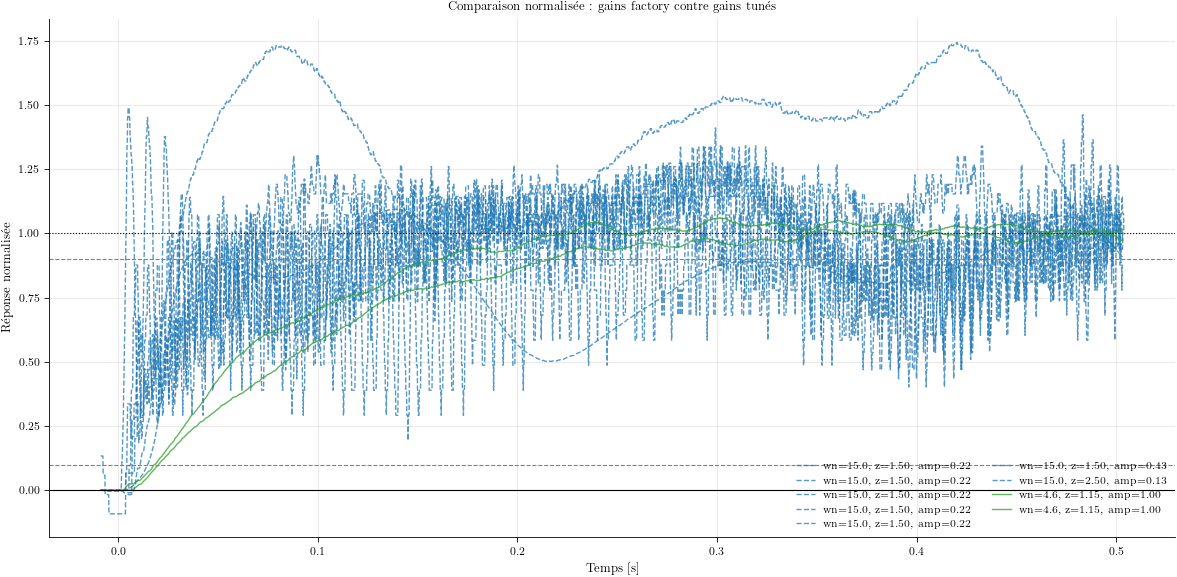

In [45]:
def normalize_response(t, y, n_initial=50, n_final=200):
    """
    Normalise y entre sa valeur initiale et sa valeur finale.
    """
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)

    n_initial = min(n_initial, len(y))
    n_final = min(n_final, len(y))

    y_initial = np.mean(y[:n_initial])
    y_final = np.mean(y[-n_final:])

    delta = y_final - y_initial

    if abs(delta) < 1e-12:
        return t, np.full_like(y, np.nan), y_initial, y_final

    y_norm = (y - y_initial) / delta
    return t, y_norm, y_initial, y_final

plt.figure(figsize=(12, 6))

for run in tune_index:
    t = run["t0"]
    y = run["v0"]

    t, y_norm, y_initial, y_final = normalize_response(t, y)

    if run["wn"] < 10:
        color = "tab:green"
        linestyle = "-"
        group = "Réglage lent / référence"
    else:
        color = "tab:blue"
        linestyle = "--"
        group = "Réglage tuné"

    label = (
        f"wn={run['wn']:.1f}, "
        f"z={run['zeta']:.2f}, "
        f"amp={run['amp']:.2f}"
    )

    plt.plot(
        t,
        y_norm,
        color=color,
        linestyle=linestyle,
        alpha=0.75,
        label=label
    )

plt.axhline(0.0, color="black", linewidth=0.8)
plt.axhline(1.0, color="black", linewidth=0.8, linestyle=":")

plt.axhline(0.1, color="gray", linewidth=0.8, linestyle="--")
plt.axhline(0.9, color="gray", linewidth=0.8, linestyle="--")

plt.xlabel("Temps [s]")
plt.ylabel("Réponse normalisée")
plt.title("Comparaison normalisée : gains factory contre gains tunés")
plt.grid(True, alpha=0.25)
plt.legend(ncol=2, fontsize="small")
plt.tight_layout()
plt.show()


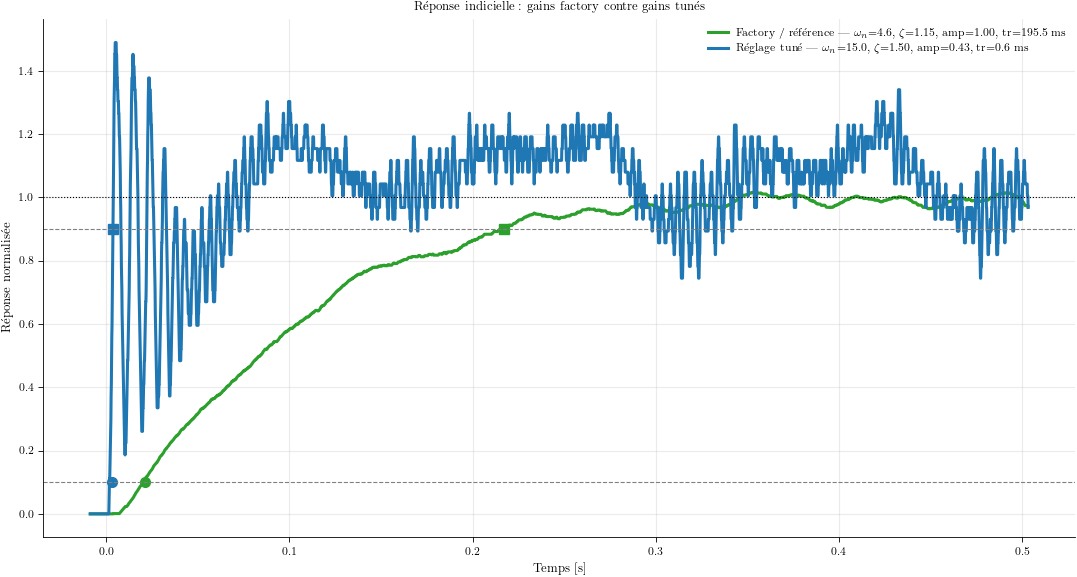

Référence :
  tune_wn4.6_z1.15_20260806_104050
  temps de montée : 195.5 ms

Réglage tuné :
  tune_wn15_z1.5_20260806_111618
  temps de montée : 0.6 ms

Accélération apparente : 312.80 fois


In [46]:
# Recherche des métriques correspondantes
run_by_label = {run["label"]: run for run in tune_index}

# Exclure les résultats manifestement non comparables
valid_metrics = [
    m for m in tune_metrics
    if np.isfinite(m["t_rise"])
]

reference_metrics = [
    m for m in valid_metrics
    if m["wn"] < 10
]

tuned_metrics = [
    m for m in valid_metrics
    if m["wn"] >= 10
]

reference = max(reference_metrics, key=lambda m: m["t_rise"])
tuned = min(tuned_metrics, key=lambda m: m["t_rise"])

run_reference = run_by_label[reference["label"]]
run_tuned = run_by_label[tuned["label"]]

plt.figure(figsize=(11, 6))

for run, metrics, label, color in [
    (
        run_reference,
        reference,
        "Factory / référence",
        "tab:green",
    ),
    (
        run_tuned,
        tuned,
        "Réglage tuné",
        "tab:blue",
    ),
]:
    result = normalize_response(
        run["t0"],
        run["v0"],
    )
    t, y_norm = result[:2]

    plt.plot(
        t,
        y_norm,
        linewidth=2.2,
        color=color,
        label=(
            f"{label} — "
            f"$\\omega_n$={run['wn']:.1f}, "
            f"$\\zeta$={run['zeta']:.2f}, "
            f"amp={run['amp']:.2f}, "
            f"tr={metrics['t_rise']*1e3:.1f} ms"
        ),
    )

    # Marqueurs t10 et t90
    for time_key, level, marker in [
        ("t10", 0.1, "o"),
        ("t90", 0.9, "s"),
    ]:
        time_value = metrics[time_key]
        if np.isfinite(time_value):
            plt.plot(
                time_value,
                level,
                marker=marker,
                color=color,
                markersize=7,
            )

plt.axhline(0.1, color="gray", linestyle="--", linewidth=0.8)
plt.axhline(0.9, color="gray", linestyle="--", linewidth=0.8)
plt.axhline(1.0, color="black", linestyle=":", linewidth=0.8)

plt.xlabel("Temps [s]")
plt.ylabel("Réponse normalisée")
plt.title("Réponse indicielle : gains factory contre gains tunés")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

print("Référence :")
print(f"  {reference['label']}")
print(f"  temps de montée : {reference['t_rise']*1e3:.1f} ms")

print("\nRéglage tuné :")
print(f"  {tuned['label']}")
print(f"  temps de montée : {tuned['t_rise']*1e3:.1f} ms")

gain_speedup = reference["t_rise"] / tuned["t_rise"]
print(f"\nAccélération apparente : {gain_speedup:.2f} fois")


In [47]:
# Lier les métriques aux signaux
run_by_label = {run["label"]: run for run in tune_index}

# Paramètres de qualité à ajuster
MAX_OVERSHOOT = 100.0      # %
REQUIRE_SETTLING = True
EXCLUDE_SATURATED = True

candidates = []

for m in tune_metrics:
    run = run_by_label[m["label"]]

    valid_rise = np.isfinite(m["t_rise"]) and m["t_rise"] > 0
    valid_settle = np.isfinite(m["t_settle_5pct"])
    low_overshoot = m["overshoot_pct"] <= MAX_OVERSHOOT
    not_saturated = not run["saturated"]

    is_valid = valid_rise and low_overshoot

    if REQUIRE_SETTLING:
        is_valid = is_valid and valid_settle

    if EXCLUDE_SATURATED:
        is_valid = is_valid and not_saturated

    if is_valid:
        candidates.append(m)

if not candidates:
    print("Aucun essai ne respecte les critères actuels.")
    print("Essaie d'augmenter MAX_OVERSHOOT ou de désactiver REQUIRE_SETTLING.")
else:
    best_tuned = min(candidates, key=lambda m: m["t_rise"])

    print("Essais acceptés :")
    for m in sorted(candidates, key=lambda m: m["t_rise"]):
        print(
            f"{m['label']:<42} "
            f"tr={m['t_rise']*1e3:6.1f} ms | "
            f"OS={m['overshoot_pct']:5.1f} % | "
            f"ts={m['t_settle_5pct']*1e3:6.1f} ms"
        )

    print("\nMeilleur compromis retenu :")
    print(best_tuned["label"])


Essais acceptés :
tune_wn15_z1.5_20260806_104654             tr=  17.1 ms | OS= 39.0 % | ts= 503.4 ms
tune_wn15_z1.5_20260806_105121             tr=  32.5 ms | OS= 46.8 % | ts= 502.5 ms
tune_wn15_z1.5_20260806_110104             tr=  43.9 ms | OS= 36.5 % | ts= 503.9 ms
tune_wn4.6_z1.15_20260806_103446           tr= 142.1 ms | OS=  6.3 % | ts= 361.6 ms
tune_wn4.6_z1.15_20260806_104050           tr= 195.5 ms | OS=  1.6 % | ts= 282.5 ms

Meilleur compromis retenu :
tune_wn15_z1.5_20260806_104654


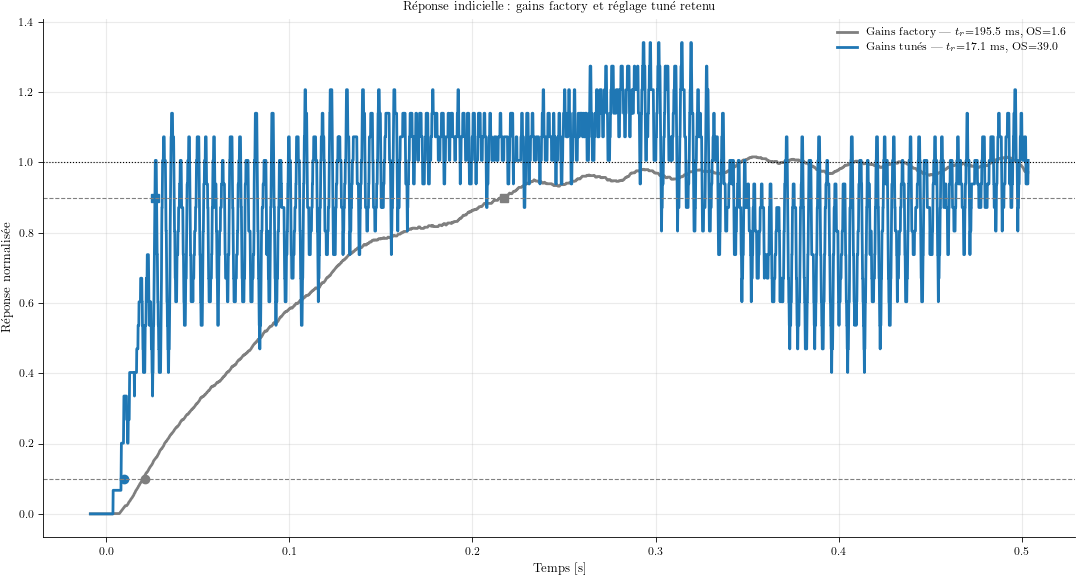

In [48]:
def normalize_response(t, y, n_initial=50, n_final=200):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)

    y0 = np.mean(y[:n_initial])
    yf = np.mean(y[-n_final:])
    delta = yf - y0

    if np.isclose(delta, 0.0):
        return t, np.full_like(y, np.nan)

    return t, (y - y0) / delta

# Référence : choisir le run factory le plus amorti
factory_candidates = [
    m for m in tune_metrics
    if np.isclose(m["wn"], 4.6)
    and np.isclose(m["zeta"], 1.15)
    and np.isfinite(m["t_settle_5pct"])
]

factory = min(factory_candidates, key=lambda m: m["overshoot_pct"])

# Run tuné : celui sélectionné avec les contraintes
tuned = best_tuned

factory_run = run_by_label[factory["label"]]
tuned_run = run_by_label[tuned["label"]]

plt.figure(figsize=(11, 6))

for run, m, name, color in [
    (factory_run, factory, "Gains factory", "tab:gray"),
    (tuned_run, tuned, "Gains tunés", "tab:blue"),
]:
    t, y_norm = normalize_response(run["t0"], run["v0"])

    plt.plot(
        t,
        y_norm,
        linewidth=2,
        color=color,
        label=(
            f"{name} — "
            f"$t_r$={m['t_rise']*1e3:.1f} ms, "
            f"OS={m['overshoot_pct']:.1f}%"
        ),
    )

    if np.isfinite(m["t10"]):
        plt.plot(m["t10"], 0.1, "o", color=color)

    if np.isfinite(m["t90"]):
        plt.plot(m["t90"], 0.9, "s", color=color)

plt.axhline(0.1, color="gray", linestyle="--", linewidth=0.8)
plt.axhline(0.9, color="gray", linestyle="--", linewidth=0.8)
plt.axhline(1.0, color="black", linestyle=":", linewidth=0.8)

plt.xlabel("Temps [s]")
plt.ylabel("Réponse normalisée")
plt.title("Réponse indicielle : gains factory et réglage tuné retenu")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


In [49]:
def smooth_signal(t, y, window_ms=7.0, polyorder=3):
    """
    Lissage Savitzky-Golay.

    window_ms : largeur de fenêtre en millisecondes.
    polyorder : ordre du polynôme local.
    """
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)

    dt = np.median(np.diff(t))
    window_length = int(np.round((window_ms * 1e-3) / dt))

    # savgol_filter exige une fenêtre impaire
    window_length = max(window_length, polyorder + 2)
    if window_length % 2 == 0:
        window_length += 1

    # La fenêtre doit rester strictement inférieure à la longueur du signal
    if window_length >= len(y):
        window_length = len(y) - 1
        if window_length % 2 == 0:
            window_length -= 1

    if window_length <= polyorder:
        return y.copy()

    return savgol_filter(
        y,
        window_length=window_length,
        polyorder=polyorder,
        mode="interp",
    )


In [50]:
tune_metrics = []

for run in tune_index:
    t = run["t0"]
    v0_raw = run["v0"]

    # Signal lissé, utilisé pour les métriques
    v0_smooth = smooth_signal(
        t,
        v0_raw,
        window_ms=12.0,
        polyorder=3,
    )

    m = step_metrics(t, v0_smooth)

    m["label"] = run["label"]
    m["wn"] = run["wn"]
    m["zeta"] = run["zeta"]
    m["amp"] = run["amp"]

    # Conserver brut et filtré pour les plots
    run["v0_raw"] = v0_raw
    run["v0_smooth"] = v0_smooth

    tune_metrics.append(m)


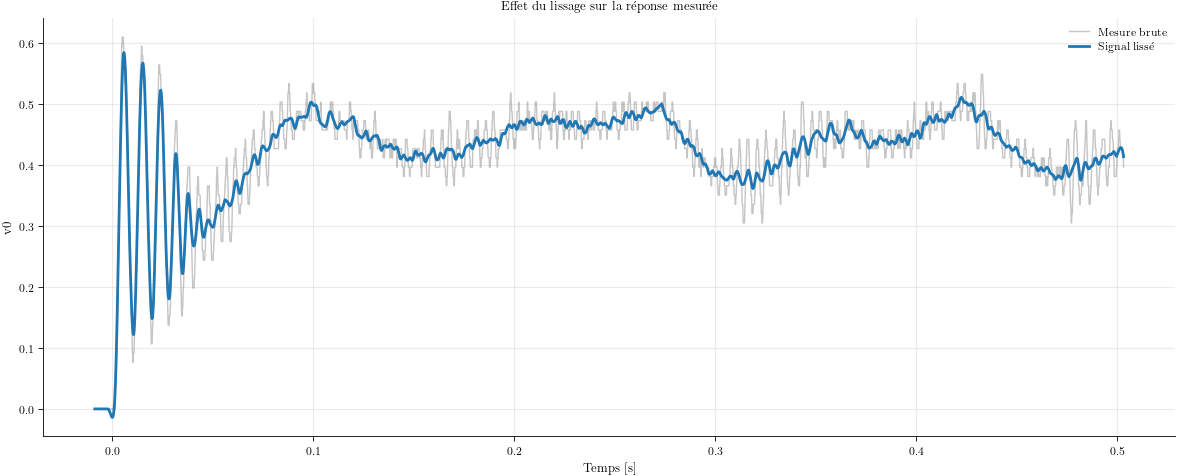

In [51]:
run = next(
    r for r in tune_index
    if r["label"] == "tune_wn15_z1.5_20260806_111618"
)

t = run["t0"]
v_raw = run["v0"]
v_smooth = smooth_signal(t, v_raw, window_ms=7.0, polyorder=3)

plt.figure(figsize=(12, 5))
plt.plot(t, v_raw, color="tab:gray", alpha=0.45, linewidth=1, label="Mesure brute")
plt.plot(t, v_smooth, color="tab:blue", linewidth=2, label="Signal lissé")

plt.xlabel("Temps [s]")
plt.ylabel("v0")
plt.title("Effet du lissage sur la réponse mesurée")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


In [52]:
def residual_ripple_pct(t, y, final_fraction=0.20):
    """
    Écart crête-à-crête sur les derniers échantillons,
    exprimé en % de la variation totale du step.
    """
    y = np.asarray(y, float)

    n_tail = max(10, int(final_fraction * len(y)))
    y_tail = y[-n_tail:]

    y_initial = np.mean(y[:n_tail])
    y_final = np.mean(y_tail)
    step_amp = abs(y_final - y_initial)

    if step_amp < 1e-12:
        return np.nan

    ripple_pp = np.ptp(y_tail)
    return 100.0 * ripple_pp / step_amp


  -> figures\rapport\InnerLoop\step_comparison.png


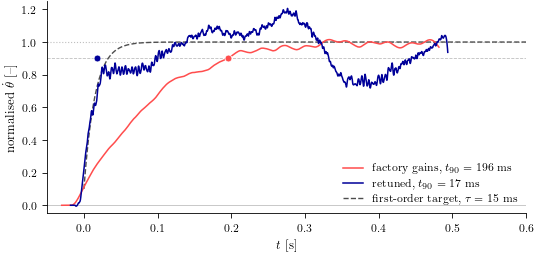

  factory   t_r = 195.5 ms, OS =   1.6 %, t_s =  282.5 ms
  retuned   t_r =  17.1 ms, OS =  39.0 %, t_s =  503.4 ms


In [53]:
# =============================================================================
#  Boucle interne - Reponse indicielle, gains d'usine contre gains retenus
#  La cible du premier ordre est celle que le reglage vise : c'est elle qui
#  justifie la reduction employee dans les lois de commande.
# =============================================================================

TAU_TARGET = 15.0e-3     # constante de temps visee [s], voir sec: inner loop
T_WIN_A4   = 0.60        # fenetre affichee depuis le front [s]

def _step_trace(run, m):
    """Reponse normalisee, temps rapporte au franchissement de 10 %."""
    t = np.asarray(run["t0"], float)
    y = np.asarray(run["v0_smooth"], float)
    y0 = np.mean(y[:50])
    yf = np.mean(y[-200:])
    y = (y - y0) / (yf - y0)
    t = t - m["t10"]
    keep = (t >= -0.05) & (t <= T_WIN_A4)
    return t[keep], y[keep]

fig, ax = new_fig(15.7, 7.0)
ax.axhline(0, color=C_GREYL, lw=0.6, zorder=1)
ax.axhline(1, color=C_GREYL, lw=0.8, ls=":", zorder=1)

for run, m, col, lab in ((factory_run, factory, C_RED,  "factory gains"),
                         (tuned_run,   tuned,   C_BLUE, "retuned")):
    t, y = _step_trace(run, m)
    ax.plot(t, y, color=col, lw=1.1, zorder=3,
            label=f"{lab}, $t_{{90}} = {(m['t90'] - m['t10']) * 1e3:.0f}$ ms")
    # Marqueur du franchissement de 90 %, dont l'ecart porte la comparaison
    ax.plot(m["t90"] - m["t10"], 0.9, "o", ms=5, color=col,
            mec="white", mew=0.6, zorder=5)

# Cible du premier ordre, decalee pour franchir 10 % a l'origine comme les mesures
t_ref = np.linspace(0, T_WIN_A4, 400)
ax.plot(t_ref, 1 - np.exp(-(t_ref + TAU_TARGET * np.log(1 / 0.9)) / TAU_TARGET),
        color=C_GREY, lw=1.0, ls="--", zorder=2,
        label=rf"first-order target, $\tau = {TAU_TARGET * 1e3:.0f}$ ms")

ax.axhline(0.9, color=C_GREYL, lw=0.6, ls="--", zorder=1)
ax.set_xlabel(r"$t$ [\si{\second}]")
ax.set_ylabel(r"normalised $\dot\theta$ [--]")
ax.set_xlim(-0.05, T_WIN_A4)
ax.set_ylim(-0.05, 1.25)
ax.legend(loc="lower right", frameon=False)

save(fig, "InnerLoop", "step_comparison")
plt.show()

for m, lab in ((factory, "factory"), (tuned, "retuned")):
    print(f"  {lab:<9} t_r = {m['t_rise'] * 1e3:5.1f} ms, "
          f"OS = {m['overshoot_pct']:5.1f} %, "
          f"t_s = {m['t_settle_5pct'] * 1e3:6.1f} ms")


## 4. Control tasks

In [54]:
# Shared plotting for the four control tasks.
# All four show the same three things, so they share one figure builder: psi
# against time (bench and simulation), the command below it, and the path the
# ball took through the two hoops on the right.

# Hoop geometry, in metres.
OUTER_R_OUT = 117.5e-3
OUTER_R_IN  = 112.5e-3
INNER_R_OUT =  55.5e-3
INNER_R_IN  =  44.5e-3
HOLE_CENTRE = np.pi
HOLE_WIDTH  = np.pi / 2


def _map2plot(x, y):
    """Model frame to plot frame: model x points down, so plot y against -x."""
    return y, -x


def _draw_hoops(ax, theta0=0.0):
    """The two hoops in millimetres, the inner one interrupted by its gap."""
    th = np.linspace(0, 2 * np.pi, 400)
    S = 1e3

    def _mm(x, y):
        xp, yp = _map2plot(x, y)
        return xp * S, yp * S

    xo, yo = _mm(OUTER_R_OUT * np.cos(th + theta0), OUTER_R_OUT * np.sin(th + theta0))
    xi, yi = _mm(OUTER_R_IN * np.cos(th + theta0), OUTER_R_IN * np.sin(th + theta0))
    ax.fill(np.r_[xo, xi[::-1]], np.r_[yo, yi[::-1]], color=C_GREYL, alpha=0.55, lw=0, zorder=1)
    for x, y in ((xo, yo), (xi, yi)):
        ax.plot(x, y, color=C_GREY, lw=0.7, zorder=2)

    h0 = HOLE_CENTRE - HOLE_WIDTH / 2
    h1 = HOLE_CENTRE + HOLE_WIDTH / 2
    for m in (th < h0, th > h1):
        if not m.any():
            continue
        xo, yo = _mm(INNER_R_OUT * np.cos(th[m] + theta0), INNER_R_OUT * np.sin(th[m] + theta0))
        xi, yi = _mm(INNER_R_IN * np.cos(th[m] + theta0), INNER_R_IN * np.sin(th[m] + theta0))
        ax.fill(np.r_[xo, xi[::-1]], np.r_[yo, yi[::-1]], color=C_GREYL, alpha=0.55, lw=0, zorder=1)
        for x, y in ((xo, yo), (xi, yi)):
            ax.plot(x, y, color=C_GREY, lw=0.7, zorder=2)

    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)


def ball_path(psi, r):
    """Ball centre path in the plot frame, in millimetres."""
    psi = np.asarray(psi, float)
    r = np.broadcast_to(np.asarray(r, float), psi.shape)
    x, y = _map2plot(r * np.cos(psi), r * np.sin(psi))
    return x * 1e3, y * 1e3


def draw_path(ax, psi, col, r=None, ls="-", lw=1.4, events=None, start=True, r_default=91.6e-3):
    """Chemin de la bille, trace dans un axes existant."""
    r = r_default if r is None else r
    r = np.broadcast_to(np.asarray(r, float), np.shape(psi))
    x, y = _map2plot(r * np.cos(psi), r * np.sin(psi))
    x, y = x * 1e3, y * 1e3
    ax.plot(x, y, color=col, lw=lw, ls=ls, zorder=4)
    if start:
        ax.plot(x[0], y[0], "o", ms=6, mfc="none", mec=col, mew=1.4, zorder=5)
    if events is not None and len(events):
        xe, ye = _map2plot(events[:, 0] * np.cos(events[:, 1]),
                           events[:, 0] * np.sin(events[:, 1]))
        ax.plot(xe * 1e3, ye * 1e3, "o", ms=6, mfc="none",
                mec=C_RED, mew=1.4, zorder=6)

def plot_task_figure(curves, name, subdir="T3", u_max=None, n_panel=None, theta0=0.0,
                     t_max=None):
    """Figure a trois panneaux pour une manoeuvre de looping.

    curves  : liste de dicts (t, psi, u, col, ls, label, r, events)
    n_panel : (t, N) trace en troisieme panneau a gauche, ou None
    u_max   : borne actionneur, tracee en pointilles
    t_max   : instant de coupure [s]. La troncature porte aussi sur le
              chemin de droite, pour que les deux colonnes montrent la
              meme portion de manoeuvre.
    """
    if t_max is not None:
        cut = []
        for c in curves:
            m = c['t'] <= t_max
            d = dict(c)
            d['t']   = c['t'][m]
            d['psi'] = c['psi'][m]
            if c.get('u') is not None:
                d['u'] = c['u'][m]
            if c.get('r') is not None:
                r = np.asarray(c['r'], float)
                d['r'] = r[m] if r.ndim else r
            cut.append(d)
        curves = cut
        if n_panel is not None:
            mn = n_panel[0] <= t_max
            n_panel = (n_panel[0][mn], n_panel[1][mn])

    n_left = 3 if n_panel is not None else 2
    fig = plt.figure(figsize=(15.7 * CM, (4.0 * n_left + 1.0) * CM))
    gs = fig.add_gridspec(n_left, 2, width_ratios=[1.55, 1],
                          hspace=0.15, wspace=0.05)

    axes = [fig.add_subplot(gs[i, 0]) for i in range(n_left)]
    ax_p = fig.add_subplot(gs[:, 1])

    # --- Angle de la bille ---
    ax = axes[0]
    ax.axhline(180, color=C_GREYL, lw=0.8, ls=":", zorder=1)
    ax.axhline(360, color=C_GREYL, lw=0.8, ls=":", zorder=1)
    for c in curves:
        ax.plot(c['t'], np.degrees(c['psi']), color=c['col'], lw=1.2,
                ls=c.get('ls', '-'), zorder=3, label=c.get('label'))
    ax.set_ylabel(r"$\psi$ [\si{\degree}]")
    ax.set_xticklabels([])
    if any(c.get('label') for c in curves):
        ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.01),
                  ncol=len(curves), frameon=False)

    # --- Commande ---
    ax = axes[1]
    ax.axhline(0, color=C_GREYL, lw=0.6, zorder=1)
    if u_max:
        for s in (+1, -1):
            ax.axhline(s * u_max, color=C_GREYL, lw=0.8, ls="--", zorder=1)
    for c in curves:
        if c.get('u') is None:
            continue
        ax.plot(c['t'], c['u'], color=C_GREEN, lw=1.1,
                ls=c.get('ls', '-'), zorder=3)
    ax.set_ylabel(r"$u$ [\si{\radian\per\second\squared}]")
    if n_left == 2:
        ax.set_xlabel(r"$t$ [\si{\second}]")
    else:
        ax.set_xticklabels([])

    t_end = max(c['t'][-1] for c in curves)
    for ax in axes:
        ax.set_xlim(0, t_end)

    # --- Chemin dans le plan des cerceaux ---
    _draw_hoops(ax_p, theta0)
    for c in curves:
        draw_path(ax_p, c['psi'], c['col'], r=c.get('r'),
                  ls=c.get('ls', '-'), events=c.get('events'),
                  start=c is curves[-1])

    save(fig, subdir, name)
    plt.show()
    return fig


### 4.1 T1 — stabilisation at the bottom

figures/T1/essais/psi10_173812.png


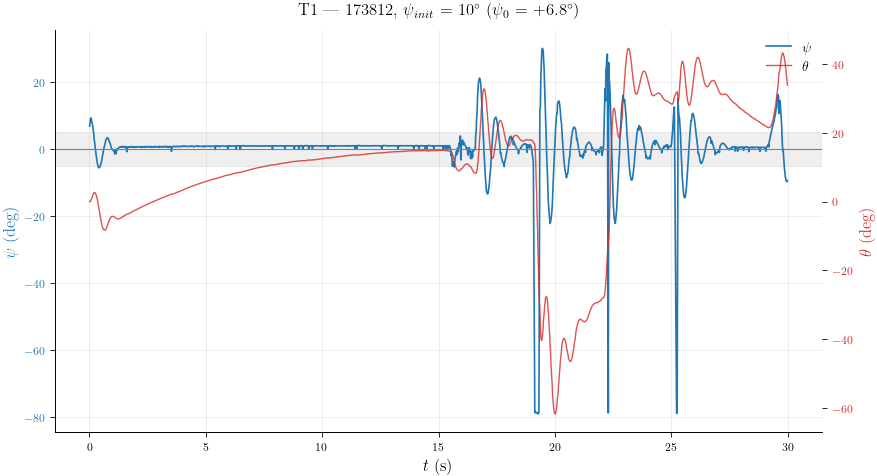

figures/T1/essais/psi10_173933.png


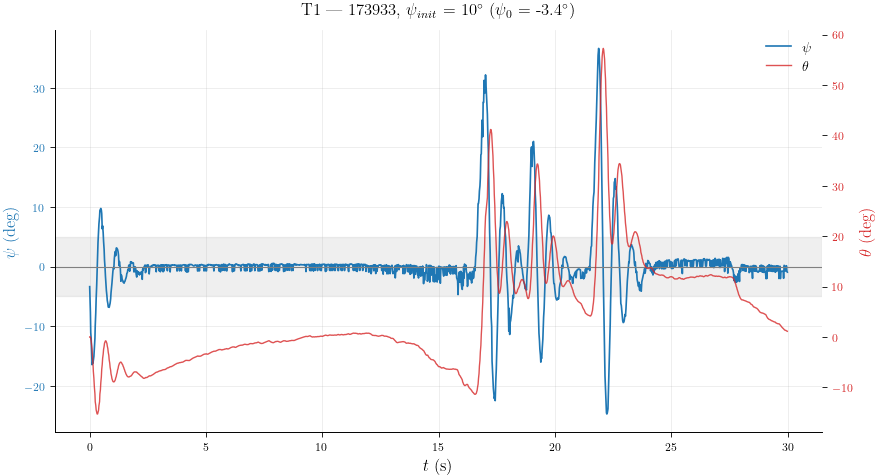

figures/T1/essais/psi10_174046.png


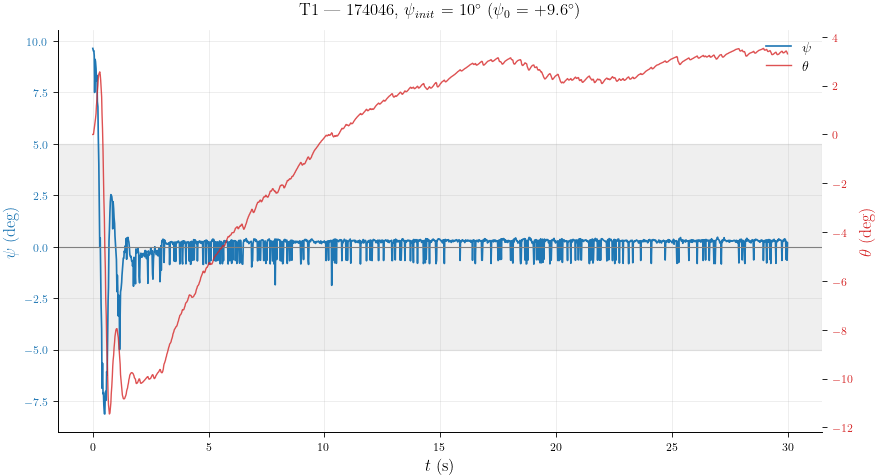

figures/T1/essais/psi45_174812.png


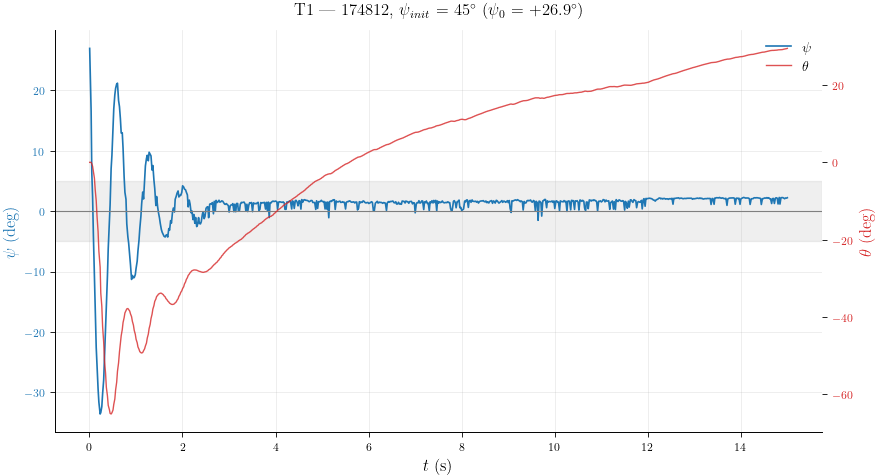

figures/T1/essais/psi45_174940.png


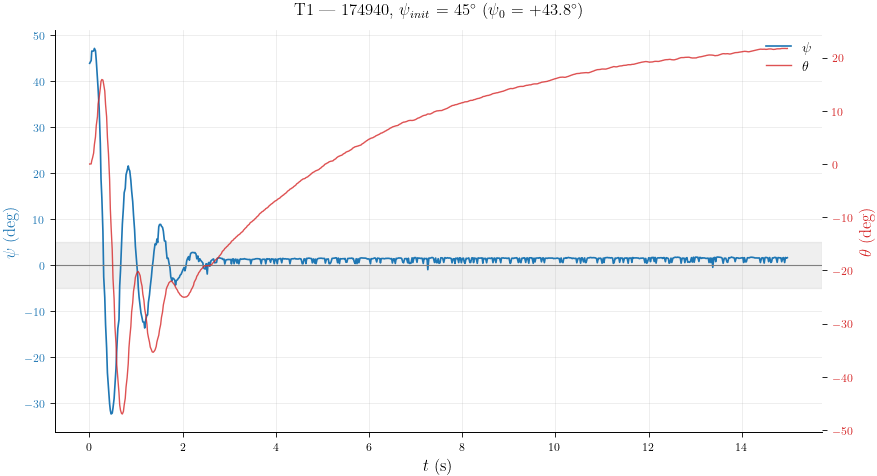

figures/T1/essais/psi45_175036.png


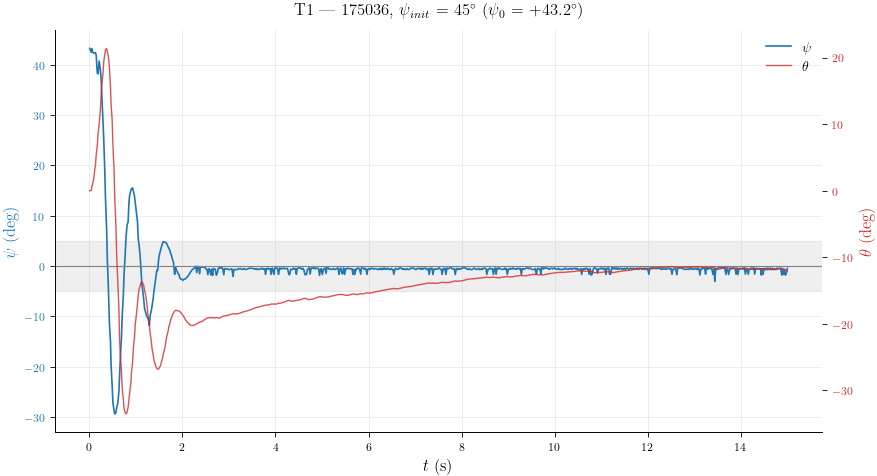

figures/T1/essais/psi60_175141.png


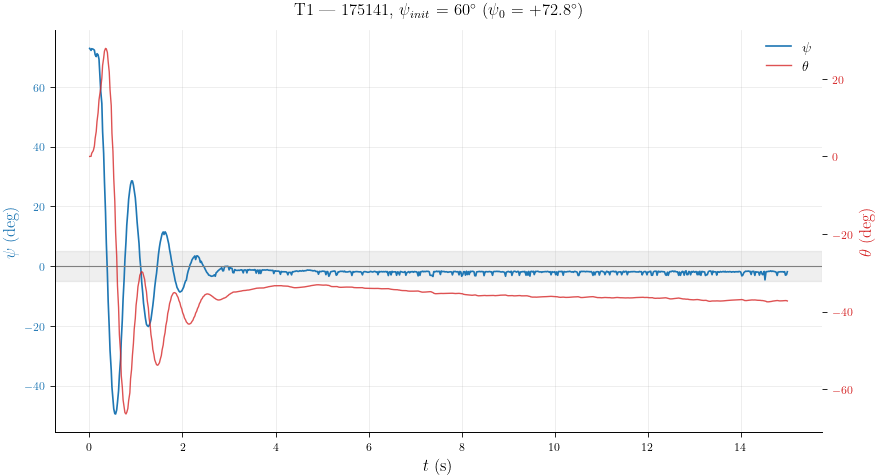

figures/T1/essais/psi60_175257.png


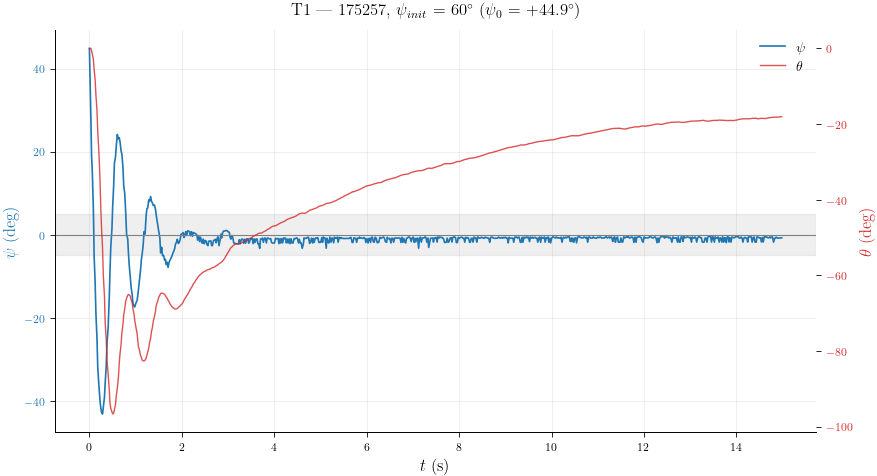

figures/T1/essais/psi60_175456.png


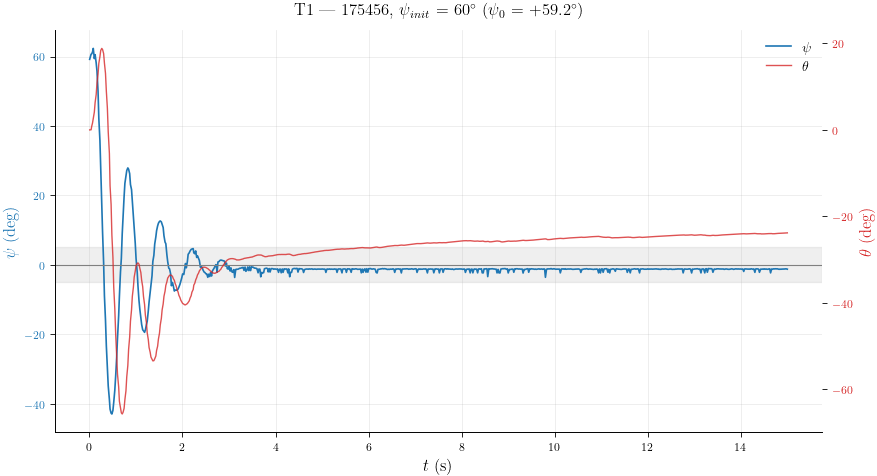

In [55]:
Path("figures/T1/essais").mkdir(parents=True, exist_ok=True)

runs_ok = [e for e in t1_groups[('B', 'post_usb')] if e['calib_ok']]
runs_ok = sorted(runs_ok, key=lambda e: (e['meta']['psi_init_deg'], e['label']))

for run in runs_ok:
    data  = np.load(run['file'], allow_pickle=True)
    t     = np.asarray(data['t'], float)
    psi   = np.degrees(np.asarray(data['psi'], float))
    theta = np.degrees(np.asarray(data['theta'], float))

    fig, ax = plt.subplots(figsize=(9, 5))

    l1, = ax.plot(t, psi, linewidth=1.2, color='tab:blue', label=r'$\psi$')
    ax.axhline(0, color='gray', linewidth=0.8)
    ax.axhspan(-5, 5, color='gray', alpha=0.12, zorder=0)
    ax.set_xlabel(r'$t$ (s)', fontsize=12)
    ax.set_ylabel(r'$\psi$ (deg)', fontsize=12, color='tab:blue')
    ax.tick_params(axis='y', labelcolor='tab:blue')
    ax.grid(True, alpha=0.3, linewidth=0.5)

    ax2 = ax.twinx()
    l2, = ax2.plot(t, theta, linewidth=1.0, color='tab:red',
                   alpha=0.8, label=r'$\theta$')
    ax2.set_ylabel(r'$\theta$ (deg)', fontsize=12, color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    ax.legend(handles=[l1, l2], loc='best', fontsize=10)
    ax.set_title(f"T1 — {run['label'][-6:]}, "
                 f"$\\psi_{{init}}$ = {run['meta']['psi_init_deg']:.0f}$^\\circ$ "
                 f"($\\psi_0$ = {psi[0]:+.1f}$^\\circ$)",
                 fontsize=12, pad=12)

    plt.tight_layout()
    fname = (f"figures/T1/essais/psi{run['meta']['psi_init_deg']:.0f}"
             f"_{run['label'][-6:]}.png")
    fig.savefig(fname, dpi=300, bbox_inches='tight')
    print(f"{fname}")
    plt.show()


In [56]:
# =============================================================================
#  T1 - Criteres d'exploitabilite
#  Un essai n'est retenu que si sa calibration d'offset est valide, s'il a
#  tourne a 50 Hz et si la bille n'a pas ete perdue en cours de route.
# =============================================================================
SAT_MAX_PCT = 5.0     # au-dela, la commande est ecretee trop souvent pour
                      # que la comparaison a une simulation non saturee ait
                      # un sens

def _usable(e):
    return (e.get('calib_ok', True)
            and e.get('fs_cls', '50Hz') == '50Hz'
            and e.get('stop_cls', '') != 'balle_perdue'
            and e.get('sat', 0.0) <= SAT_MAX_PCT)

print("Essais ecartes")
for e in t1_index:
    if _usable(e):
        continue
    why = []
    if not e.get('calib_ok', True):        why.append("offset")
    if e.get('fs_cls') != '50Hz':          why.append("36 Hz")
    if e.get('stop_cls') == 'balle_perdue': why.append("bille perdue")
    if e.get('sat', 0) > SAT_MAX_PCT:      why.append(f"sat {e['sat']:.1f}%")
    print(f"  {e['label'][-34:]:<38} {', '.join(why)}")

print(f"\n{sum(1 for e in t1_index if _usable(e))}/{len(t1_index)} exploitables")

# Un essai par cas (piste, excursion initiale) : le plus long des exploitables.
# Le rebroussement est l'instant ou la bille cesse de s'eloigner : c'est de la
# que la recuperation est chronometree, la simulation ne reproduisant pas le
# lacher qui precede.
SETTLE_FRAC = 0.05     # bande de stabilisation, 5 % de l'excursion initiale
T_SEARCH    = 3.0      # fenetre de recherche du rebroussement [s]

def _turning_point(e):
    """Instant, position, vitesse au rebroussement, et temps de stabilisation."""
    d   = np.load(e['file'], allow_pickle=True)
    t   = np.asarray(d['t'], float).squeeze()
    psi = np.asarray(d['psi'], float).squeeze()
    n   = min(t.size, psi.size)
    t, psi = t[:n] - t[0], psi[:n]

    win = t <= T_SEARCH
    i0  = int(np.argmax(np.abs(psi[win])))          # excursion maximale
    psid = np.gradient(psi, t)

    # Stabilisation : premier instant apres lequel l'ecart reste dans la bande
    band = SETTLE_FRAC * abs(psi[i0])
    ts = np.nan
    inside = np.abs(psi) <= band
    for k in range(i0, n):
        if np.all(inside[k:]):
            ts = t[k] - t[i0]
            break

    return dict(t0=float(t[i0]),
                psi0_deg=float(np.degrees(psi[i0])),
                psid0=float(psid[i0]),
                ts=float(ts))

T1_BEST = {}
for e in t1_index:
    if not _usable(e):
        continue
    m   = e['meta']
    key = (m.get('hoop', 'outer'),
           float(m.get('psi_init_deg', round(abs(np.degrees(e['psi0']))))))
    if key not in T1_BEST or e['dur'] > T1_BEST[key]['dur']:
        T1_BEST[key] = {**e, **_turning_point(e)}

print(f"\n{len(T1_BEST)} cas retenus")
for k in sorted(T1_BEST):
    b = T1_BEST[k]
    print(f"  {k}  t0 = {b['t0']:.2f} s, psi0 = {b['psi0_deg']:+.1f} deg, "
          f"ts = {b['ts']:.2f} s")


Essais ecartes

18/18 exploitables

6 cas retenus
  ('inner', 30.0)  t0 = 0.18 s, psi0 = +35.3 deg, ts = 2.06 s
  ('inner', 45.0)  t0 = 0.06 s, psi0 = +44.0 deg, ts = 2.12 s
  ('inner', 60.0)  t0 = 0.08 s, psi0 = +64.9 deg, ts = 2.70 s
  ('outer', 10.0)  t0 = 0.10 s, psi0 = -16.5 deg, ts = nan s
  ('outer', 45.0)  t0 = 0.00 s, psi0 = +43.2 deg, ts = 13.45 s
  ('outer', 60.0)  t0 = 0.00 s, psi0 = +72.8 deg, ts = 14.53 s


In [57]:
print("\nConditions initiales, prises au rebroussement")
print(f"{'piste':>6} {'cible':>6} {'psi0 [deg]':>11} {'psidot0 [deg/s]':>16} "
      f"{'t0 [s]':>8}  K")
for (hoop, target), e in sorted(T1_BEST.items()):
    print(f"{hoop:>6} {target:>5.0f}d {e['psi0_deg']:>+10.2f} "
          f"{np.degrees(e['psid0']):>+15.2f} {e['t0']:>8.3f}  "
          f"{np.array2string(e['K'], precision=4, suppress_small=True)}")



Conditions initiales, prises au rebroussement
 piste  cible  psi0 [deg]  psidot0 [deg/s]   t0 [s]  K
 inner    30d     +35.34          -21.53    0.182  [  1.    4.2 -22.   -6. ]
 inner    45d     +44.02          -12.59    0.061  [  1.    4.2 -22.   -6. ]
 inner    60d     +64.94           +4.58    0.080  [  1.    4.2 -22.   -6. ]
 outer    10d     -16.48          -34.31    0.102  [  1.    4.  -18.   -5.5]
 outer    45d     +43.24          -23.43    0.000  [  1.    4.  -18.   -5.5]
 outer    60d     +72.82          -22.49    0.000  [  1.    4.  -18.   -5.5]


T1 - comparaison simulation contre banc


  -> figures\rapport\T1\T1_outer_10deg.png


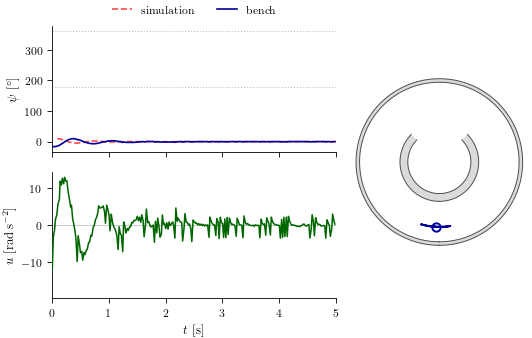

  outer 10 deg : 0_ref+00_B_t02_20260810_173933, psi0 = -16.5 deg, RMSE = 5.56 deg, ecart max = 26.48 deg


  -> figures\rapport\T1\T1_outer_45deg.png


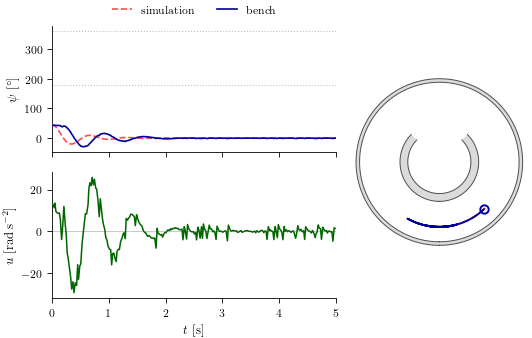

  outer 45 deg : 5_ref+00_B_t03_20260810_175036, psi0 = +43.2 deg, RMSE = 11.94 deg, ecart max = 49.44 deg


  -> figures\rapport\T1\T1_inner_45deg.png


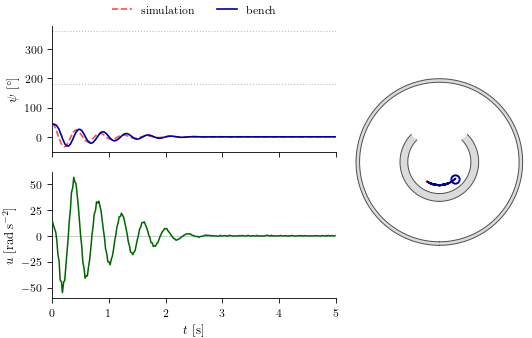

  inner 45 deg : 5_ref+00_B_t01_20260810_180206, psi0 = +44.0 deg, RMSE = 6.73 deg, ecart max = 30.48 deg


In [58]:
# =============================================================================
#  T1 - Comparaison simulation contre banc
#  Trois cas : deux amplitudes sur la piste exterieure, une sur l'interieure.
# =============================================================================

SIM_FILES = {
    ('outer', 10.0): "lqr_t1_recovery_from_10_deg_outer_hoop",
    ('outer', 45.0): "lqr_t1_recovery_from_45_deg_outer_hoop",
    ('inner', 45.0): "lqr_t1_recovery_from_45_deg_inner_hoop",
}

CASE_ORDER    = [('outer', 10.0), ('outer', 45.0), ('inner', 45.0)]
T_PLOT        = 5.0      # fenetre affichee [s]
SETTLE_BAND   = 2.0      # bande de stabilisation [deg]

PSI_IDX, THETA_IDX = 4, 2

T_PRE = 0      # portion affichee avant le rebroussement [s]

SIM_TIME_SHIFT = {
    ("outer", 10.0): 0.090,   # 20 ms vers la droite
}

def load_bench(e):
    """Trajectoire mesuree, temps rapporte au rebroussement.

    La portion anterieure est conservee et porte un temps negatif : elle
    montre le lacher, que la simulation ne reproduit pas puisqu'elle demarre
    a l'instant du rebroussement.
    """
    d = np.load(e['file'], allow_pickle=True)
    t   = np.asarray(d['t'], float).squeeze()
    psi = np.degrees(np.asarray(d['psi'], float).squeeze())
    u   = np.asarray(d['u'], float).squeeze()
    n = min(t.size, psi.size, u.size)
    return t[:n] - e['t0'], psi[:n], u[:n]

def load_sim(path):
    """Lit un .mat v7.3 contenant la structure `run` produite par MATLAB."""
    with h5py.File(path, "r") as f:
        run = f["run"]
        t = np.asarray(run["t_s"], float).squeeze()
        x = np.asarray(run["x"], float)
    if x.shape[1] == t.size:
        x = x.T
    n = min(t.size, x.shape[0])
    return dict(t=t[:n] - t[0],
                psi=np.degrees(x[:n, PSI_IDX]),
                theta=np.degrees(x[:n, THETA_IDX]))

# -----------------------------------------------------------------------
print("T1 - comparaison simulation contre banc")

for key in CASE_ORDER:
    hoop, target = key
    if key not in T1_BEST:
        print(f"  {key} : essai de banc absent")
        continue
    path = sim_run(SIM_FILES[key])
    if not path.exists():
        print(f"  {key} : simulation absente, {path.name}")
        continue

    e = T1_BEST[key]
    sim = load_sim(path)

    # Decalage temporel specifique de la simulation si necessaire.
    sim["t"] = sim["t"] + SIM_TIME_SHIFT.get(key, 0.0)

    t_b, psi_b, u_b = load_bench(e)
        
    R_EFF_H = {"outer": 91.6e-3, "inner": 32.6e-3}[hoop]
    curves = [
        dict(t=sim["t"], psi=np.radians(sim["psi"]), col=C_RED, ls="--",
             label="simulation", r=R_EFF_H),
        dict(t=t_b, psi=np.radians(psi_b), u=u_b, col=C_BLUE,
             label="bench", r=R_EFF_H),
    ]
    plot_task_figure(curves, f"T1_{hoop}_{target:.0f}deg", subdir="T1",
                     t_max=T_PLOT)

    # --- Ecart entre les deux --------------------------------------------
    m = (t_b >= 0) & (t_b <= min(T_PLOT, sim['t'][-1]))
    err = psi_b[m] - np.interp(t_b[m], sim['t'], sim['psi'])
    print(f"  {hoop} {target:.0f} deg : {e['label'][-30:]}, "
          f"psi0 = {e['psi0_deg']:+.1f} deg, "
          f"RMSE = {np.sqrt(np.mean(err**2)):.2f} deg, "
          f"ecart max = {np.max(np.abs(err)):.2f} deg")


### 4.2 T2 — sinusoidal tracking

In [59]:
def fit_sinusoid(t, y, f):
    """Ajuste y ~ a*cos(wt) + b*sin(wt) + c. Renvoie (amplitude, phase)."""
    w = 2 * np.pi * f
    A = np.column_stack([np.cos(w*t), np.sin(w*t), np.ones_like(t)])
    coef, *_ = np.linalg.lstsq(A, y, rcond=None)
    a, b, _ = coef
    return np.hypot(a, b), np.arctan2(-b, a)

def harmonic_response(run):
    """Gain et dephasage de psi par rapport a psi_ref, fenetre de mesure."""
    data    = np.load(run['file'], allow_pickle=True)
    t       = np.asarray(data['t'], float)
    psi     = np.degrees(np.asarray(data['psi'], float))
    psi_ref = np.degrees(np.asarray(data['psi_ref'], float))

    m = t >= run['t_meas']
    A_out, ph_out = fit_sinusoid(t[m], psi[m],     run['freq'])
    A_in,  ph_in  = fit_sinusoid(t[m], psi_ref[m], run['freq'])

    # Dephasage ramene dans (-180, 0] : le systeme retarde
    dphi = np.degrees(np.angle(np.exp(1j*(ph_out - ph_in))))
    return A_out / A_in, dphi

for e in [r for r in t2_index if r['schema'] == 'v2']:
    e['gain_ratio'], e['phase_deg'] = harmonic_response(e)


In [60]:
def fit_quality(run):
    """Residu de l'ajustement et amplitude parasite a f0."""
    data    = np.load(run['file'], allow_pickle=True)
    t       = np.asarray(data['t'], float)
    psi     = np.degrees(np.asarray(data['psi'], float))
    m       = t >= run['t_meas']
    t_m, psi_m = t[m], psi[m]

    A_f, ph = fit_sinusoid(t_m, psi_m, run['freq'])
    w = 2*np.pi*run['freq']
    resid = psi_m - A_f*np.cos(w*t_m + ph) - psi_m.mean()

    # Composante libre a la frequence propre mesuree en E2
    A_f0, _ = fit_sinusoid(t_m, resid, 1.3122)
    return A_f, np.sqrt(np.mean(resid**2)), A_f0

print(f"{'essai':>8} {'A':>4} {'f':>5} {'cam':>4} "
      f"{'A_fit':>6} {'RMS_res':>8} {'A_f0':>6}")
for e in sorted([r for r in t2_index if r['schema']=='v2'],
                key=lambda r: (r['amp'], r['freq'], r['label'])):
    A_f, rms, A_f0 = fit_quality(e)
    cam = 'oui' if 'fixed_camera_controls' in e['meta'] else 'non'
    print(f"{e['label'][-6:]:>8} {e['amp']:>4.0f} {e['freq']:>5.2f} {cam:>4} "
          f"{A_f:>6.2f} {rms:>8.2f} {A_f0:>6.2f}")


   essai    A     f  cam  A_fit  RMS_res   A_f0
  145929    5  1.00  non   0.71     0.90   0.28
  150816    5  1.00  non   0.99     1.09   0.24
  174422    5  1.00  oui   4.26     0.53   0.07
  151022    5  1.00  non   1.06     0.88   0.26
  150212    8  1.00  non   3.07     4.80   1.31
  152705    8  1.00  non   3.10     0.96   0.48
  153340    8  1.00  non   4.86     0.94   0.45
  155859    8  1.00  oui   4.90     1.38   0.17
  174542    8  1.00  oui   6.63     0.98   0.12
  160007    8  1.00  oui   3.86     1.40   0.51
  175952    8  1.00  oui   6.67     0.80   0.08
  160104    8  1.00  oui   3.42     3.44   1.48
  160522    8  1.00  oui   2.26     3.05   0.44
  180309    8  1.00  oui   6.64     0.69   0.07
  164341   10  1.00  oui   3.08     3.79   0.15
  164446   10  1.00  oui   4.09     3.85   2.37
  164751   10  1.00  oui   3.85     3.39   1.69
  164842   10  1.00  oui   3.43     4.08   1.46
  164926   10  1.00  oui   3.56     4.14   1.80


In [61]:
for e in sorted([r for r in t2_index if r['schema']=='v2'],
                key=lambda r: r['label']):
    hh = int(e['label'][-6:-4])
    print(f"{e['label'][-6:]} {e['amp']:>4.0f} {e['freq']:>5.2f} "
          f"{'TARD' if hh >= 17 else 'tot ':>5} "
          f"psidot_filt={e['meta']['psidot_filter_hz']:>5.1f} "
          f"cam_lat={e['meta']['cam_latency_s']*1e3:>5.1f}ms "
          f"loop={e['meta']['loop_hz']:>4.0f}")


145929    5  1.00  tot  psidot_filt= 12.0 cam_lat= 19.3ms loop=  50
150816    5  1.00  tot  psidot_filt= 12.0 cam_lat= 19.3ms loop=  50
174422    5  1.00  TARD psidot_filt= 12.0 cam_lat= 19.3ms loop=  50
151022    5  1.00  tot  psidot_filt= 12.0 cam_lat= 19.3ms loop=  50
150212    8  1.00  tot  psidot_filt= 12.0 cam_lat= 19.3ms loop=  50
152705    8  1.00  tot  psidot_filt= 12.0 cam_lat= 19.3ms loop=  50
153340    8  1.00  tot  psidot_filt= 12.0 cam_lat= 19.3ms loop=  50
155859    8  1.00  tot  psidot_filt= 12.0 cam_lat= 19.3ms loop=  50
174542    8  1.00  TARD psidot_filt= 12.0 cam_lat= 19.3ms loop=  50
160007    8  1.00  tot  psidot_filt= 12.0 cam_lat= 19.3ms loop=  50
175952    8  1.00  TARD psidot_filt= 12.0 cam_lat= 19.3ms loop=  50
160104    8  1.00  tot  psidot_filt= 12.0 cam_lat= 19.3ms loop=  50
160522    8  1.00  tot  psidot_filt= 12.0 cam_lat= 19.3ms loop=  50
180309    8  1.00  TARD psidot_filt= 12.0 cam_lat= 19.3ms loop=  50
164341   10  1.00  tot  psidot_filt= 12.0 cam_la

In [62]:
# Le reglage de la boucle de vitesse ODrive a ete change vers 17h30 le
# 07/08. Les gains ne sont pas journalises dans meta, l'horodatage est
# donc le seul discriminant disponible.
#   avant : gains d'usine      vel_gain=0.1667, vel_integrator_gain=0.3333
#   apres : gains retenus       vel_gain=1.0461, vel_integrator_gain=0.10
T_ODRIVE_TUNE = "1730"

for e in t2_index:
    if e['schema'] != 'v2':
        continue
    e['odrive'] = 'tuned' if e['label'][-6:-2] >= T_ODRIVE_TUNE else 'factory'

print(f"{'config':<9} {'A':>4} {'f':>5} {'n':>3}")
for key in sorted({(e['odrive'], e['amp'], e['freq'])
                   for e in t2_index if e['schema'] == 'v2'}):
    n = sum(1 for e in t2_index if e['schema'] == 'v2'
            and (e['odrive'], e['amp'], e['freq']) == key)
    print(f"{key[0]:<9} {key[1]:>4.0f} {key[2]:>5.2f} {n:>3}")


config       A     f   n
factory      5  1.00   3
factory      8  1.00   7
factory     10  1.00   5
tuned        5  1.00   1
tuned        8  1.00   3


In [63]:
print("Configurations T2 disponibles")
for schema in sorted({e['schema'] for e in t2_index}):
    sub = [e for e in t2_index if e['schema'] == schema]
    print(f"  {schema} : {len(sub)} essai(s)")

print("\nParametres du modele, par piste et par schema")
seen = set()
for e in t2_index:
    m = e['meta']
    key = (e.get('hoop', '?'), e['schema'])
    if key in seen:
        continue
    seen.add(key)
    print(f"  {key}")
    for k in ('a21', 'a22', 'b2', 'u_slip_max', 'tau_max',
              'I_total', 'theta_dot_max'):
        print(f"    {k:<16} {m.get(k, 'absent')}")


Configurations T2 disponibles
  v2 : 19 essai(s)

Parametres du modele, par piste et par schema
  ('?', 'v2')
    a21              -68.20478395114564
    a22              -0.545068838671952
    b2               -0.402
    u_slip_max       100.0
    tau_max          0.5425
    I_total          0.0011193
    theta_dot_max    20.0


In [64]:
T_MEAS_START = 3.0

def _fit_sine(t, y, f):
    """Amplitude et phase d'une sinusoide de frequence imposee."""
    w = 2 * np.pi * f
    M = np.column_stack([np.sin(w * t), np.cos(w * t), np.ones_like(t)])
    c, *_ = np.linalg.lstsq(M, y, rcond=None)
    return np.hypot(c[0], c[1]), np.arctan2(c[1], c[0])

print(f"{'label':<24} {'A':>5} {'f':>6} {'gain':>7} {'phase':>8} {'RMSE':>7}")
for e in t2_index:
    if e['schema'] != 'v2':
        continue
    d = np.load(e['file'], allow_pickle=True)
    t, psi, ref = (np.asarray(d[k], float).squeeze()
                   for k in ('t', 'psi', 'psi_ref'))
    n = min(t.size, psi.size, ref.size)
    t, psi, ref = t[:n], psi[:n], ref[:n]
    m = t >= T_MEAS_START
    if m.sum() < 20:
        continue

    A_psi, ph_psi = _fit_sine(t[m], psi[m], e['freq'])
    A_ref, ph_ref = _fit_sine(t[m], ref[m], e['freq'])

    e['gain_meas']  = A_psi / A_ref
    e['phase_deg']  = np.degrees(np.angle(np.exp(1j * (ph_psi - ph_ref))))
    e['rmse_track'] = np.degrees(np.sqrt(np.mean((psi[m] - ref[m]) ** 2)))
    print(f"{e['label'][-22:]:<24} {e['amp']:>4.0f}d {e['freq']:>5.2f}Hz "
          f"{e['gain_meas']:>7.3f} {e['phase_deg']:>+7.1f}d "
          f"{e['rmse_track']:>6.2f}d")


label                        A      f    gain    phase    RMSE
ff_t01_20260807_145929      5d  1.00Hz   0.141   -66.7d   3.66d
ff_t01_20260807_150816      5d  1.00Hz   0.197  -106.9d   4.25d
ff_t01_20260807_174422      5d  1.00Hz   0.852   -17.1d   1.33d
ff_t02_20260807_151022      5d  1.00Hz   0.212  -103.9d   4.05d
ff_t01_20260807_150212      8d  1.00Hz   0.383   -38.6d   6.83d
ff_t01_20260807_152705      8d  1.00Hz   0.388    -0.0d   3.61d
ff_t01_20260807_153340      8d  1.00Hz   0.607    +7.6d   2.64d
ff_t01_20260807_155859      8d  1.00Hz   0.612    +4.1d   2.73d
ff_t01_20260807_174542      8d  1.00Hz   0.829   -19.5d   2.23d
ff_t02_20260807_160007      8d  1.00Hz   0.483   +10.0d   3.32d
ff_t02_20260807_175952      8d  1.00Hz   0.833   -27.8d   2.89d
ff_t03_20260807_160104      8d  1.00Hz   0.427   -18.1d   4.98d
ff_t03_20260807_160522      8d  1.00Hz   0.283   -31.0d   5.38d
ff_t03_20260807_180309      8d  1.00Hz   0.830   -20.1d   2.42d
ff_t01_20260807_164341     10d  1.00Hz   

  -> figures\rapport\T2\tracking_tuned_A5deg.png


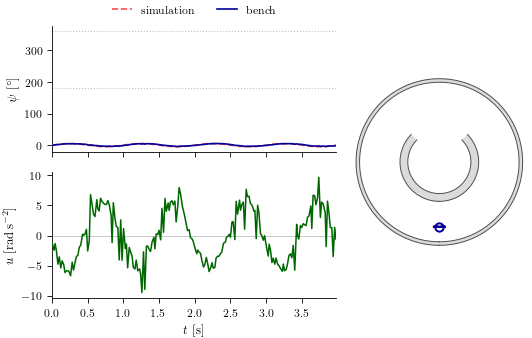

  -> figures\rapport\T2\tracking_tuned_A8deg.png


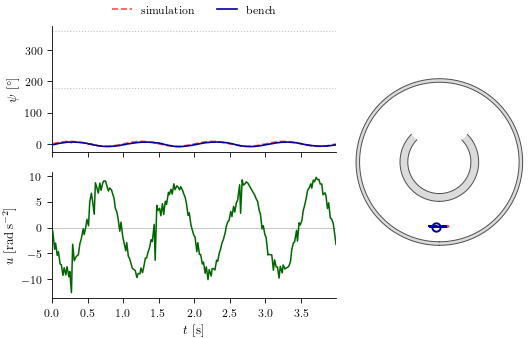

  -> figures\rapport\T2\inner_loop_effect_A5deg.png


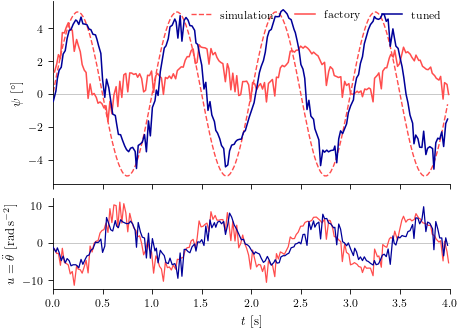

  A = 5 deg : factory 151022 gain 0.212, tuned 174422 gain 0.852


  -> figures\rapport\T2\inner_loop_effect_A8deg.png


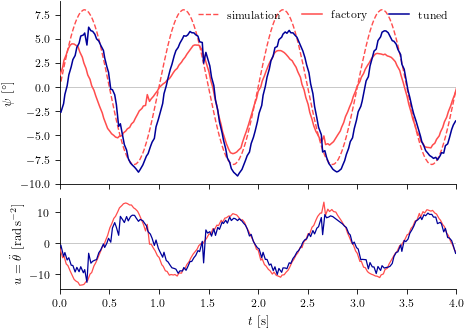

  A = 8 deg : factory 153340 gain 0.607, tuned 180309 gain 0.830


In [65]:
# =============================================================================

#  T2 - Figures du rapport, format a deux panneaux comme T1
# =============================================================================

T_WIN = 4.0

TUNED   = {5.0: "174422", 8.0: "180309"}
FACTORY = {5.0: "151022", 8.0: "153340"}

def _find(stamp):
    return next(e for e in t2_index
                if e['schema'] == 'v2' and e['label'].endswith(stamp))

def _traces(e):
    """Trajectoire mesuree, reference simulee et commande du cerceau."""
    d = np.load(e['file'], allow_pickle=True)
    t   = np.asarray(d['t'], float).squeeze()
    psi = np.degrees(np.asarray(d['psi'], float).squeeze())
    sim = np.degrees(np.asarray(d['psi_ref'], float).squeeze())
    u   = np.asarray(d['u'], float).squeeze()
    n = min(t.size, psi.size, sim.size, u.size)
    m = (t[:n] >= e['t_meas']) & (t[:n] <= e['t_meas'] + T_WIN)
    return t[:n][m] - e['t_meas'], psi[:n][m], sim[:n][m], u[:n][m]

# -----------------------------------------------------------------------
#  Figure 1 : poursuite en configuration reglee
#  Le panneau superieur compare la bille mesuree a la trajectoire simulee.
#  Le panneau inferieur montre l'acceleration imposee au cerceau.
# -----------------------------------------------------------------------
for A, stamp in TUNED.items():
    e = _find(stamp)
    t, psi, sim, u = _traces(e)
    curves = [
        dict(t=t, psi=np.radians(sim), col=C_RED, ls="--",
             label="simulation", r=91.6e-3),
        dict(t=t, psi=np.radians(psi), u=u, col=C_BLUE,
             label="bench", r=91.6e-3),
    ]
    plot_task_figure(curves, f"tracking_tuned_A{A:.0f}deg", subdir="T2",
                     t_max=T_WIN)

# -----------------------------------------------------------------------
#  Figure 2 : effet du reglage de la boucle de vitesse
#  Le panneau inferieur montre ou le probleme se situe reellement : le
#  cerceau ne suit pas, donc la bille ne peut pas suivre.
# -----------------------------------------------------------------------
for A in sorted(TUNED):
    et, ef = _find(TUNED[A]), _find(FACTORY[A])
    t_t, psi_t, sim_t, u_t = _traces(et)
    t_f, psi_f, sim_f, u_f = _traces(ef)

    fig, axes = new_fig(13.0, 9.5, nrows=2, sharex=True,
                        gridspec_kw=dict(height_ratios=[2, 1]))

    ax = axes[0]
    ax.axhline(0, color=C_GREYL, lw=0.6, zorder=1)
    ax.plot(t_t, sim_t, color=C_RED, lw=1.0, ls="--", zorder=2,
            label="simulation")
    ax.plot(t_f, psi_f, color=C_RED,  lw=1.1, zorder=3, label="factory")
    ax.plot(t_t, psi_t, color=C_BLUE, lw=1.1, zorder=4, label="tuned")
    ax.set_ylabel(r"$\psi$ [\si{\degree}]")
    ax.legend(loc="upper right", ncol=3)

    ax = axes[1]
    ax.axhline(0, color=C_GREYL, lw=0.6, zorder=1)
    ax.plot(t_f, u_f, color=C_RED,  lw=0.9, zorder=3)
    ax.plot(t_t, u_t, color=C_BLUE, lw=0.9, zorder=4)
    ax.set_ylabel(r"$u = \ddot{\theta}$ [\si{\radian\per\second\squared}]")
    ax.set_xlabel(r"$t$ [\si{\second}]")
    ax.set_xlim(0, T_WIN)

    fig.subplots_adjust(hspace=0.10)
    save(fig, "T2", f"inner_loop_effect_A{A:.0f}deg")
    plt.show()
    print(f"  A = {A:.0f} deg : factory {ef['label'][-6:]} "
          f"gain {ef['gain_meas']:.3f}, tuned {et['label'][-6:]} "
          f"gain {et['gain_meas']:.3f}")


### 4.3 T3 — loop the loop

  -> figures\rapport\T3\trajectory_generation.png


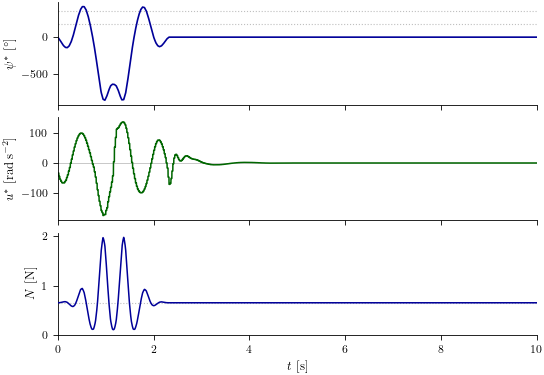

  t_f = 10.00 s, |u|max = 173.2 rad/s^2, N min = 0.1157 N (0.176 m_b g)


  -> figures\rapport\T3\T3_simulation.png


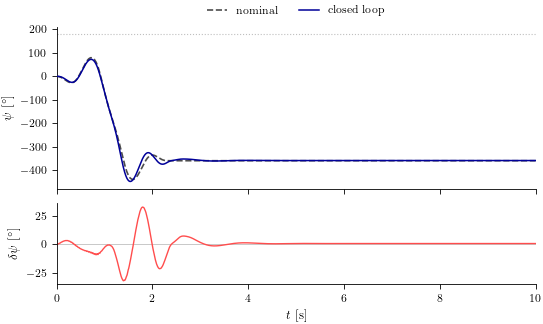

  ecart max en boucle fermee : 32.65 deg
  2/2 essai(s) retenu(s)


  -> figures\rapport\T3\T3_bench.png


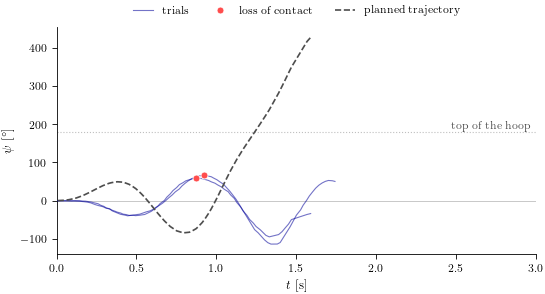

  decrochage a 62.3 +/- 5.1 deg (min 58.7, max 65.8)


In [66]:
# =============================================================================
#  T3 - Figures du rapport
#  Un seul .mat porte la trajectoire nominale, la boucle fermee simulee et
#  la commande. Les essais de banc viennent des .npz.
# =============================================================================

PSI_SIGN   = +1        # a verifier sur la premiere figure
DEPART_TOL = 5.0       # ecart au plan marquant le decrochage [deg]

# Geometrie et masse, piste exterieure (voir sec: parameters)
M_B, G, R_EFF = 67.0e-3, 9.81, 91.6e-3

def load_t3_sim(name):
    """Lit la trajectoire nominale, la boucle fermee et la commande."""
    with h5py.File(sim_run(name), "r") as f:
        r = f["run"]
        t   = np.asarray(r["t_s"], float).squeeze()
        x   = np.asarray(r["x"], float)
        u   = np.asarray(r["u_rad_s2"], float).squeeze()
        ref = np.asarray(r["ref_psi_rad"], float).squeeze()
        refd = np.asarray(r["ref_psi_dot_rad_s"], float).squeeze()
        tau = np.asarray(r["tau_Nm"], float).squeeze()
    if x.shape[1] == t.size:
        x = x.T
    n = min(t.size, x.shape[0], u.size, ref.size, refd.size, tau.size)
    return dict(t=t[:n] - t[0], theta=x[:n, 2], theta_d=x[:n, 3],
                psi=x[:n, 4], psi_d=x[:n, 5],
                u=u[:n], tau=tau[:n], ref=ref[:n], ref_d=refd[:n])

T3_SIM = "tvlqr_t3_loop_the_loop_direct_collocation_tvlqr"
sim   = load_t3_sim(T3_SIM)
N_ref = M_B * (G * np.cos(sim['ref']) + R_EFF * sim['ref_d'] ** 2)

# -----------------------------------------------------------------------
#  Figure 1 : trajectoire nominale et respect des contraintes
# -----------------------------------------------------------------------
fig, axes = new_fig(15.7, 11.0, nrows=3, sharex=True)

ax = axes[0]
ax.axhline(180, color=C_GREYL, lw=0.8, ls=":", zorder=1)
ax.axhline(360, color=C_GREYL, lw=0.8, ls=":", zorder=1)
ax.plot(sim['t'], PSI_SIGN * np.degrees(sim['ref_d']), color=C_BLUE, lw=1.2)
ax.set_ylabel(r"$\psi^*$ [\si{\degree}]")

ax = axes[1]
ax.axhline(0, color=C_GREYL, lw=0.6, zorder=1)
ax.plot(sim['t'], sim['u'], color=C_GREEN, lw=1.1)
ax.set_ylabel(r"$u^*$ [\si{\radian\per\second\squared}]")

ax = axes[2]
ax.axhline(0, color=C_GREYL, lw=0.6, zorder=1)
ax.axhline(M_B * G, color=C_GREYL, lw=0.8, ls=":", zorder=1)
ax.plot(sim['t'], N_ref, color=C_BLUE, lw=1.1, zorder=3)
ax.set_ylabel(r"$N$ [\si{\newton}]")
ax.set_xlabel(r"$t$ [\si{\second}]")
ax.set_xlim(0, sim['t'][-1])
ax.set_ylim(0, None)

fig.subplots_adjust(hspace=0.12)
save(fig, "T3", "trajectory_generation")
plt.show()

print(f"  t_f = {sim['t'][-1]:.2f} s, |u|max = {np.abs(sim['u']).max():.1f} "
      f"rad/s^2, N min = {N_ref.min():.4f} N "
      f"({N_ref.min()/(M_B*G):.3f} m_b g)")

# -----------------------------------------------------------------------
#  Figure 2 : boucle fermee simulee contre trajectoire nominale
# -----------------------------------------------------------------------
fig, axes = new_fig(15.7, 8.5, nrows=2, sharex=True,
                    gridspec_kw=dict(height_ratios=[2, 1]))

ax = axes[0]
ax.axhline(180, color=C_GREYL, lw=0.8, ls=":", zorder=1)
ax.plot(sim['t'], PSI_SIGN * np.degrees(sim['ref']), color=C_GREY, lw=1.2,
        ls="--", zorder=3, label="nominal")
ax.plot(sim['t'], PSI_SIGN * np.degrees(sim['psi']), color=C_BLUE, lw=1.1,
        zorder=4, label="closed loop")
ax.set_ylabel(r"$\psi$ [\si{\degree}]")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=2,
          frameon=False)

ax = axes[1]
ax.axhline(0, color=C_GREYL, lw=0.6, zorder=1)
ax.plot(sim['t'], np.degrees(sim['psi'] - sim['ref']), color=C_RED, lw=1.0)
ax.set_ylabel(r"$\delta\psi$ [\si{\degree}]")
ax.set_xlabel(r"$t$ [\si{\second}]")
ax.set_xlim(0, sim['t'][-1])

fig.subplots_adjust(hspace=0.12)
save(fig, "T3", "T3_simulation")
plt.show()

print(f"  ecart max en boucle fermee : "
      f"{np.degrees(np.abs(sim['psi'] - sim['ref']).max()):.2f} deg")

# -----------------------------------------------------------------------
#  Figure 3 : essais mesures, plan et point de decrochage
#
#  Seule la campagne du soir est retenue : les essais anterieurs ont servi
#  a la mise au point et ne suivent pas la meme consigne.
# -----------------------------------------------------------------------
T3_AFTER = "1800"       # horodatage minimal, HHMM

runs = [e for e in sorted(t3_index, key=lambda e: e['label'])
        if e['label'][-6:-2] >= T3_AFTER]
print(f"  {len(runs)}/{len(t3_index)} essai(s) retenu(s)")

fig, ax = new_fig(15.7, 7.5)
ax.axhline(0, color=C_GREYL, lw=0.6, zorder=1)
ax.axhline(180, color=C_GREYL, lw=0.8, ls=":", zorder=1)
ax.annotate("top of the hoop", xy=(0.99, 180),
            xycoords=("axes fraction", "data"),
            ha="right", va="bottom", fontsize=8, color=C_GREY)

dep = []
for j, run in enumerate(runs):
    d = np.load(run['file'], allow_pickle=True)
    t   = np.asarray(d['t'], float).squeeze()
    psi = np.degrees(np.asarray(d['psi'], float).squeeze())
    ref = np.degrees(np.asarray(d['psi_ref'], float).squeeze())
    n = min(t.size, psi.size, ref.size)
    t, psi, ref = t[:n], psi[:n], ref[:n]

    s = np.sign(np.mean(ref)) or 1.0      # sens de la manoeuvre planifiee

    ax.plot(t, s * psi, color=C_BLUE, lw=0.8, alpha=0.55, zorder=3,
            label="trials" if j == 0 else None)

    i = int(np.argmax(s * psi))           # sommet atteint avant la retombee
    dep.append(s * psi[i])
    ax.plot(t[i], s * psi[i], "o", ms=5, color=C_RED, mec="white", mew=0.6,
            zorder=5, label="loss of contact" if j == 0 else None)

    if j == 0:
        ax.plot(t, s * ref, color=C_GREY, lw=1.2, ls="--", zorder=4,
                label="planned trajectory")

ax.set_xlabel(r"$t$ [\si{\second}]")
ax.set_ylabel(r"$\psi$ [\si{\degree}]")
ax.set_xlim(0, 3.0)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=3,
          frameon=False)

save(fig, "T3", "T3_bench")
plt.show()

if dep:
    a = np.array(dep)
    print(f"  decrochage a {a.mean():.1f} +/- "
          f"{a.std(ddof=1) if len(a) > 1 else 0:.1f} deg "
          f"(min {a.min():.1f}, max {a.max():.1f})")


  -> figures\rapport\T3\theta_nominal_vs_tvlqr.png


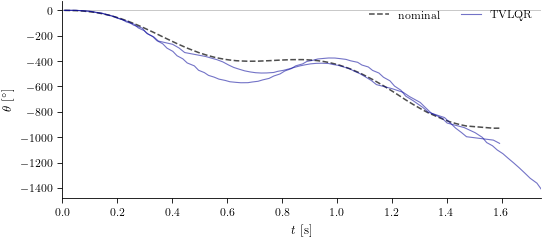

  theta : nominal vs TVLQR, 2 essai(s)


In [67]:
# -----------------------------------------------------------------------
#  Figure : theta nominal contre theta TVLQR
# -----------------------------------------------------------------------
T3_THETA_AFTER = "1800"
t3_theta_runs = [
    entry for entry in sorted(t3_index, key=lambda entry: entry['label'])
    if entry['label'][-6:-2] >= T3_THETA_AFTER
]

fig, ax = new_fig(15.7, 6.5)
ax.axhline(0, color=C_GREYL, lw=0.6, zorder=1)

nominal_plotted = False
n_tvlqr = 0
t_max = 0.0
for entry in t3_theta_runs:
    data = np.load(entry['file'], allow_pickle=True)
    if 'theta_ref' not in data.files or 'theta' not in data.files:
        continue

    t = np.asarray(data['t'], float).squeeze()
    theta_ref = np.asarray(data['theta_ref'], float).squeeze()
    theta_tvlqr = np.asarray(data['theta'], float).squeeze()
    n = min(t.size, theta_ref.size, theta_tvlqr.size)
    if n < 2:
        continue
    t_max = max(t_max, t[n - 1])

    if not nominal_plotted:
        ax.plot(t[:n], np.degrees(theta_ref[:n]), color=C_GREY, lw=1.1,
                ls='--', zorder=2, label='nominal')
        nominal_plotted = True

    ax.plot(t[:n], np.degrees(theta_tvlqr[:n]), color=C_BLUE, lw=0.8,
            alpha=0.55, zorder=3,
            label='TVLQR' if n_tvlqr == 0 else None)
    n_tvlqr += 1

if not nominal_plotted:
    raise RuntimeError("theta_ref absent des fichiers T3 retenus")

ax.set_xlabel(r"$t$ [\si{\second}]")
ax.set_ylabel(r"$\theta$ [\si{\degree}]")
ax.set_xlim(0, t_max)
ax.legend(loc='upper right', ncol=2)

save(fig, "T3", "theta_nominal_vs_tvlqr")
plt.show()
print(f"  theta : nominal vs TVLQR, {n_tvlqr} essai(s)")


  -> figures\rapport\T3\path_nominal.png


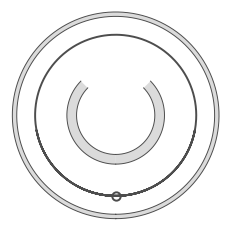

  nominal      psi max =  439.4 deg


  -> figures\rapport\T3\path_closed_loop.png


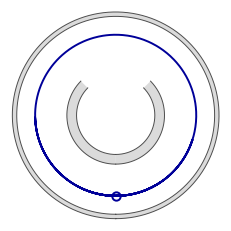

  closed_loop  psi max =  448.4 deg


  -> figures\rapport\T3\path_bench.png


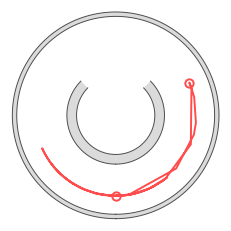

  bench        psi max =  114.0 deg


In [68]:
# =============================================================================
#  T3 - Trajectoire de la bille dans les cerceaux
#  Transposition en Python du trace MATLAB : cerceaux remplis, ouverture du
#  cerceau interieur, marqueur de depart et points de transition.
# =============================================================================

# --- Geometrie, en metres -------------------------------------------------

MARGIN = 0.05              # marge d'affichage [m]

    

def plot_path(psi, col, theta0=0.0, r=None, events=None, name=None):
    """Trajectoire de la bille superposee a la geometrie des cerceaux."""
    r = np.full_like(psi, R_EFF) if r is None else r
    x, y = _map2plot(r * np.cos(psi), r * np.sin(psi))
    x, y = x * 1e3, y * 1e3

    fig, ax = new_fig(7.5, 7.5)
    _draw_hoops(ax, theta0)

    ax.plot(x, y, color=col, lw=1.4, zorder=4)
    ax.plot(x[0], y[0], "o", ms=6, mfc="none", mec=col, mew=1.4, zorder=5)

    if events is not None and len(events):
        xe, ye = _map2plot(events[:, 0] * np.cos(events[:, 1]),
                           events[:, 0] * np.sin(events[:, 1]))
        ax.plot(xe * 1e3, ye * 1e3, "o", ms=6, mfc="none",
                mec=C_RED, mew=1.4, zorder=6)

    if name:
        save(fig, "T3", f"path_{name}")
    plt.show()
    return fig

# -----------------------------------------------------------------------
#  Les trois vues
# -----------------------------------------------------------------------
best = max(runs, key=lambda r: np.abs(
    np.asarray(np.load(r['file'], allow_pickle=True)['psi'], float)).max())
d     = np.load(best['file'], allow_pickle=True)
psi_b = np.asarray(d['psi'], float).squeeze()
ref_b = np.asarray(d['psi_ref'], float).squeeze()
psi_b = psi_b * (np.sign(np.mean(ref_b)) or 1.0) \
              * (np.sign(np.mean(sim['ref'])) or 1.0)

# Sommet atteint sur le banc, marque comme point de decrochage
i_dep = int(np.argmax(np.abs(psi_b)))
ev_b  = np.array([[R_EFF, psi_b[i_dep]]])

for name, psi, col, ev in (("nominal",     sim['ref'], C_GREY, None),
                           ("closed_loop", sim['psi'], C_BLUE, None),
                           ("bench",       psi_b,      C_RED,  ev_b)):
    plot_path(psi, col, theta0=0.0, events=ev, name=name)
    print(f"  {name:<12} psi max = {np.degrees(np.abs(psi).max()):6.1f} deg")


In [69]:
# =============================================================================
#  T3 - Par essai : la manoeuvre, et l'adherence qu'elle a demandee
#
#  Pour chaque essai retenu, deux figures. La premiere reprend la mise en
#  page a trois panneaux du rapport : angle, commande, chemin parcouru. La
#  seconde reconstruit le coefficient de frottement que le mouvement REALISE
#  a exige, a comparer a celui du plan nominal.
#
#  Deux precautions.
#
#  La serie est coupee au decrochage : au-dela, la bille quitte le plan de
#  la piste et le detecteur suit un objet dont la position rapportee ne
#  decrit plus la manoeuvre.
#
#  psi vient de la camera, et mu_req en demande la derivee seconde. Une
#  difference finie brute amplifierait le bruit de pixel au point de rendre
#  la figure illisible : la derivation passe donc par un filtre de
#  Savitzky-Golay, qui ajuste un polynome local et derive l'ajustement.
# =============================================================================

MU_S       = 0.5      # params.ball_track_friction_coeff
PSI_DEP    = 98.0     # angle de decrochage releve sur les essais [deg]
T_ADH_CROP = 3.11     # fin utile des manoeuvres de looping [s]
SG_WIN_S   = 0.20     # fenetre du filtre derivateur [s]
SG_ORDER   = 3        # ordre du polynome local

def _trial_series(run):
    """Serie mesuree, ramenee au sens de la manoeuvre et coupee au decrochage."""
    d   = np.load(run['file'], allow_pickle=True)
    t   = np.asarray(d['t'], float).squeeze()
    psi = np.asarray(d['psi'], float).squeeze()
    u   = np.asarray(d['u'], float).squeeze()
    ref = np.asarray(d['psi_ref'], float).squeeze()
    n   = min(t.size, psi.size, u.size, ref.size)
    t, psi, u, ref = t[:n] - t[0], psi[:n], u[:n], ref[:n]

    s = np.sign(np.mean(ref)) or 1.0       # sens de la manoeuvre planifiee
    psi = s * psi

    cross = np.flatnonzero(np.degrees(psi) >= PSI_DEP)
    i_dep = int(cross[0]) if cross.size else int(np.argmax(psi))
    sl = slice(0, i_dep + 1)
    return t[sl], psi[sl], u[sl], s

def _adherence(t, psi):
    """mu_req et N reconstruits depuis une trajectoire mesuree.

    F_t vient du bilan des forces sur la bille entiere, projete sur la
    tangente : m R psi_ddot = F_t - m g sin(psi). Cette relation ne depend
    pas de la contrainte de roulement substituee dans le lagrangien, donc
    elle reste valable la ou le modele reduit ne voit plus rien.
    """
    dt  = float(np.median(np.diff(t)))
    win = int(round(SG_WIN_S / dt)) | 1                 # impair
    win = max(SG_ORDER + 2 - (SG_ORDER % 2), min(win, len(t) - 1 | 1))

    psi_d  = savgol_filter(psi, win, SG_ORDER, deriv=1, delta=dt)
    psi_dd = savgol_filter(psi, win, SG_ORDER, deriv=2, delta=dt)

    F_t = M_B * (R_EFF * psi_dd + G * np.sin(psi))
    N   = M_B * (G * np.cos(psi) + R_EFF * psi_d ** 2)
    return np.abs(F_t) / np.maximum(N, 1e-9), N, F_t, win


  -> figures\rapport\T3\backup_speed_at_departure.png


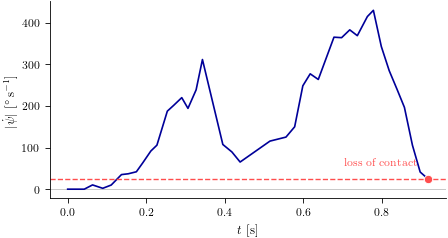

  |psidot| au decrochage : 25 deg/s, max avant : 429 deg/s


  -> figures\rapport\T3\trajectory_generation.png


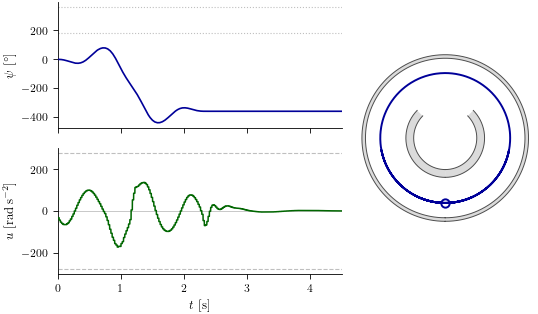

  t_f = 10.00 s, |u|max = 173.2 rad/s^2, N min = 0.176 m_b g


  -> figures\rapport\T3\T3_simulation.png


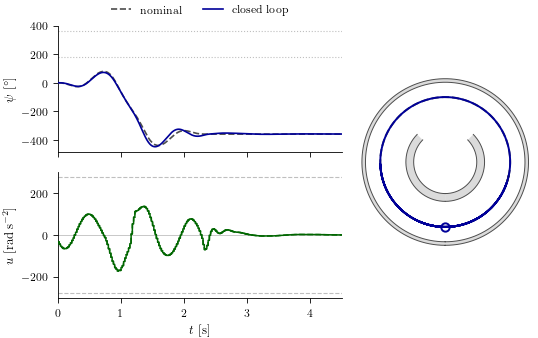

  ecart max : 32.65 deg


  -> figures\rapport\T3\T3_bench.png


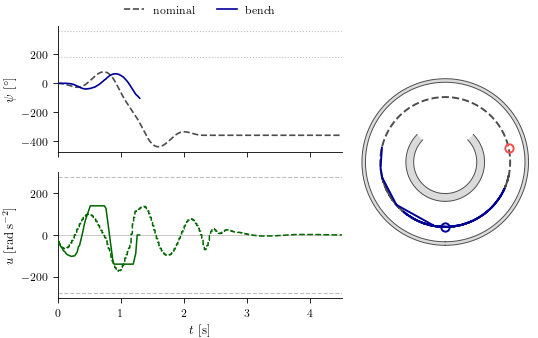

  decrochage a 102.9 deg, t = 1.30 s


In [70]:
# =============================================================================
#  T3 - Figures a trois panneaux
#  Colonne de gauche : angle de la bille et commande. Colonne de droite :
#  chemin parcouru dans le plan des cerceaux, dessine sur la meme geometrie
#  que les scenarios en boucle ouverte (voir sec: open loop results).
#
#  La meme fonction produit la trajectoire nominale, la boucle fermee simulee
#  et les essais de banc : seules changent les series passees en argument.
# =============================================================================

# Borne de commande tracee sur le panneau u : couple disponible
# rapporte a l'inertie totale (cfg.tau_max / params.total_inertia).
U_MAX = 276.96      # [rad/s^2]  !VERIF contre la config du scenario
T_CROP = 4.5     # instant de coupure commun aux trois figures [s]

 # Backup piste 2 : la vitesse au decrochage n'a rien d'exceptionnel.
t_b, psi_b, u_b, s = _trial_series(best)
psid = np.gradient(np.degrees(psi_b), t_b)

fig, ax = new_fig(13.0, 6.5)
ax.axhline(0, color=C_GREYL, lw=0.6)
ax.plot(t_b, np.abs(psid), color=C_BLUE, lw=1.2)
ax.axhline(np.abs(psid[-1]), color=C_RED, lw=1.0, ls="--")
ax.plot(t_b[-1], abs(psid[-1]), "o", ms=6, color=C_RED, mec="white", mew=0.6)
ax.annotate("loss of contact", xy=(t_b[-1], abs(psid[-1])),
            xytext=(-8, 10), textcoords="offset points",
            ha="right", fontsize=8, color=C_RED)
ax.set_xlabel(r"$t$ [\si{\second}]")
ax.set_ylabel(r"$|\dot\psi|$ [\si{\degree\per\second}]")
save(fig, "T3", "backup_speed_at_departure")
plt.show()
print(f"  |psidot| au decrochage : {abs(psid[-1]):.0f} deg/s, "
f"max avant : {np.abs(psid[:-1]).max():.0f} deg/s")

# -----------------------------------------------------------------------
#  Figure 6.3 : trajectoire nominale et respect des contraintes
# -----------------------------------------------------------------------
nom = dict(t=sim['t'], psi=PSI_SIGN * sim['ref'], u=sim['u'],
           col=C_BLUE, ls="-", label=None)
plot_task_figure([nom], "trajectory_generation",
               u_max=U_MAX, t_max=T_CROP)
print(f"  t_f = {sim['t'][-1]:.2f} s, |u|max = {np.abs(sim['u']).max():.1f} "
      f"rad/s^2, N min = {N_ref.min()/(M_B*G):.3f} m_b g")

# -----------------------------------------------------------------------
#  Figure 6.4 : boucle fermee simulee contre trajectoire nominale
# -----------------------------------------------------------------------
plot_task_figure(
    [dict(t=sim['t'], psi=PSI_SIGN * sim['ref'], u=sim['u'],
          col=C_GREY, ls="--", label="nominal"),
     dict(t=sim['t'], psi=PSI_SIGN * sim['psi'], u=sim.get('u_cl', sim['u']),
          col=C_BLUE, ls="-", label="closed loop")],
    "T3_simulation", u_max=U_MAX,  t_max=T_CROP)
print(f"  ecart max : {np.degrees(np.abs(sim['psi'] - sim['ref']).max()):.2f} deg")

# -----------------------------------------------------------------------
#  Figure 6.5 : essai de banc contre trajectoire nominale
#
#  La bille quitte la piste avant le sommet et est ejectee. Passe cet
#  instant, le detecteur suit un objet qui n'est plus contraint par la
#  geometrie, et les positions rapportees ne decrivent plus la manoeuvre :
#  la serie est donc coupee au decrochage.
# -----------------------------------------------------------------------
PSI_DEP = 98.0     # angle de decrochage, releve sur les essais [deg]

d_b   = np.load(best['file'], allow_pickle=True)
t_b   = np.asarray(d_b['t'], float).squeeze()
psi_b = np.asarray(d_b['psi'], float).squeeze()
u_b   = np.asarray(d_b['u'], float).squeeze()
n     = min(t_b.size, psi_b.size, u_b.size)
t_b, psi_b, u_b = t_b[:n] - t_b[0], psi_b[:n] * PSI_SIGN, u_b[:n]

# Premier passage au-dela du decrochage : tout ce qui suit est ecarte
psi_deg = np.degrees(psi_b)
cross   = np.flatnonzero(np.abs(psi_deg) >= PSI_DEP)
i_dep   = int(cross[0]) if cross.size else len(psi_b) - 1

t_b, psi_b, u_b = t_b[:i_dep + 1], psi_b[:i_dep + 1], u_b[:i_dep + 1]

plot_task_figure(
    [dict(t=sim['t'], psi=PSI_SIGN * sim['ref'], u=sim['u'],
          col=C_GREY, ls="--", label="nominal"),
     dict(t=t_b, psi=-1*psi_b, u=u_b, col=C_BLUE, ls="-", label="bench",
          events=np.array([[R_EFF, psi_b[-1]]]))],
    "T3_bench", u_max=U_MAX, t_max=T_CROP)
print(f"  decrochage a {np.degrees(psi_b[-1]):.1f} deg, t = {t_b[-1]:.2f} s")


  -> figures\rapport\T3\mu_req_and_normal_force.png


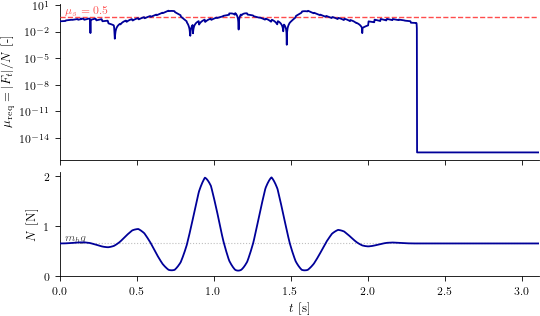

  fenetre tracee   : 0 a 3.11 s
  mu_req max       : 2.29  a t = 0.71 s, psi = +79 deg
    N a ce point  : 0.1343 N  (0.204 m_b g)
    |F_t| ici     : 0.3080 N
  |F_t| max       : 0.5337 N  a t = 0.98 s, ou mu_req ne vaut que 0.29
  N min           : 0.1157 N
  echantillons au-dessus de mu_s : 560 / 2644 (21 %)


In [71]:
# =============================================================================
#  T3 - Adherence requise le long de la trajectoire nominale
#  Deux panneaux : le coefficient de frottement que la trajectoire demande,
#  et la force normale qui en est le denominateur. Les pics du premier
#  tombent dans les creux du second, ce qui est tout le diagnostic.
#
#  F_t vient du bilan des forces sur la bille prise dans son ensemble,
#  pas du modele de roulement : c'est la seconde loi de Newton projetee sur
#  la tangente, donc valable independamment de la contrainte substituee
#  analytiquement dans le lagrangien.
# =============================================================================

MU_S = 0.5     # params.ball_track_friction_coeff, valeur de la litterature

# La fin des manoeuvres de looping est exclue de la figure.
T_ADH_CROP = 3.11
m_adh = sim['t'] <= T_ADH_CROP
t_adh = sim['t'][m_adh]
ref_adh = sim['ref'][m_adh]
ref_d_adh = sim['ref_d'][m_adh]

# psi_ddot par derivation de la vitesse nominale, lisse a la tolerance du solveur
psi_dd = np.gradient(ref_d_adh, t_adh)

# Tangentielle : m R psi_ddot = F_t - m g sin(psi)
F_t = M_B * (R_EFF * psi_dd + G * np.sin(ref_adh))

# N_ref est deja calcule plus haut ; recopie ici pour que la cellule soit lisible
N_req  = M_B * (G * np.cos(ref_adh) + R_EFF * ref_d_adh ** 2)
mu_req = np.abs(F_t) / np.maximum(N_req, 1e-9)

fig, axes = new_fig(15.7, 9.0, nrows=2, sharex=True,
                    gridspec_kw=dict(height_ratios=[3, 2]))

# --- mu requis ---------------------------------------------------------
ax = axes[0]
viol = mu_req > MU_S
ax.plot(t_adh, mu_req, color=C_BLUE, lw=1.3, zorder=4)
ax.axhline(MU_S, color=C_RED, lw=1.0, ls="--", zorder=3)
ax.annotate(rf"$\mu_s = {MU_S:.1f}$",
            xy=(0.012, MU_S), xycoords=("axes fraction", "data"),
            ha="left", va="bottom", fontsize=8, color=C_RED)
ax.set_yscale("log")
ax.set_ylabel(r"$\mu_{\mathrm{req}} = |F_t| / N$  [-]")

# Le maximum est recherche uniquement dans la manoeuvre conservee.
i_mu = int(np.argmax(mu_req))

# --- force normale -----------------------------------------------------
ax = axes[1]
ax.axhline(0, color=C_GREYL, lw=0.6, zorder=1)
ax.axhline(M_B * G, color=C_GREYL, lw=0.8, ls=":", zorder=1)
ax.annotate(r"$m_b g$", xy=(0.012, M_B * G),
            xycoords=("axes fraction", "data"),
            ha="left", va="bottom", fontsize=8, color=C_GREY)
ax.plot(t_adh, N_req, color=C_BLUE, lw=1.3, zorder=4)
ax.set_ylabel(r"$N$ [\si{\newton}]")
ax.set_xlabel(r"$t$ [\si{\second}]")
ax.set_xlim(0, T_ADH_CROP)
ax.set_ylim(0, None)

fig.subplots_adjust(hspace=0.10)
save(fig, "T3", "mu_req_and_normal_force")
plt.show()

# --- ce que la figure porte -------------------------------------------
i_ft = int(np.argmax(np.abs(F_t)))
print(f"  fenetre tracee   : 0 a {t_adh[-1]:.2f} s")
print(f"  mu_req max       : {mu_req[i_mu]:.2f}  a t = {t_adh[i_mu]:.2f} s, "
      f"psi = {np.degrees(ref_adh[i_mu]):+.0f} deg")
print(f"    N a ce point  : {N_req[i_mu]:.4f} N  "
      f"({N_req[i_mu] / (M_B * G):.3f} m_b g)")
print(f"    |F_t| ici     : {abs(F_t[i_mu]):.4f} N")
print(f"  |F_t| max       : {abs(F_t[i_ft]):.4f} N  a t = {t_adh[i_ft]:.2f} s, "
      f"ou mu_req ne vaut que {mu_req[i_ft]:.2f}")
print(f"  N min           : {N_req.min():.4f} N")
print(f"  echantillons au-dessus de mu_s : {viol.sum()} / {viol.size} "
      f"({100 * viol.mean():.0f} %)")


Essais T3 : 2 retenu(s), fenetre du filtre 200 ms, ordre 3



  -> figures\rapport\T3\trial_183303_manoeuvre.png


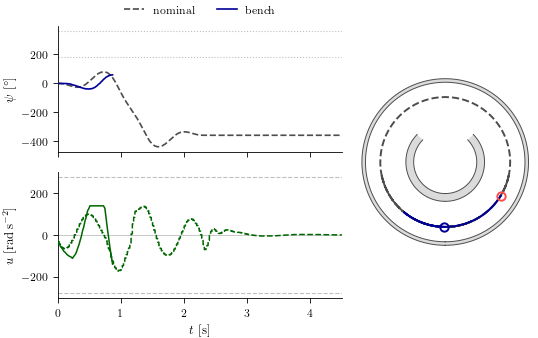

  -> figures\rapport\T3\trial_183303_adherence.png


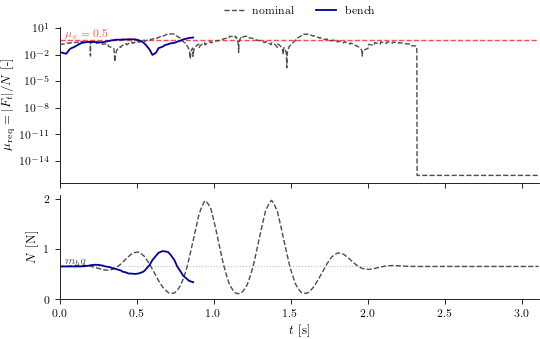

  183303 : decrochage a +58.7 deg, t = 0.87 s
           mu_req max 0.85 a t = 0.87 s, N = 0.3433 N
           N min 0.3433 N (0.522 m_b g), 9/42 points au-dessus de mu_s
           mu >= 0.85  a t = 0.87 s, N = 0.52 m_b g


  -> figures\rapport\T3\trial_183457_manoeuvre.png


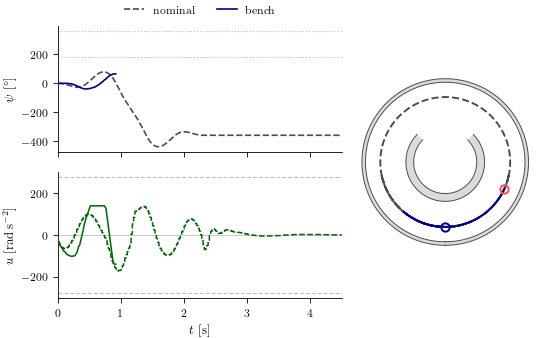

  -> figures\rapport\T3\trial_183457_adherence.png


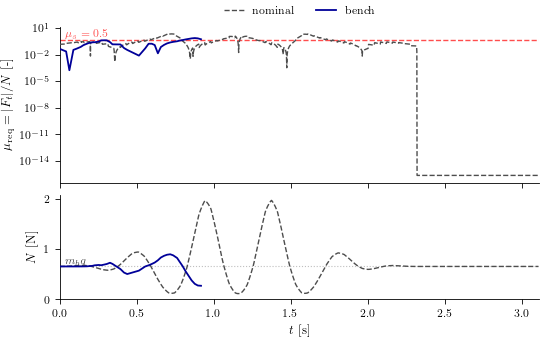

  183457 : decrochage a +65.8 deg, t = 0.92 s
           mu_req max 0.74 a t = 0.88 s, N = 0.3107 N
           N min 0.2723 N (0.414 m_b g), 6/40 points au-dessus de mu_s
           mu >= 0.74  a t = 0.88 s, N = 0.47 m_b g


In [72]:
# -----------------------------------------------------------------------
print(f"Essais T3 : {len(runs)} retenu(s), fenetre du filtre "
      f"{SG_WIN_S*1e3:.0f} ms, ordre {SG_ORDER}\n")

for run in runs:
    stamp = run['label'][-6:]
    t_b, psi_b, u_b, s = _trial_series(run)

    if t_b.size < 20:
        print(f"  {stamp} : serie trop courte apres coupure, ignoree")
        continue

    # La partie apres 3.11 s correspond a la fin de la manoeuvre,
    # et ne doit pas intervenir dans le calcul ni l'affichage de mu.
    keep = t_b <= T_ADH_CROP
    t_b, psi_b, u_b = t_b[keep], psi_b[keep], u_b[keep]

    # --- Figure 1 : manoeuvre, sur la mise en page du rapport ----------
    plot_task_figure(
        [dict(t=sim['t'], psi=PSI_SIGN * sim['ref'], u=sim['u'],
              col=C_GREY, ls="--", label="nominal"),
         dict(t=t_b, psi=psi_b, u=u_b, col=C_BLUE, ls="-", label="bench",
              events=np.array([[R_EFF, psi_b[-1]]]))],
        f"trial_{stamp}_manoeuvre", u_max=U_MAX, t_max=T_CROP)

    # --- Figure 2 : adherence exigee par le mouvement realise ----------
    mu_b, N_b, F_b, win = _adherence(t_b, psi_b)

    fig, axes = new_fig(15.7, 9.0, nrows=2, sharex=True,
                        gridspec_kw=dict(height_ratios=[3, 2]))

    ax = axes[0]
    ax.plot(t_adh, mu_req, color=C_GREY, lw=1.0, ls="--", zorder=3,
            label="nominal")
    ax.plot(t_b, mu_b, color=C_BLUE, lw=1.3, zorder=4, label="bench")
    ax.axhline(MU_S, color=C_RED, lw=1.0, ls="--", zorder=2)
    ax.annotate(rf"$\mu_s = {MU_S:.1f}$",
                xy=(0.012, MU_S), xycoords=("axes fraction", "data"),
                ha="left", va="bottom", fontsize=8, color=C_RED)
    ax.set_yscale("log")
    ax.set_ylabel(r"$\mu_{\mathrm{req}} = |F_t| / N$  [-]")
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=2,
              frameon=False)

    ax = axes[1]
    ax.axhline(0, color=C_GREYL, lw=0.6, zorder=1)
    ax.axhline(M_B * G, color=C_GREYL, lw=0.8, ls=":", zorder=1)
    ax.annotate(r"$m_b g$", xy=(0.012, M_B * G),
                xycoords=("axes fraction", "data"),
                ha="left", va="bottom", fontsize=8, color=C_GREY)
    ax.plot(t_adh, N_req, color=C_GREY, lw=1.0, ls="--", zorder=3)
    ax.plot(t_b, N_b, color=C_BLUE, lw=1.3, zorder=4)
    ax.set_ylabel(r"$N$ [\si{\newton}]")
    ax.set_xlabel(r"$t$ [\si{\second}]")
    ax.set_xlim(0, T_ADH_CROP)
    ax.set_ylim(0, None)

    fig.subplots_adjust(hspace=0.10)
    save(fig, "T3", f"trial_{stamp}_adherence")
    plt.show()

    i_mu = int(np.argmax(mu_b))
    print(f"  {stamp} : decrochage a {np.degrees(psi_b[-1]):+.1f} deg, "
          f"t = {t_b[-1]:.2f} s")
    print(f"           mu_req max {mu_b[i_mu]:.2f} a t = {t_b[i_mu]:.2f} s, "
          f"N = {N_b[i_mu]:.4f} N")
    print(f"           N min {N_b.min():.4f} N "
          f"({N_b.min()/(M_B*G):.3f} m_b g), "
          f"{int((mu_b > MU_S).sum())}/{mu_b.size} points au-dessus de mu_s")

    # Borne inferieure sur mu : le contact a effectivement fourni ce rapport
    # tant que la bille roulait, donc mu >= max(mu_req) sur cette portion.
    # Le maximum n'est cherche que la ou N reste franche : ailleurs le rapport
    # diverge par son denominateur et ne renseigne plus sur l'adherence.
    N_FLOOR = 0.30                       # fraction de m_b g

    ok = N_b >= N_FLOOR * M_B * G
    if ok.any():
        i = int(np.argmax(np.where(ok, mu_b, -np.inf)))
        print(f"           mu >= {mu_b[i]:.2f}  a t = {t_b[i]:.2f} s, "
            f"N = {N_b[i]/(M_B*G):.2f} m_b g")


  -> figures\rapport\T3\T3_coulomb_comparison.png


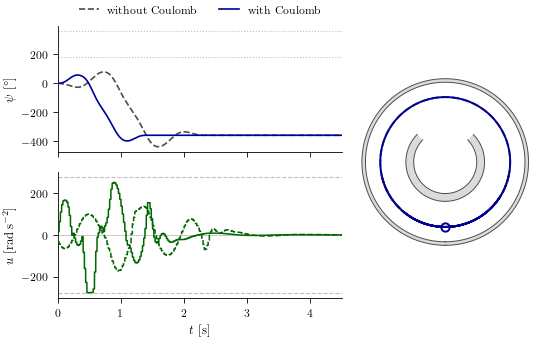

  without  Tf = 10.00 s, |u|max = 173 rad/s2, mu_req max = 1.51, N min = 0.176 m_b g
  with     Tf = 10.00 s, |u|max = 277 rad/s2, mu_req max = 0.65, N min = 0.191 m_b g


In [73]:
# =============================================================================
#  T3 - Effet de la contrainte de Coulomb sur le plan nominal
#  Deux resolutions du meme scenario, l'une sans la contrainte d'adherence,
#  l'autre avec. Seule cette contrainte change entre les deux.
# =============================================================================
T3_SIM_FREE = T3_SIM       # celui deja charge, sans Coulomb
T3_SIM_FREE = "tvlqr_t3_loop_the_loop_direct_collocation_tvlqr"
T3_SIM_MU   = "tvlqr_t3_loop_the_loop_coulomb_constrained_direct_collocation_tvlq"       # <-- le .mat du plan avec enforce_no_slip

free = sim
mu_p = load_t3_sim(T3_SIM_MU)

plot_task_figure(
    [dict(t=free['t'],  psi=PSI_SIGN * free['ref'],  u=free['u'],
          col=C_GREY, ls="--", label="without Coulomb"),
     dict(t=mu_p['t'],  psi=PSI_SIGN * mu_p['ref'],  u=mu_p['u'],
          col=C_BLUE, ls="-",  label="with Coulomb")],
    "T3_coulomb_comparison", u_max=U_MAX, t_max=T_CROP)

for name, p in (("without", free), ("with", mu_p)):
    N = M_B * (G * np.cos(p['ref']) + R_EFF * p['ref_d'] ** 2)
    pdd = np.gradient(p['ref_d'], p['t'])
    Ft = M_B * (R_EFF * pdd + G * np.sin(p['ref']))
    mu = np.abs(Ft) / np.maximum(N, 1e-9)
    ok = N >= 0.30 * M_B * G
    print(f"  {name:8s} Tf = {p['t'][-1]:.2f} s, "
          f"|u|max = {np.abs(p['u']).max():.0f} rad/s2, "
          f"mu_req max = {mu[ok].max():.2f}, "
          f"N min = {N.min()/(M_B*G):.3f} m_b g")


### 4.4 T4 — flying ball

  264/6449 echantillons en vol
  2766 echantillons conserves, jusqu'a 3.00 s
  2 transition(s) : 1.44 s, 1.63 s


  -> figures\rapport\T4\T4_simulation.png


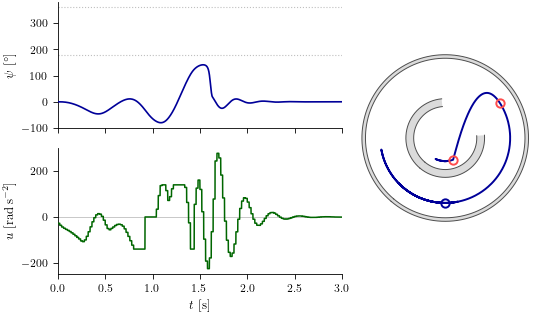

  liftoff a 122.1 deg, impact a 122.1 deg, t_f = 3.00 s


In [74]:
# =============================================================================
#  T4 - Manoeuvre de la balle volante, en simulation
#  Trois phases : lancement, vol libre pendant lequel le cerceau amene son
#  ouverture au point d'impact, puis capture. Le vol est la seule portion ou
#  r cesse d'etre constant, et le seul moment ou la bille echappe a la commande.
# =============================================================================

T4_SIM = "t4_t4_flying_ball_pump_release_fly_through_the_gap_catch_inside"     # nom du .mat produit par la simulation multi-phase

def load_t4_sim(name):
    """Trajectoire multi-phase.

    La simulation ne rapporte pas le mode actif, mais il se lit sur le rayon :
    en roulement la bille est tenue contre une piste et r est fige a l'un des
    rayons effectifs, alors qu'en vol libre il varie continument. Le mode
    reconstruit vaut 0 en roulement et 1 en vol.
    """
    with h5py.File(sim_run(name), "r") as f:
        run = f["run"]
        t = np.asarray(run["t_s"], float).squeeze()
        x = np.asarray(run["x"], float)
        u = np.asarray(run["u_rad_s2"], float).squeeze()
    if x.shape[1] == t.size:
        x = x.T
    n = min(t.size, x.shape[0], u.size)
    t, x, u = t[:n] - t[0], x[:n], u[:n]

    r = x[:, 0]
    # Seuil sur la variation de r, rapporte au pas de temps : en roulement
    # elle est nulle a la tolerance du solveur pres.
    dr = np.abs(np.r_[0.0, np.diff(r)])
    flying = dr > 1e-6
    # Un echantillon isole de part et d'autre ne fait pas une phase : on
    # comble les trous en prenant l'enveloppe du vol.
    idx = np.flatnonzero(flying)
    mode = np.zeros(n)
    if idx.size:
        mode[idx[0]:idx[-1] + 1] = 1.0

    return dict(t=t, r=r, theta=x[:, 2], psi=x[:, 4], u=u, mode=mode)

t4 = load_t4_sim(T4_SIM)
print(f"  {int(t4['mode'].sum())}/{t4['mode'].size} echantillons en vol")

T4_CROP = 3     # instant de coupure [s]

m = t4['t'] <= T4_CROP
t4 = {k: v[m] for k, v in t4.items()}
print(f"  {t4['t'].size} echantillons conserves, jusqu'a {t4['t'][-1]:.2f} s")

# Instants de transition, communs aux deux vues
i_tr = np.flatnonzero(np.diff(t4['mode'])) + 1
print(f"  {i_tr.size} transition(s) : "
      f"{', '.join(f'{t4[chr(116)][i]:.2f} s' for i in i_tr)}")

# Le chemin est trace avec les cerceaux a leur orientation au moment de
# l'impact, de sorte que l'ouverture apparaisse la ou la bille la traverse.
i_imp = int(i_tr[-2])

curves = [dict(t=t4["t"], psi=t4["psi"], u=t4["u"], col=C_BLUE, r=t4["r"],
               events=np.column_stack([t4["r"][i_tr], t4["psi"][i_tr]]))]

plot_task_figure(curves, "T4_simulation", subdir="T4",
                 theta0=t4["theta"][i_imp], t_max=T4_CROP)
print(f"  liftoff a {np.degrees(t4['psi'][i_tr[0]]):.1f} deg, "
      f"impact a {np.degrees(t4['psi'][i_imp]):.1f} deg, "
      f"t_f = {t4['t'][-1]:.2f} s")


  -> figures\rapport\T4\theta_nominal_vs_tvlqr.png


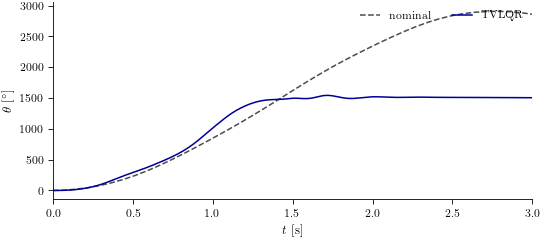

In [75]:
# -----------------------------------------------------------------------
#  Figure : theta nominal contre theta TVLQR
# -----------------------------------------------------------------------

T4_PLAN_FILE = Path("../python/tasks/plans/T4d_flying_ball_plan.mat")
plan_t4 = loadmat(T4_PLAN_FILE, squeeze_me=True)
t_plan = np.asarray(plan_t4["t"], float).squeeze()
theta_nominal = np.asarray(plan_t4["x_ref"], float)[:, 0]

fig, ax = new_fig(15.7, 6.5)
ax.plot(t_plan, np.degrees(theta_nominal), color=C_GREY, lw=1.1,
        ls="--", label="nominal")
ax.plot(t4["t"], np.degrees(-t4["theta"]), color=C_BLUE, lw=1.1,
        label="TVLQR")

ax.set_xlabel(r"$t$ [\si{\second}]")
ax.set_ylabel(r"$\theta$ [\si{\degree}]")
ax.set_xlim(0, T4_CROP)
ax.legend(loc="upper right", ncol=2)

save(fig, "T4", "theta_nominal_vs_tvlqr")
plt.show()
